# Data exploration and cleaning

In [ ]:
import pandas as pd
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np
import re
from glob import glob

In [ ]:
# Load the data
filenames = glob.glob("../data/raw/*.csv")
dfs = [pd.read_csv(filename) for filename in filenames]

df = pd.concat([dfs[0]] + [df[1:] for df in dfs], ignore_index=True)
df

,,Time,Time.1,Place,Place.1,Place.2,Place.3,Place.4,Place.5,Place.6,...,Events.4,Events.5,Assessments,Assessments.1,Report 1,Report 1.1,Report 2,Report 2.1,Report 1.2,Unnamed: 125
0,ACN,Date,Local Time Of Day,Locale Reference,State Reference,Relative Position.Angle.Radial,Relative Position.Distance.Nautical Miles,Altitude.AGL.Single Value,Altitude.MSL.Single Value,Latitude / Longitude (UAS),...,When Detected,Result,Contributing Factors / Situations,Primary Problem,Narrative,Callback,Narrative,Callback,Synopsis,NaN
1,2198935,202412,1801-2400,ZZZ.Airport,US,NaN,NaN,NaN,5000,NaN,...,In-flight,Air Traffic Control Provided Assistance; Fligh...,Aircraft,Aircraft,We were departing ZZZ for ZZZ1. I was the pilo...,NaN,Did what seemed a normal takeoff from Runway X...,NaN,Cessna Citation CJ4 flight crew reported that;...,NaN
2,2198951,202501,1201-1800,ZZZ.Airport,US,NaN,NaN,NaN,NaN,NaN,...,NaN,Flight Crew Regained Aircraft Control; Flight ...,Procedure; Weather; Human Factors,Human Factors,This was during a PPL lesson with my CFI. We w...,NaN,Description: Improper application of rudder/c...,NaN,C172 flight crew reported during crosswind tak...,NaN
3,2198959,202501,0001-0600,ZZZ.Airport,US,NaN,7,1100,NaN,NaN,...,Other Post-flight,General None Reported / Taken,Human Factors; Procedure,Ambiguous,A drone was flying above ZZZ on Day 0; footage...,NaN,NaN,NaN,An observer reported seeing footage of a UAS p...,NaN
4,2199006,202501,1801-2400,ZZZ.ARTCC,US,NaN,NaN,NaN,34000,NaN,...,In-flight,Air Traffic Control Provided Assistance; Fligh...,Aircraft,Aircraft,We were given an early descent clearance into ...,NaN,We were cruising at FL380 and level approachin...,NaN,A319 flight crew reported a failure of the aut...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16578,2230874,202404,1201-1800,ZZZ.Airport,US,NaN,NaN,NaN,1300,NaN,...,In-flight,Flight Crew Took Evasive Action,Human Factors,Human Factors,Aircraft X was in normal traffic pattern. Airc...,NaN,NaN,NaN,Flight Instructor reported while in the patter...,NaN
16579,2231192,202404,1201-1800,GZH.Airport,AL,NaN,1.5,NaN,1300,NaN,...,In-flight,Flight Crew Took Evasive Action,Human Factors,Human Factors,Instrument training cross country flight from ...,NaN,NaN,NaN,Light aircraft instructor pilot reported an NM...,NaN
16580,2240432,202404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Aircraft In Service At Gate,General None Reported / Taken,Human Factors,Human Factors,Aircraft X gate return for maintenance; after ...,NaN,NaN,NaN,Air carrier Flight Attendant reported a premat...,NaN
16581,2245854,202406,1201-1800,ZZZ.Airport,US,NaN,NaN,0,NaN,NaN,...,In-flight,Flight Crew Returned To Gate; General Flight C...,Human Factors; Aircraft,Aircraft,This flight was the first flight of a pairing ...,NaN,[Report narrative contained no additional info...,NaN,Air carrier Captain reported multiple ENG 1 EC...,NaN


In [14]:
columns = df.columns.tolist()
columns_description = df.iloc[0].to_dict()

columns_description_dict = {}

for cname in columns:
    columns_description_dict[cname] = columns_description[cname]

pprint(columns_description_dict)

{' ': 'ACN',
 'Aircraft 1': 'ATC / Advisory',
 'Aircraft 1.1': 'Aircraft Operator',
 'Aircraft 1.10': 'Route In Use',
 'Aircraft 1.11': 'Airspace',
 'Aircraft 1.12': 'Maintenance Status.Maintenance Deferred',
 'Aircraft 1.13': 'Maintenance Status.Records Complete',
 'Aircraft 1.14': 'Maintenance Status.Released For Service',
 'Aircraft 1.15': 'Maintenance Status.Required / Correct Doc On Board',
 'Aircraft 1.16': 'Maintenance Status.Maintenance Type',
 'Aircraft 1.17': 'Maintenance Status.Maintenance Items Involved',
 'Aircraft 1.18': 'Cabin Lighting',
 'Aircraft 1.19': 'Number Of Seats.Number',
 'Aircraft 1.2': 'Make Model Name',
 'Aircraft 1.20': 'Passengers On Board.Number',
 'Aircraft 1.21': 'Crew Size Flight Attendant.Number Of Crew',
 'Aircraft 1.22': 'Airspace Authorization Provider (UAS)',
 'Aircraft 1.23': 'Operating Under Waivers / Exemptions / Authorizations (UAS)',
 'Aircraft 1.24': 'Waivers / Exemptions / Authorizations (UAS)',
 'Aircraft 1.25': 'Airworthiness Certificatio

In [15]:
def clean_name(x):
    x= str(x)
    x = x.replace('/',' ')
    x = x.replace('.',' ')
    x = re.sub(r'\s+', ' ', x).strip()
    x = re.sub(r' ', '_', x)
    x = re.sub(r'[^a-zA-Z0-9_]', '', x) #Remove everything which is not a-z, A-Z, 0-9 or _
    return x.strip('_').lower()

def get_prefix(x):
    if isinstance(x, str):
        x=x.split(".")[0]
        x = re.sub(r'\s+', ' ', x).strip()
        x = re.sub(r' ', '', x)
        return x.lower()
    else:
        return x

rename_map = {}

for col in df.columns:
    col_description = columns_description_dict.get(col, col)
    prefix = get_prefix(col)
    basename = clean_name(col_description)
    if 'unnamed' in prefix:
        rename_map[col] = 'unnamed'
    elif prefix == '':
        rename_map[col] = f'{basename}'
    else:
        # print(len(prefix))
        rename_map[col] = f'{prefix}_{basename}'

# pprint(rename_map)

df_renamed = df.rename(columns=rename_map).copy()[1:]
df_renamed

,acn,time_date,time_local_time_of_day,place_locale_reference,place_state_reference,place_relative_position_angle_radial,place_relative_position_distance_nautical_miles,place_altitude_agl_single_value,place_altitude_msl_single_value,place_latitude_longitude_uas,...,events_when_detected,events_result,assessments_contributing_factors_situations,assessments_primary_problem,report1_narrative,report1_callback,report2_narrative,report2_callback,report1_synopsis,unnamed
1,2198935,202412,1801-2400,ZZZ.Airport,US,NaN,NaN,NaN,5000,NaN,...,In-flight,Air Traffic Control Provided Assistance; Fligh...,Aircraft,Aircraft,We were departing ZZZ for ZZZ1. I was the pilo...,NaN,Did what seemed a normal takeoff from Runway X...,NaN,Cessna Citation CJ4 flight crew reported that;...,NaN
2,2198951,202501,1201-1800,ZZZ.Airport,US,NaN,NaN,NaN,NaN,NaN,...,NaN,Flight Crew Regained Aircraft Control; Flight ...,Procedure; Weather; Human Factors,Human Factors,This was during a PPL lesson with my CFI. We w...,NaN,Description: Improper application of rudder/c...,NaN,C172 flight crew reported during crosswind tak...,NaN
3,2198959,202501,0001-0600,ZZZ.Airport,US,NaN,7,1100,NaN,NaN,...,Other Post-flight,General None Reported / Taken,Human Factors; Procedure,Ambiguous,A drone was flying above ZZZ on Day 0; footage...,NaN,NaN,NaN,An observer reported seeing footage of a UAS p...,NaN
4,2199006,202501,1801-2400,ZZZ.ARTCC,US,NaN,NaN,NaN,34000,NaN,...,In-flight,Air Traffic Control Provided Assistance; Fligh...,Aircraft,Aircraft,We were given an early descent clearance into ...,NaN,We were cruising at FL380 and level approachin...,NaN,A319 flight crew reported a failure of the aut...,NaN
5,2199018,202501,1201-1800,SFO.Airport,CA,NaN,NaN,NaN,10000,NaN,...,In-flight,General None Reported / Taken,Human Factors,Human Factors,While climbing a small white quadcopter passed...,NaN,NaN,NaN,Air carrier Captain reported an airborne confl...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16578,2230874,202404,1201-1800,ZZZ.Airport,US,NaN,NaN,NaN,1300,NaN,...,In-flight,Flight Crew Took Evasive Action,Human Factors,Human Factors,Aircraft X was in normal traffic pattern. Airc...,NaN,NaN,NaN,Flight Instructor reported while in the patter...,NaN
16579,2231192,202404,1201-1800,GZH.Airport,AL,NaN,1.5,NaN,1300,NaN,...,In-flight,Flight Crew Took Evasive Action,Human Factors,Human Factors,Instrument training cross country flight from ...,NaN,NaN,NaN,Light aircraft instructor pilot reported an NM...,NaN
16580,2240432,202404,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Aircraft In Service At Gate,General None Reported / Taken,Human Factors,Human Factors,Aircraft X gate return for maintenance; after ...,NaN,NaN,NaN,Air carrier Flight Attendant reported a premat...,NaN
16581,2245854,202406,1201-1800,ZZZ.Airport,US,NaN,NaN,0,NaN,NaN,...,In-flight,Flight Crew Returned To Gate; General Flight C...,Human Factors; Aircraft,Aircraft,This flight was the first flight of a pairing ...,NaN,[Report narrative contained no additional info...,NaN,Air carrier Captain reported multiple ENG 1 EC...,NaN


In [16]:
df_renamed[["place_locale_reference_name", "place_locale_reference_type"]] = df_renamed["place_locale_reference"].apply(
    lambda x: pd.Series(x.split(".",1) if isinstance(x, str) else [x, None])
)

In [17]:
df_renamed["report_month"] = pd.to_datetime(
    df_renamed["time_date"].astype(str),
    format="%Y%m",
    errors="coerce"
)

df_renamed["year"] = df_renamed["report_month"].dt.year
df_renamed["month"] = df_renamed["report_month"].dt.month

def time_bucket(x):
    if pd.isna(x):
        return np.nan
    x = str(x)
    if "0001-0600" in x:
        return "night"
    if "0601-1200" in x:
        return "morning"
    if "1201-1800" in x:
        return "afternoon"
    if "1801-2400" in x:
        return "evening"
    return x

df_renamed["time_of_day_bucket"] = df_renamed["time_local_time_of_day"].apply(time_bucket)
df_renamed.drop(columns=["time_local_time_of_day", "place_locale_reference"], inplace=True)
df_renamed.drop_duplicates(subset="acn",inplace=True)
df_renamed


,acn,time_date,place_state_reference,place_relative_position_angle_radial,place_relative_position_distance_nautical_miles,place_altitude_agl_single_value,place_altitude_msl_single_value,place_latitude_longitude_uas,environment_flight_conditions,environment_weather_elements_visibility,...,report2_narrative,report2_callback,report1_synopsis,unnamed,place_locale_reference_name,place_locale_reference_type,report_month,year,month,time_of_day_bucket
1,2198935,202412,US,NaN,NaN,NaN,5000,NaN,VMC,NaN,...,Did what seemed a normal takeoff from Runway X...,NaN,Cessna Citation CJ4 flight crew reported that;...,NaN,ZZZ,Airport,2024-12-01,2024,12,evening
2,2198951,202501,US,NaN,NaN,NaN,NaN,NaN,VMC,Turbulence; 10,...,Description: Improper application of rudder/c...,NaN,C172 flight crew reported during crosswind tak...,NaN,ZZZ,Airport,2025-01-01,2025,1,afternoon
3,2198959,202501,US,NaN,7,1100,NaN,NaN,NaN,NaN,...,NaN,NaN,An observer reported seeing footage of a UAS p...,NaN,ZZZ,Airport,2025-01-01,2025,1,night
4,2199006,202501,US,NaN,NaN,NaN,34000,NaN,VMC,NaN,...,We were cruising at FL380 and level approachin...,NaN,A319 flight crew reported a failure of the aut...,NaN,ZZZ,ARTCC,2025-01-01,2025,1,evening
5,2199018,202501,CA,NaN,NaN,NaN,10000,NaN,VMC,NaN,...,NaN,NaN,Air carrier Captain reported an airborne confl...,NaN,SFO,Airport,2025-01-01,2025,1,afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16576,2223550,202403,US,140,70,NaN,24000,NaN,Mixed,Turbulence; Windshear; 1,...,NaN,NaN,A PC12 pilot reported temporary loss of contro...,NaN,ZZZ,ARTCC,2024-03-01,2024,3,afternoon
16577,2230547,202404,IN,NaN,NaN,NaN,16000,NaN,VMC,Turbulence,...,NaN,NaN,Pilot of a turboprop single engine aircraft re...,NaN,ZID,ARTCC,2024-04-01,2024,4,afternoon
16578,2230874,202404,US,NaN,NaN,NaN,1300,NaN,NaN,10,...,NaN,NaN,Flight Instructor reported while in the patter...,NaN,ZZZ,Airport,2024-04-01,2024,4,afternoon
16579,2231192,202404,AL,NaN,1.5,NaN,1300,NaN,VMC,10,...,NaN,NaN,Light aircraft instructor pilot reported an NM...,NaN,GZH,Airport,2024-04-01,2024,4,afternoon


In [18]:
df_renamed['acn'].is_unique

True

## Plotting of input variables

In [19]:
columns_to_plot = df_renamed.columns[df_renamed.nunique() < 20].tolist()

In [20]:
df_renamed.iloc[26].to_dict()
# df[columns_to_plot]

{'acn': '2199705',
 'time_date': '202501',
 'place_state_reference': 'FO',
 'place_relative_position_angle_radial': nan,
 'place_relative_position_distance_nautical_miles': nan,
 'place_altitude_agl_single_value': nan,
 'place_altitude_msl_single_value': '37000',
 'place_latitude_longitude_uas': nan,
 'environment_flight_conditions': 'VMC',
 'environment_weather_elements_visibility': nan,
 'environment_work_environment_factor': nan,
 'environment_light': nan,
 'environment_ceiling': nan,
 'environment_rvr_single_value': nan,
 'aircraft1_atc_advisory': 'Center YBBB',
 'aircraft1_aircraft_operator': 'Air Carrier',
 'aircraft1_make_model_name': 'B787 Dreamliner Undifferentiated or Other Model',
 'aircraft1_aircraft_zone': nan,
 'aircraft1_crew_size': '4',
 'aircraft1_operating_under_far_part': 'Part 121',
 'aircraft1_flight_plan': 'IFR',
 'aircraft1_mission': 'Passenger',
 'aircraft1_nav_in_use': nan,
 'aircraft1_flight_phase': 'Cruise',
 'aircraft1_route_in_use': nan,
 'aircraft1_airspac

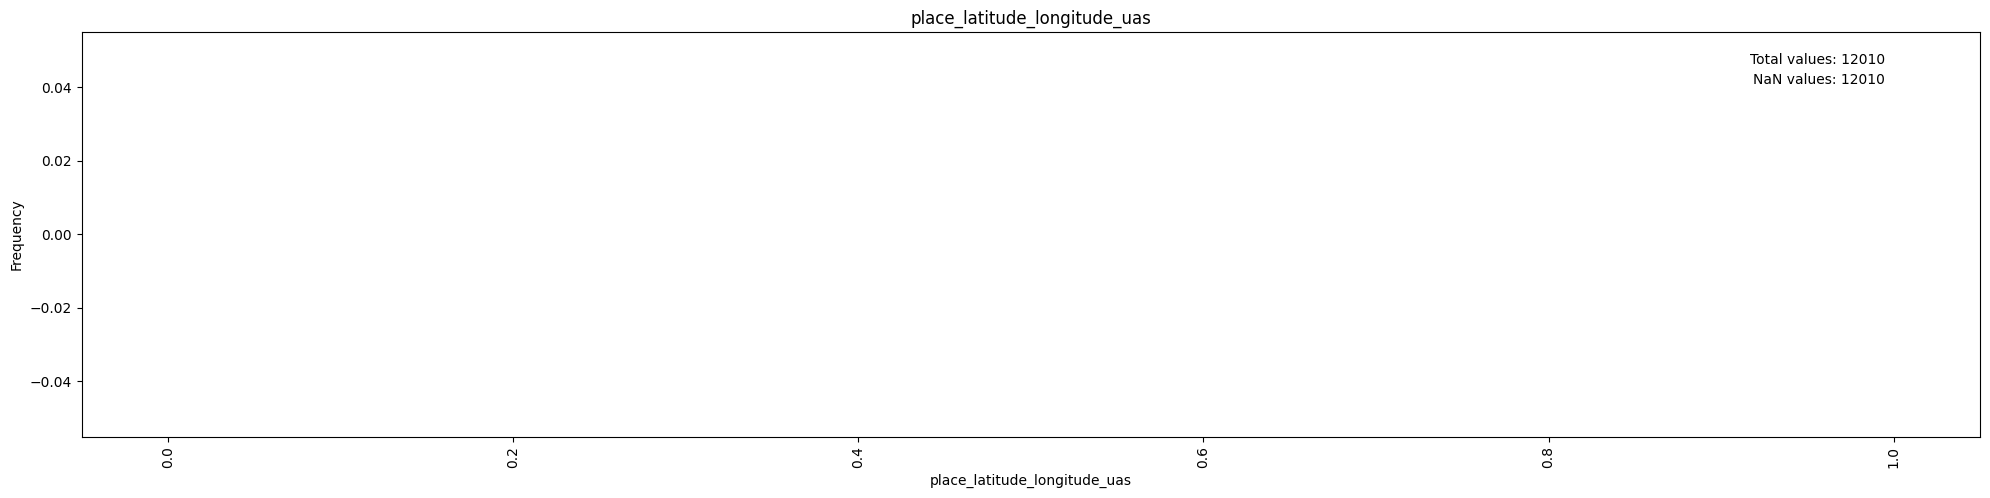

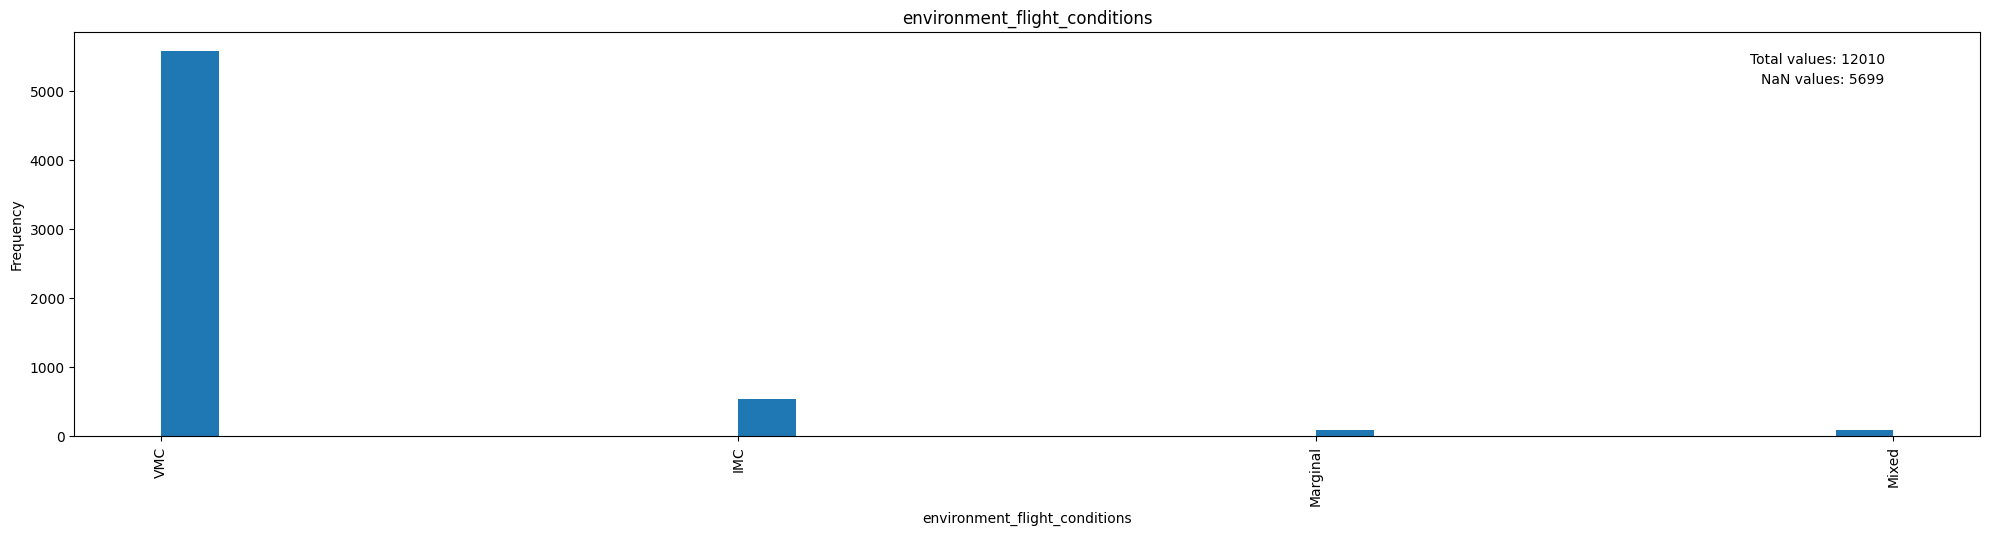

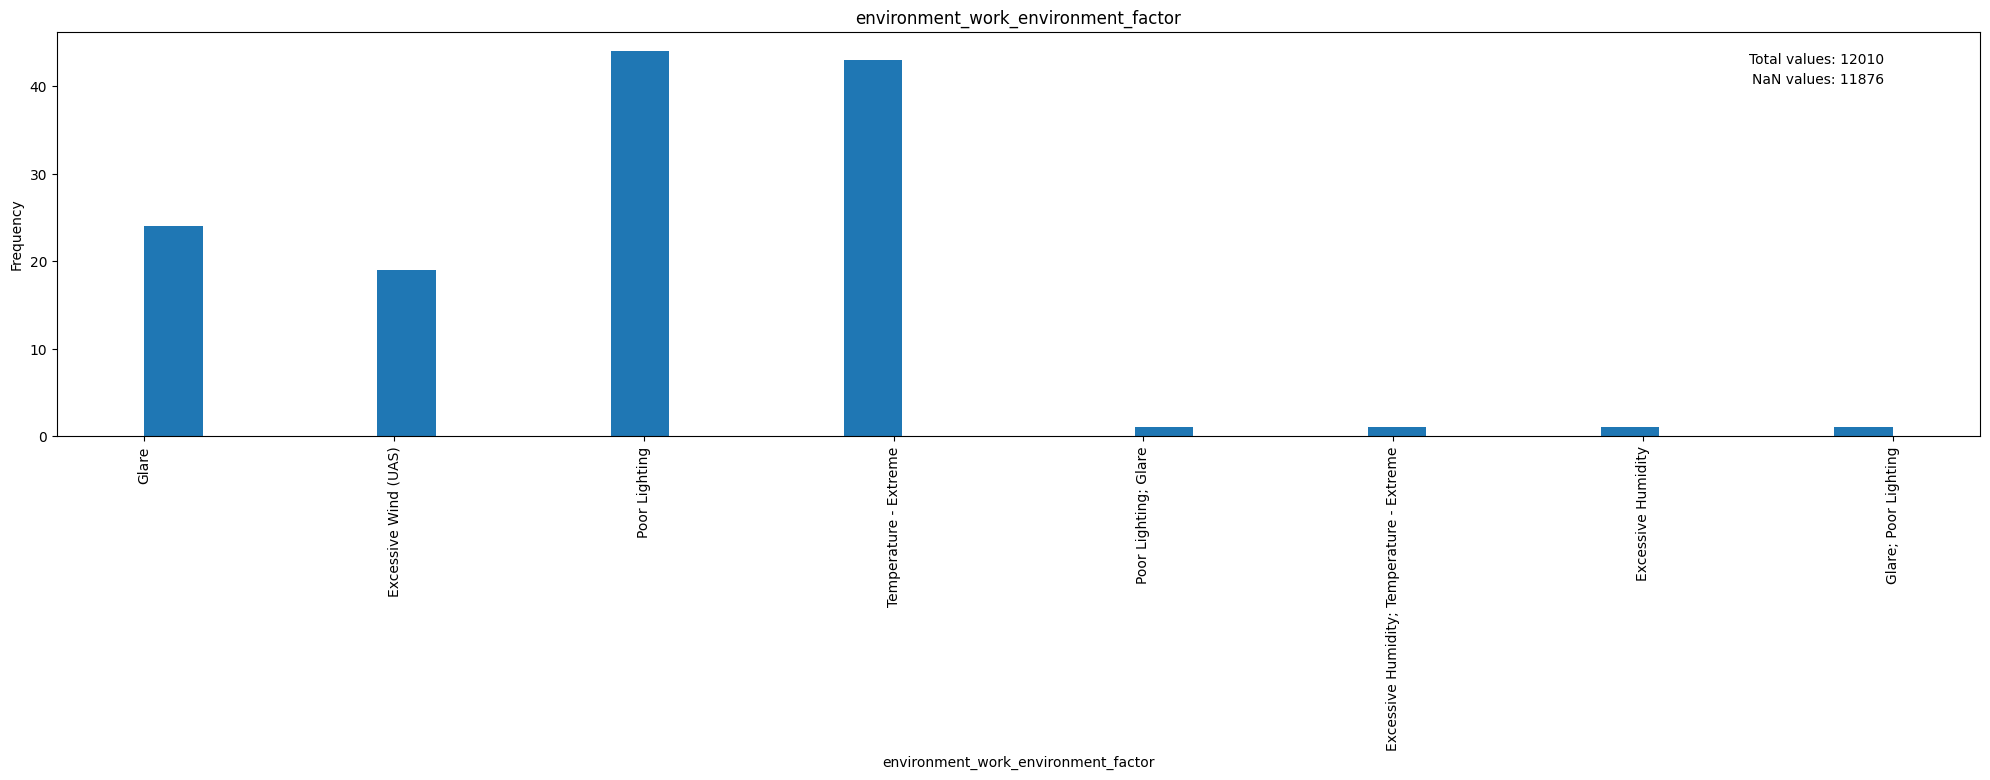

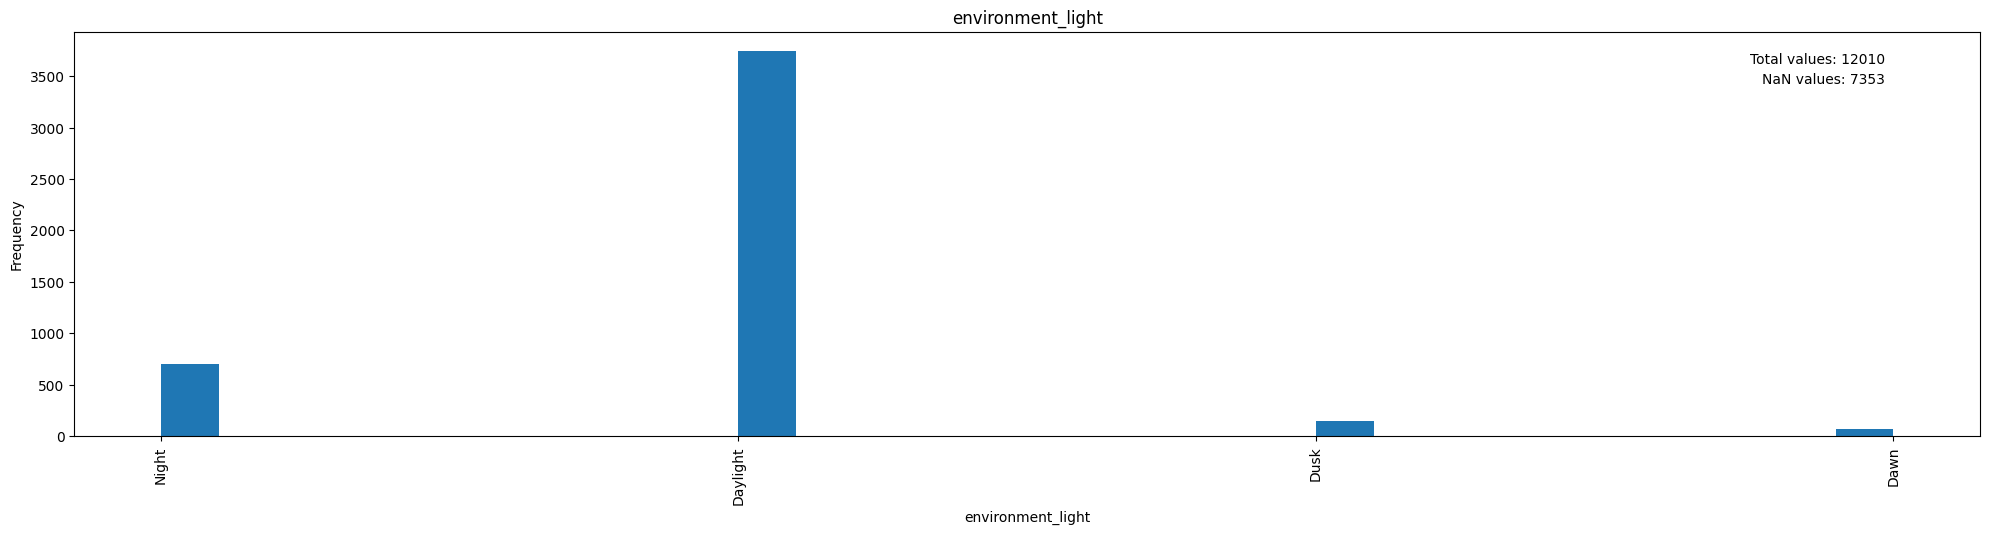

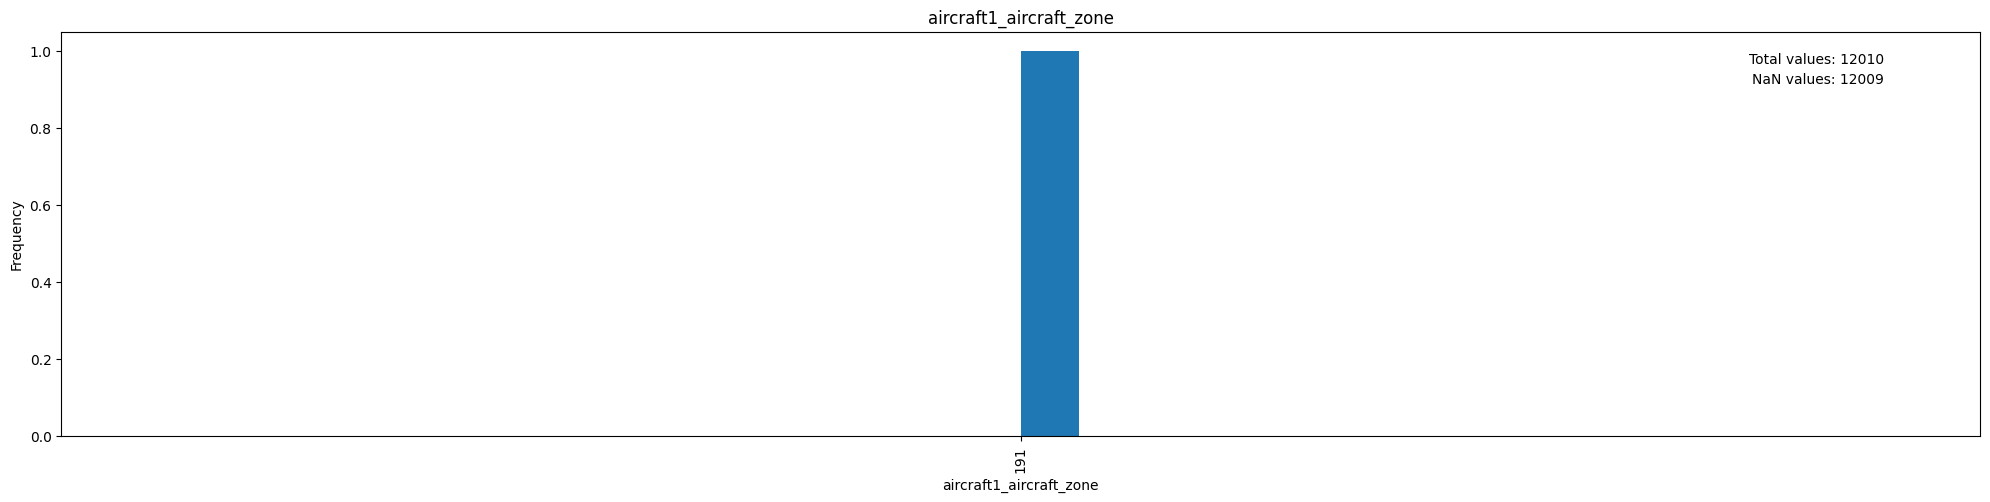

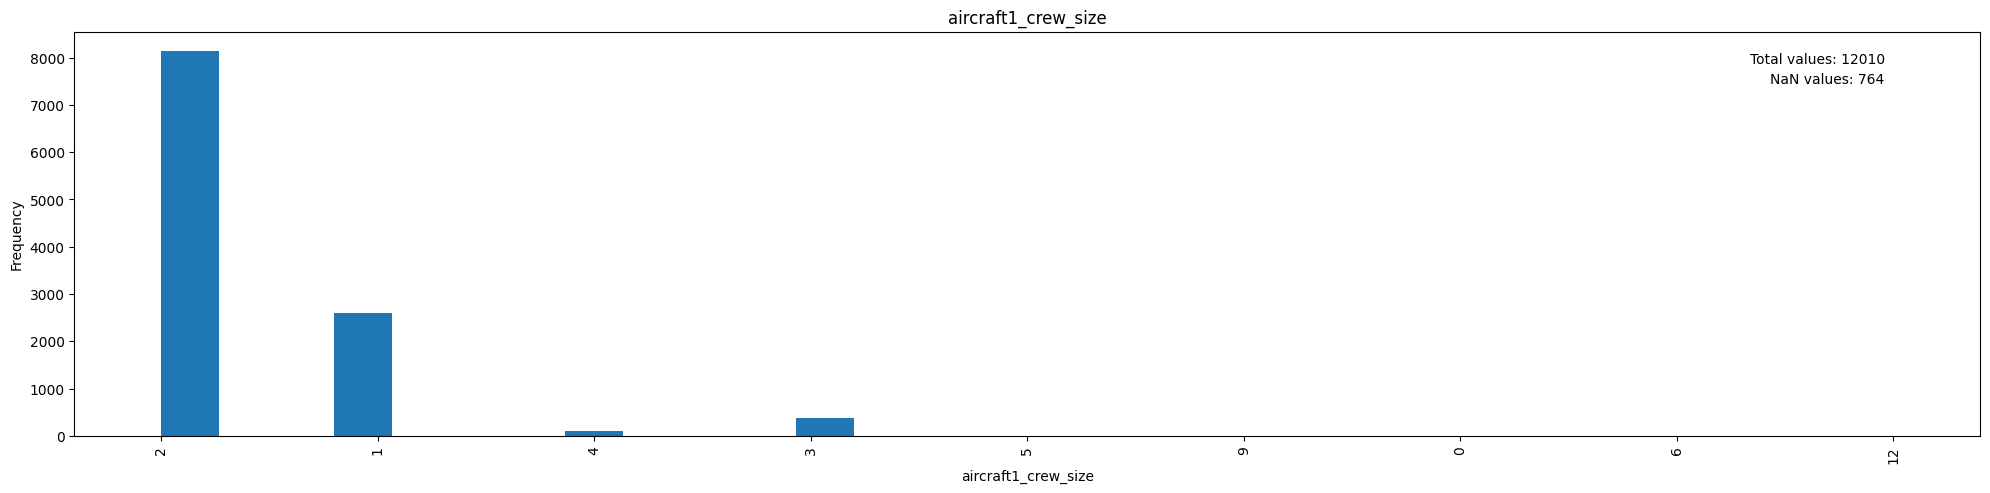

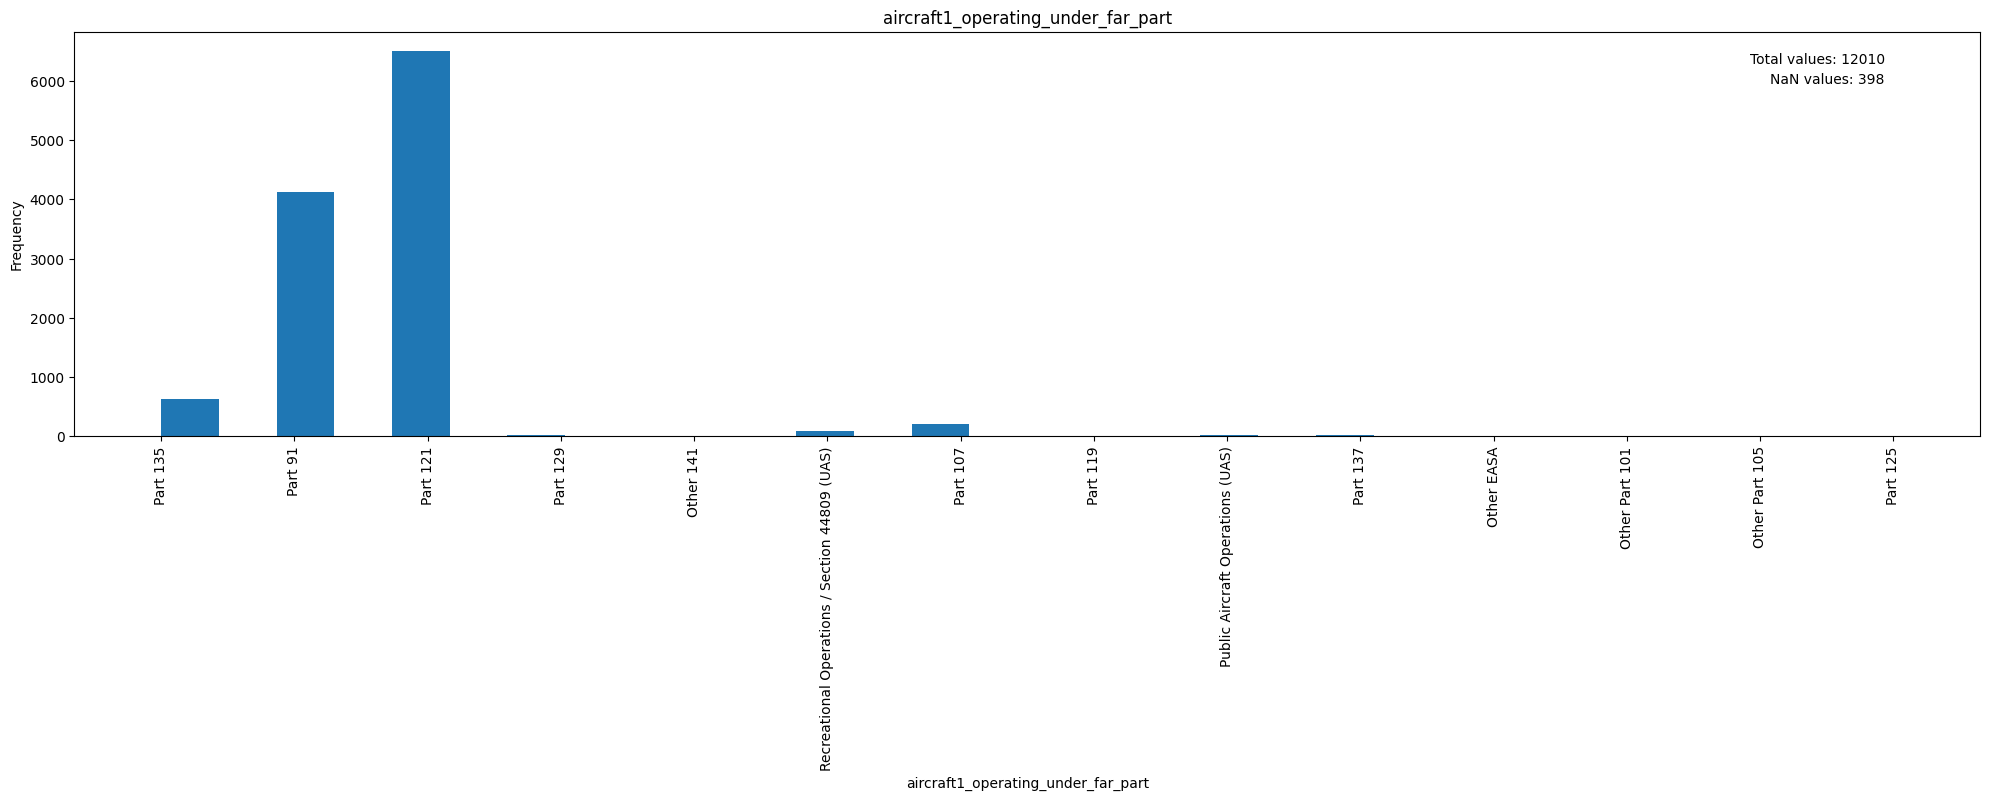

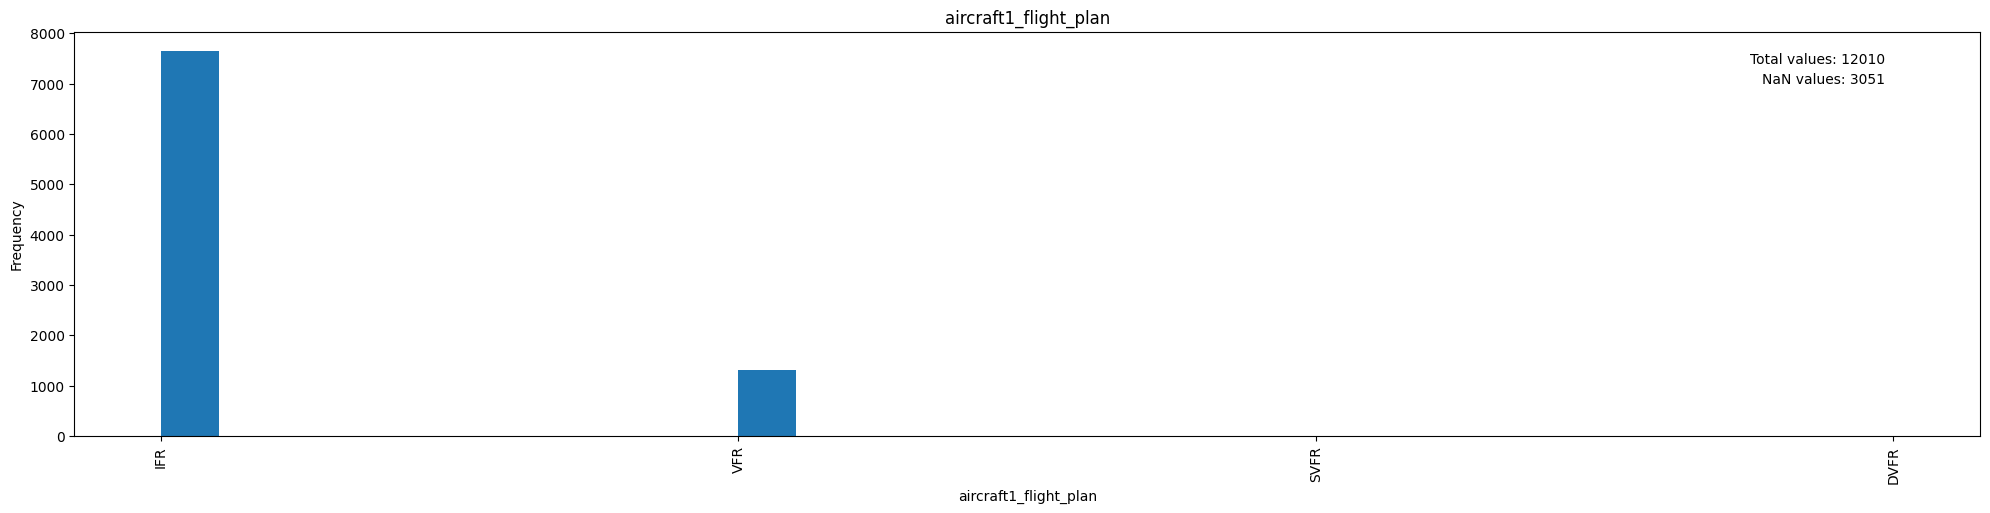

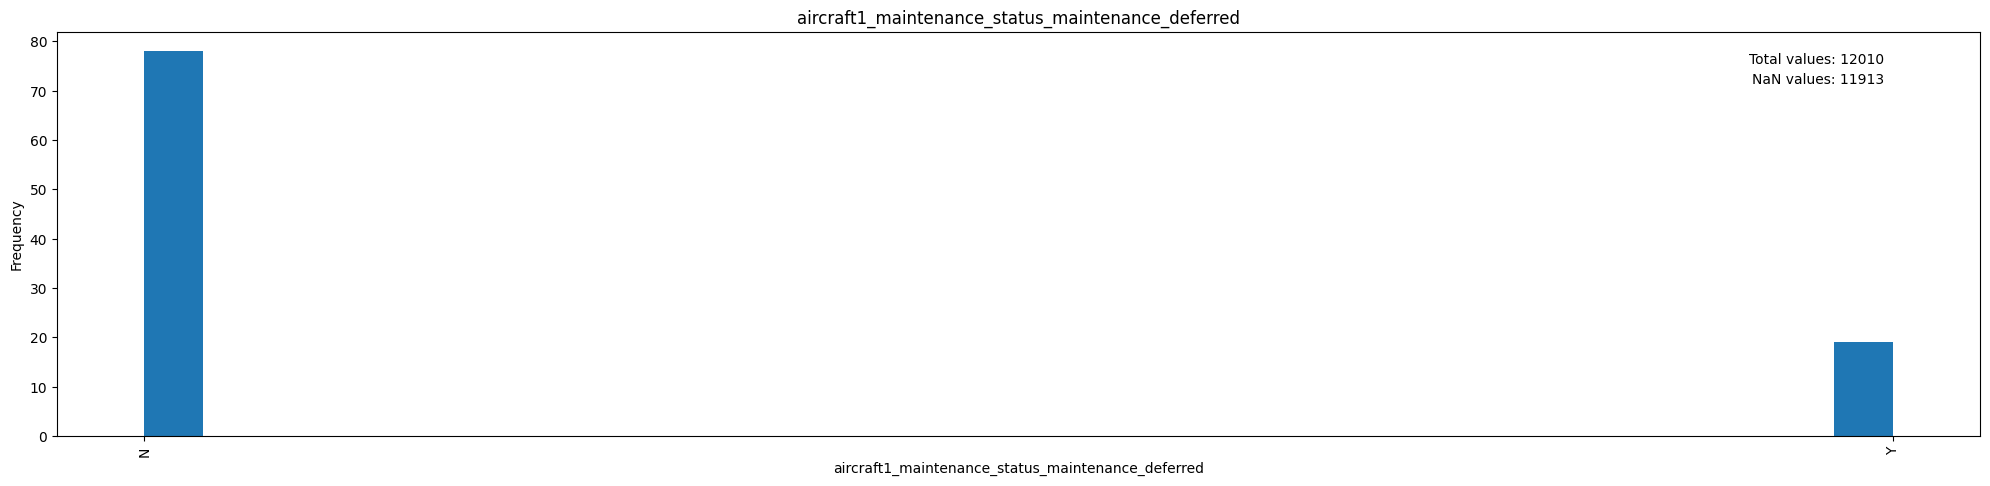

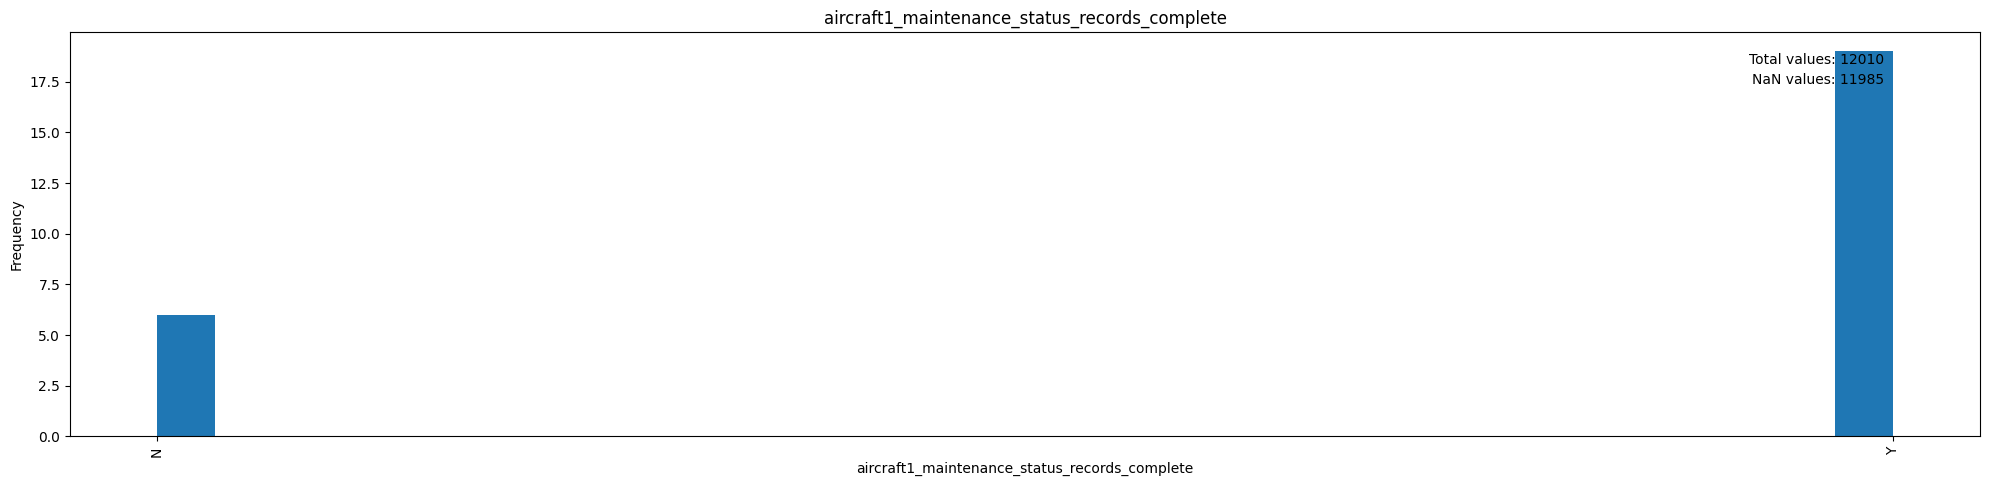

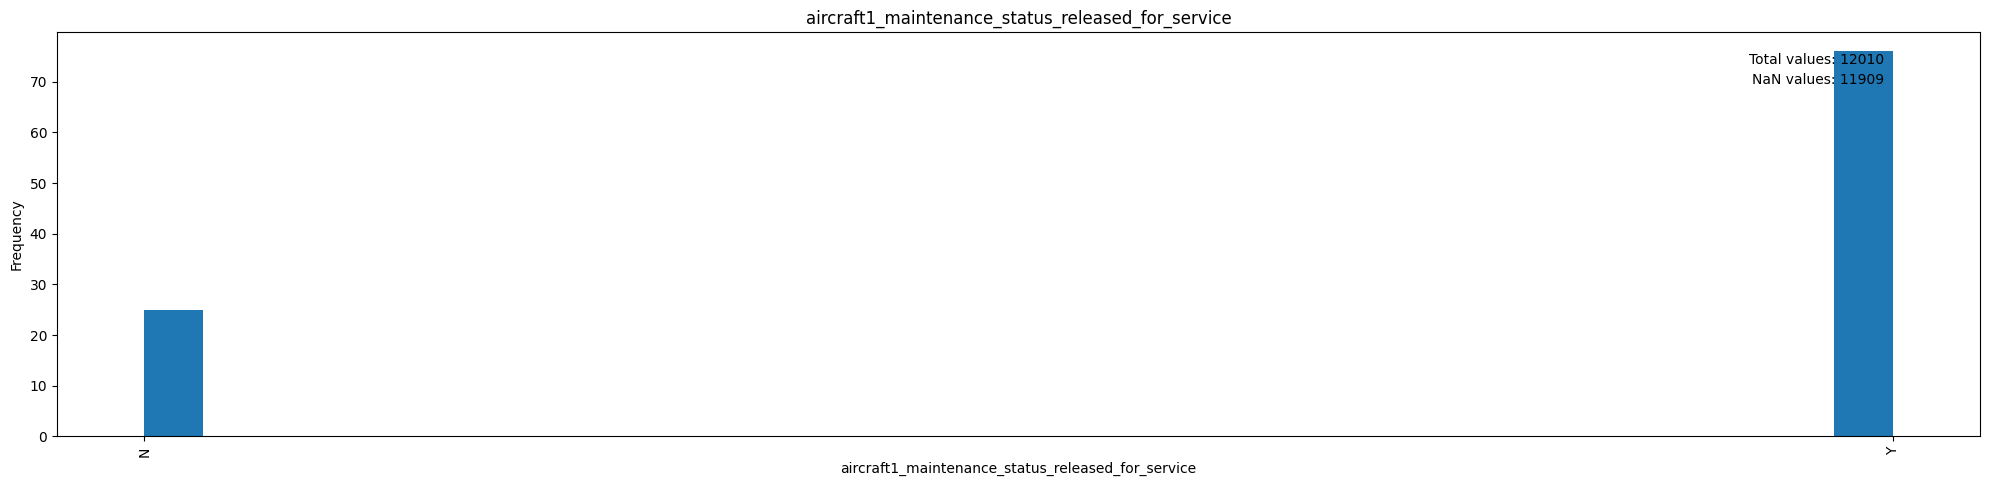

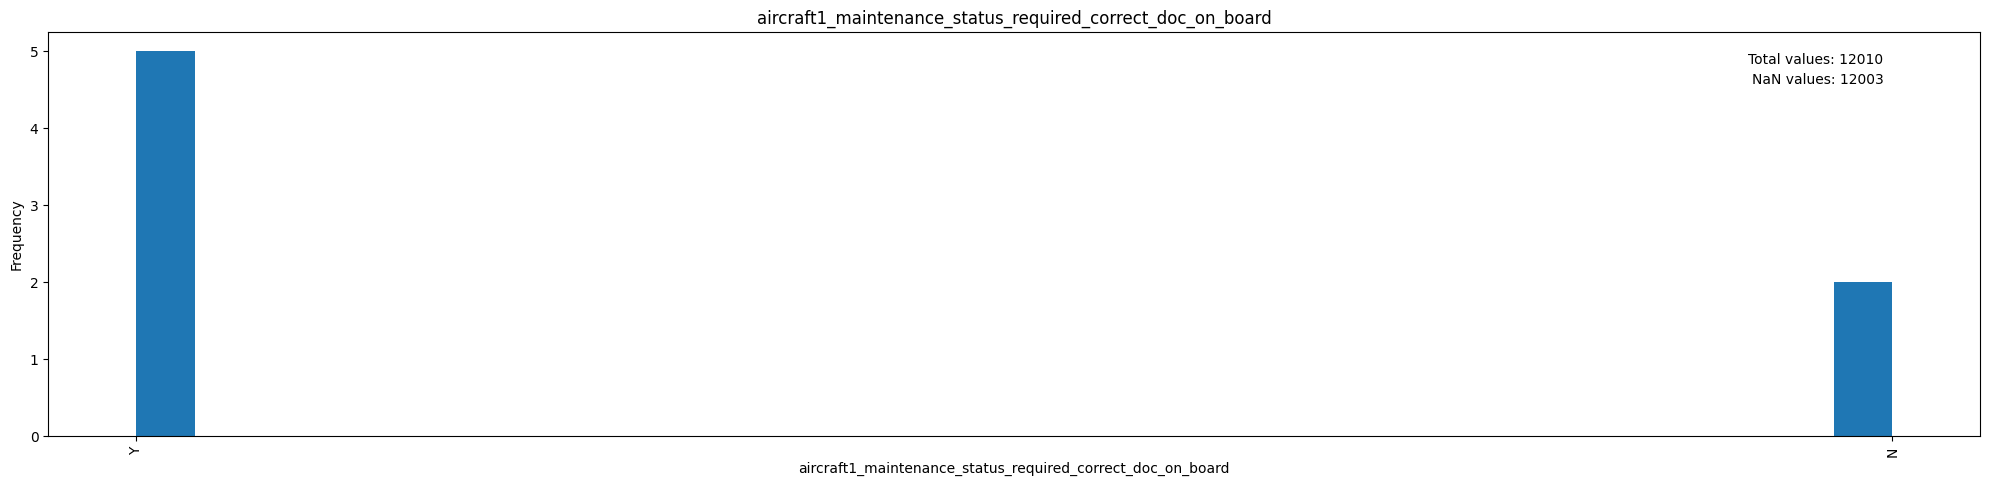

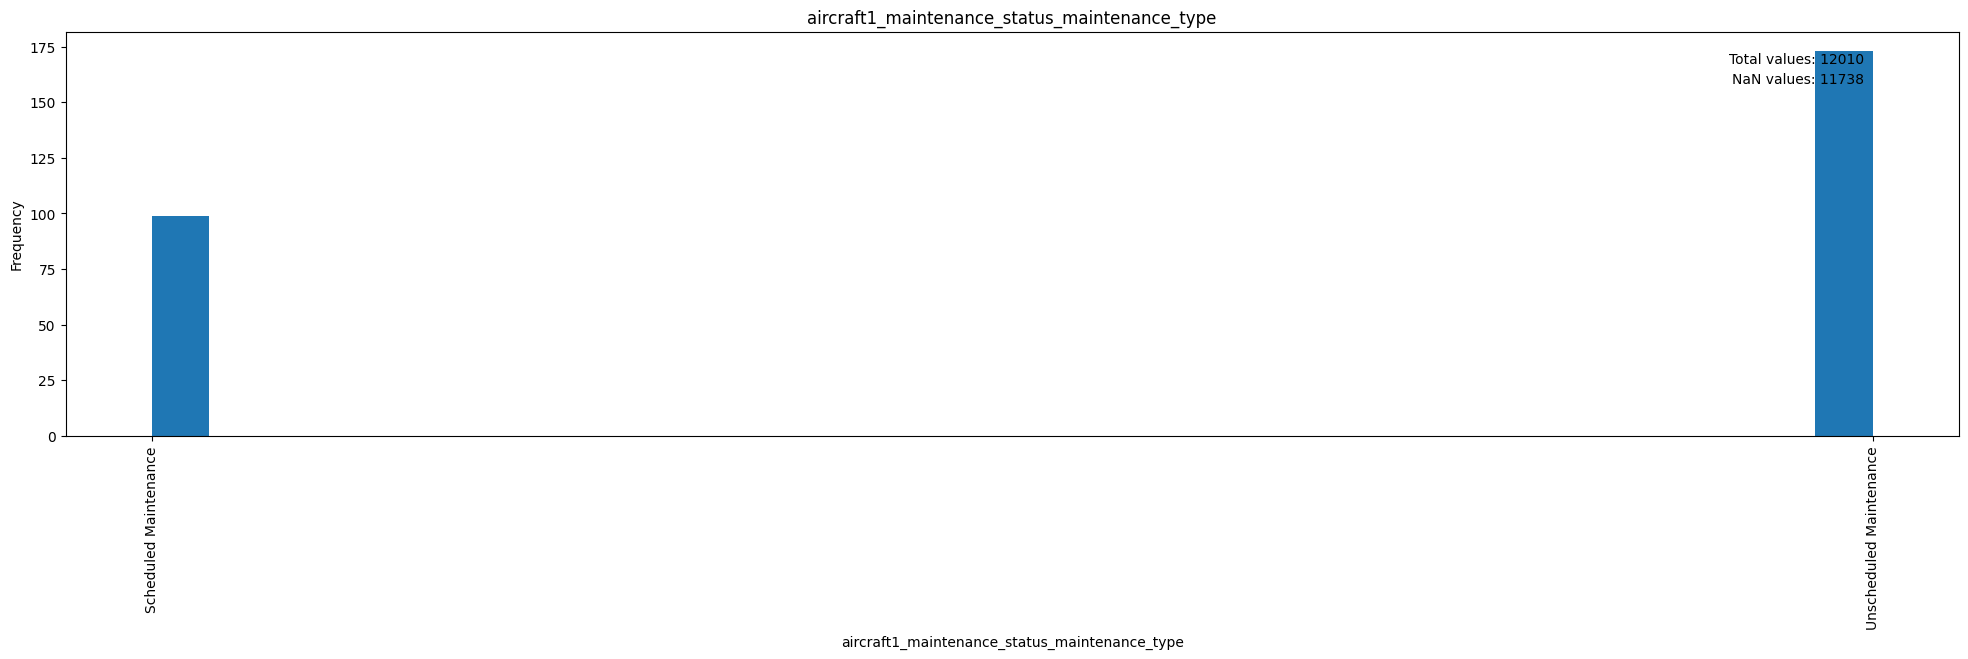

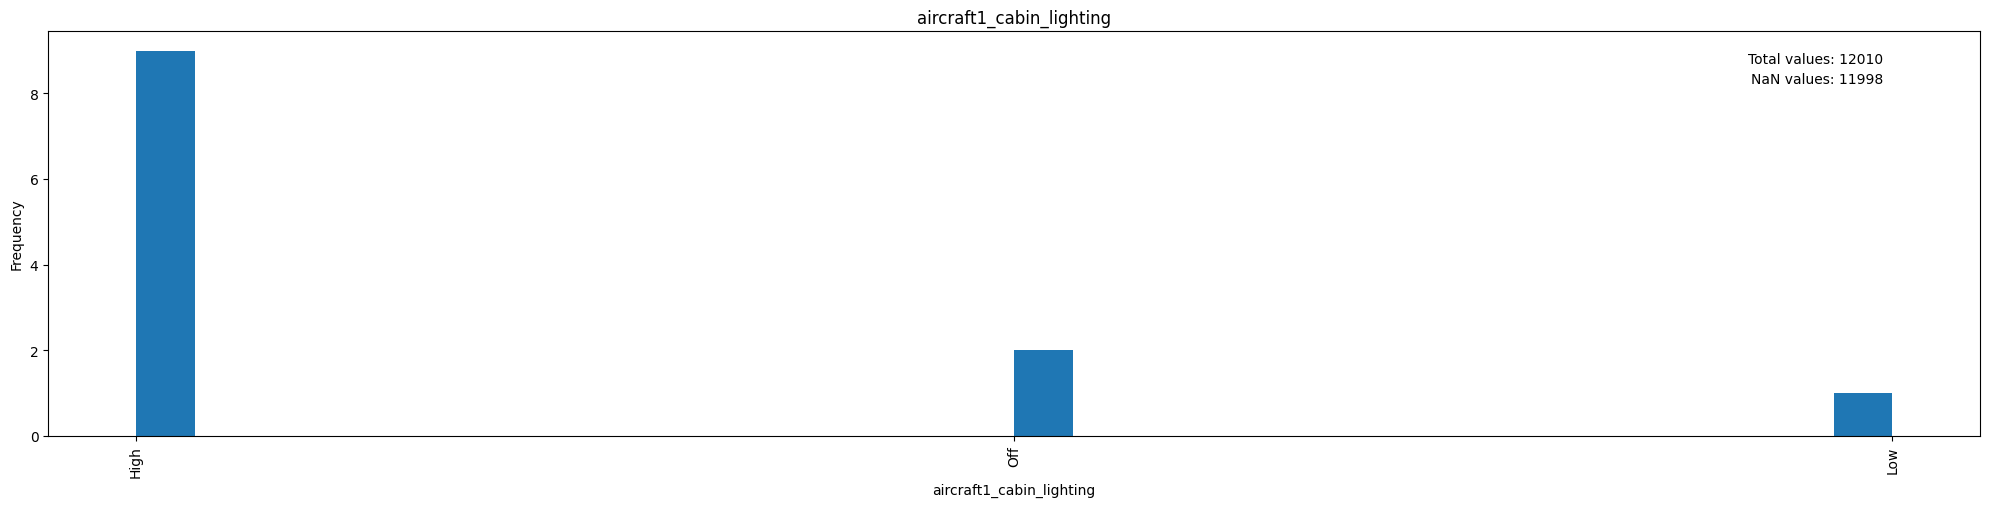

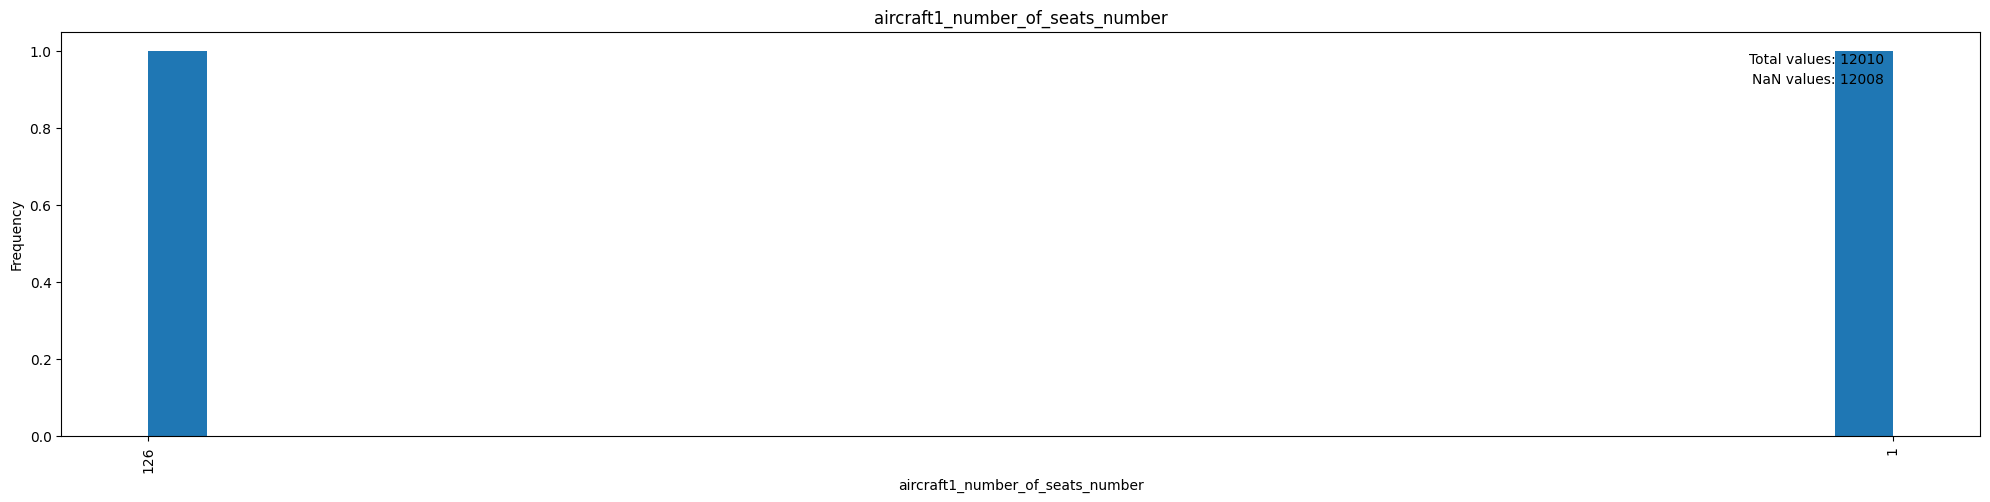

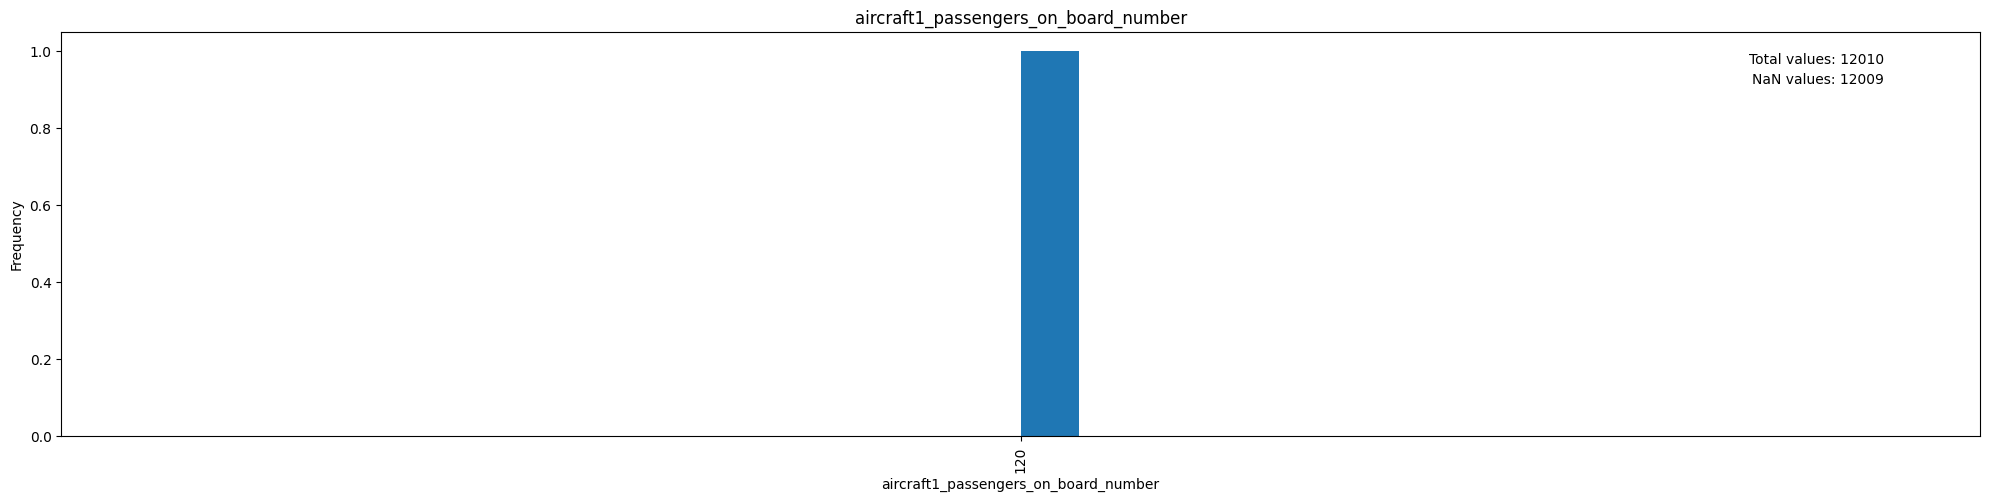

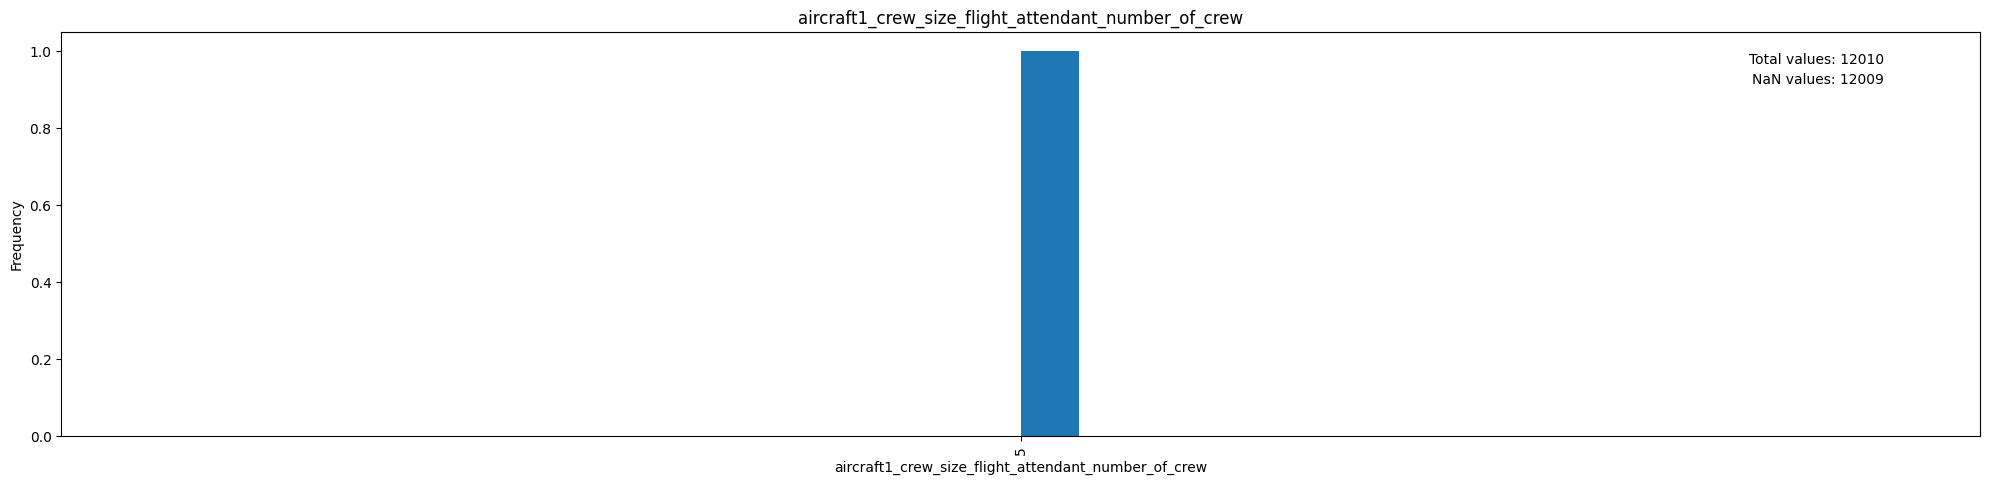

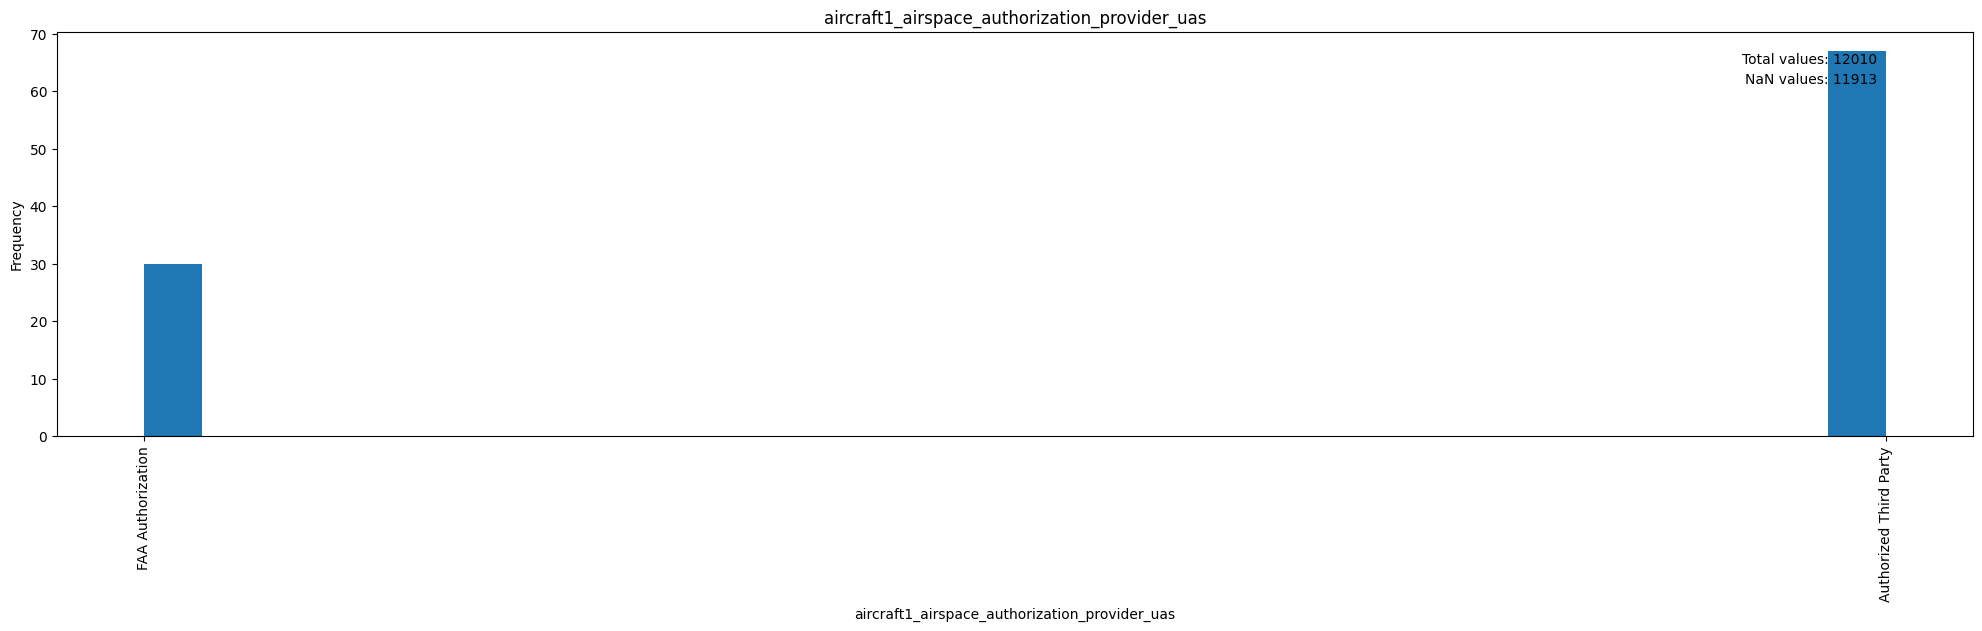

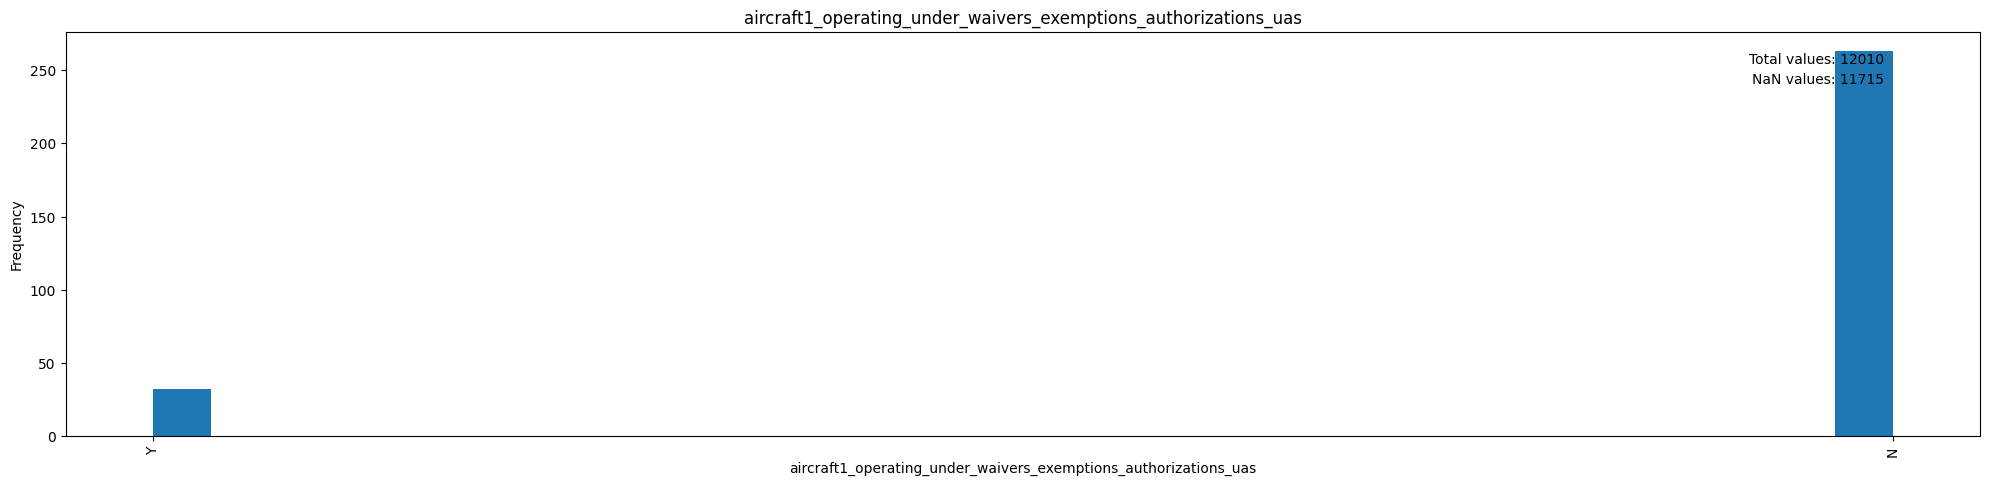

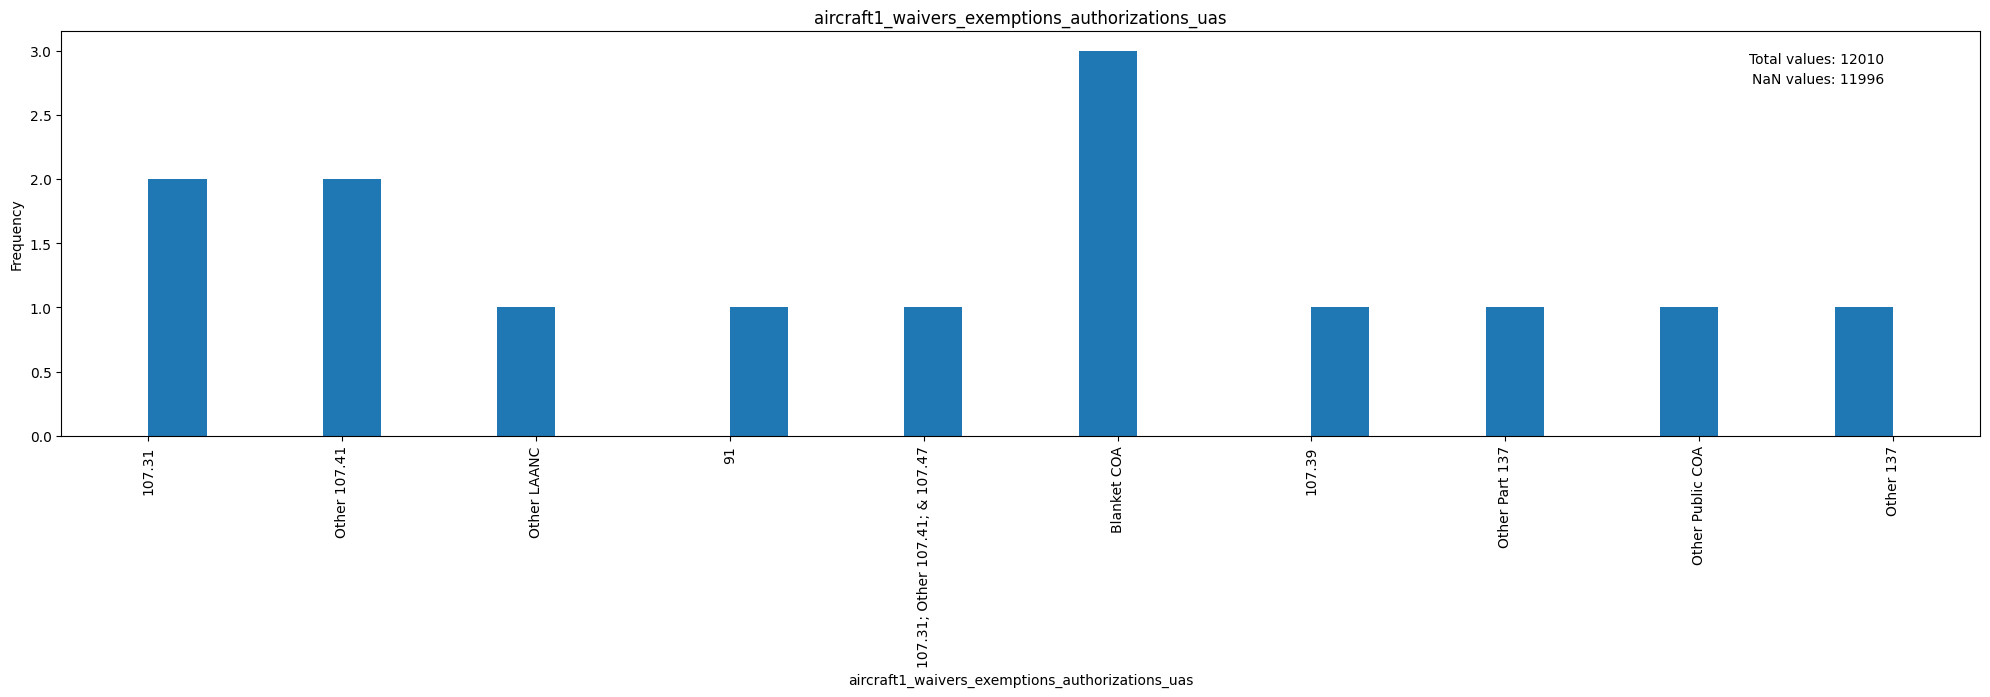

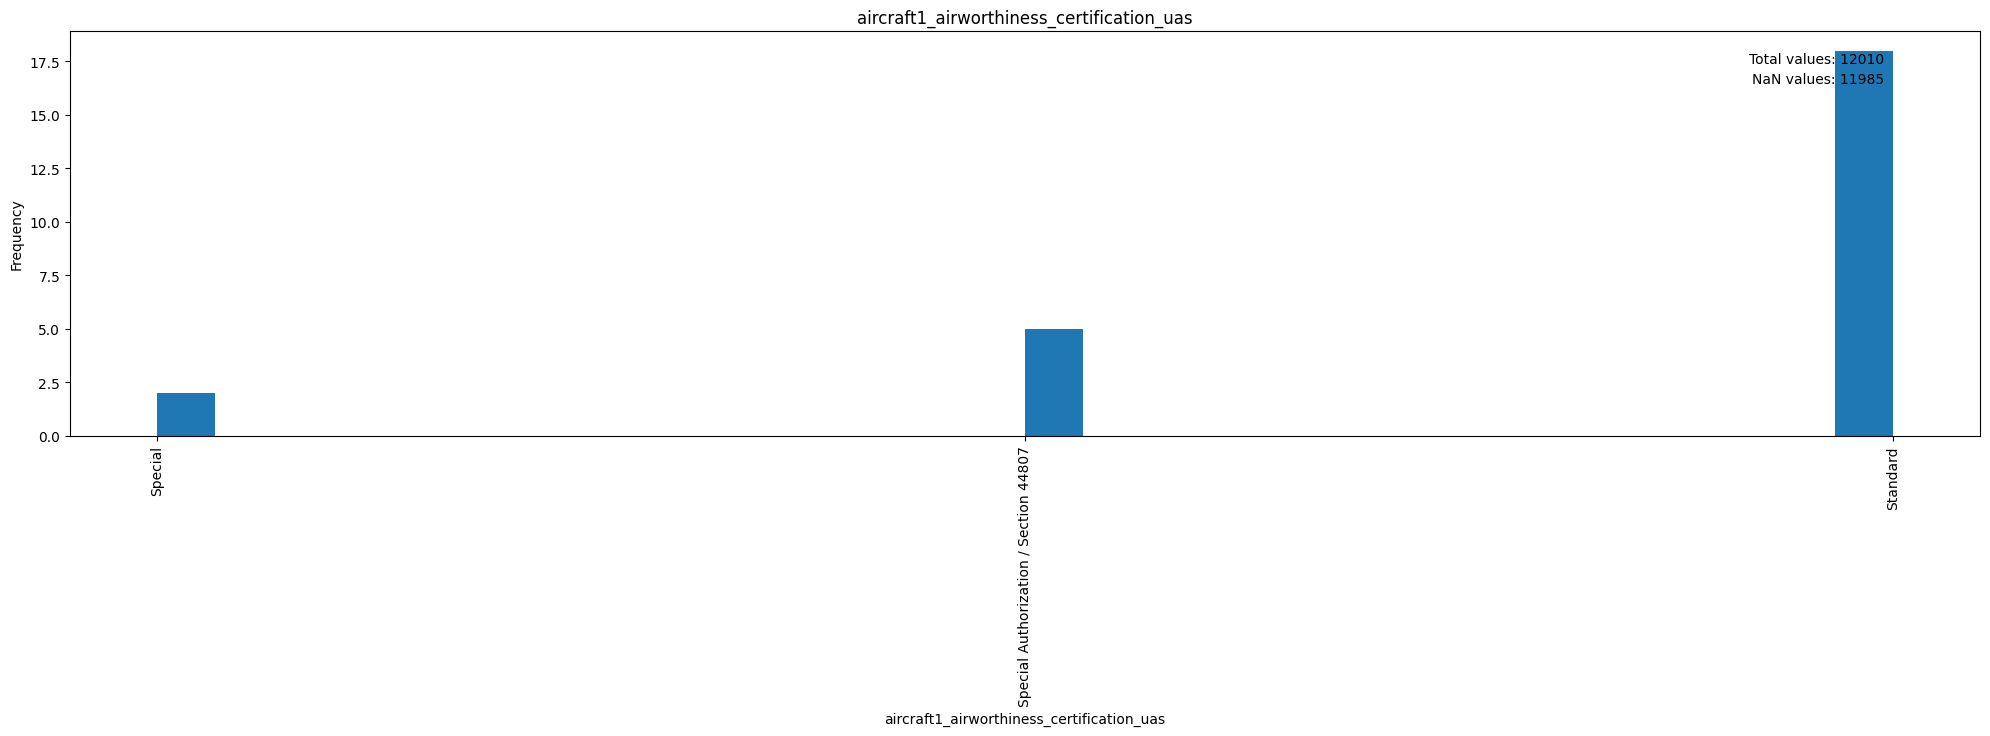

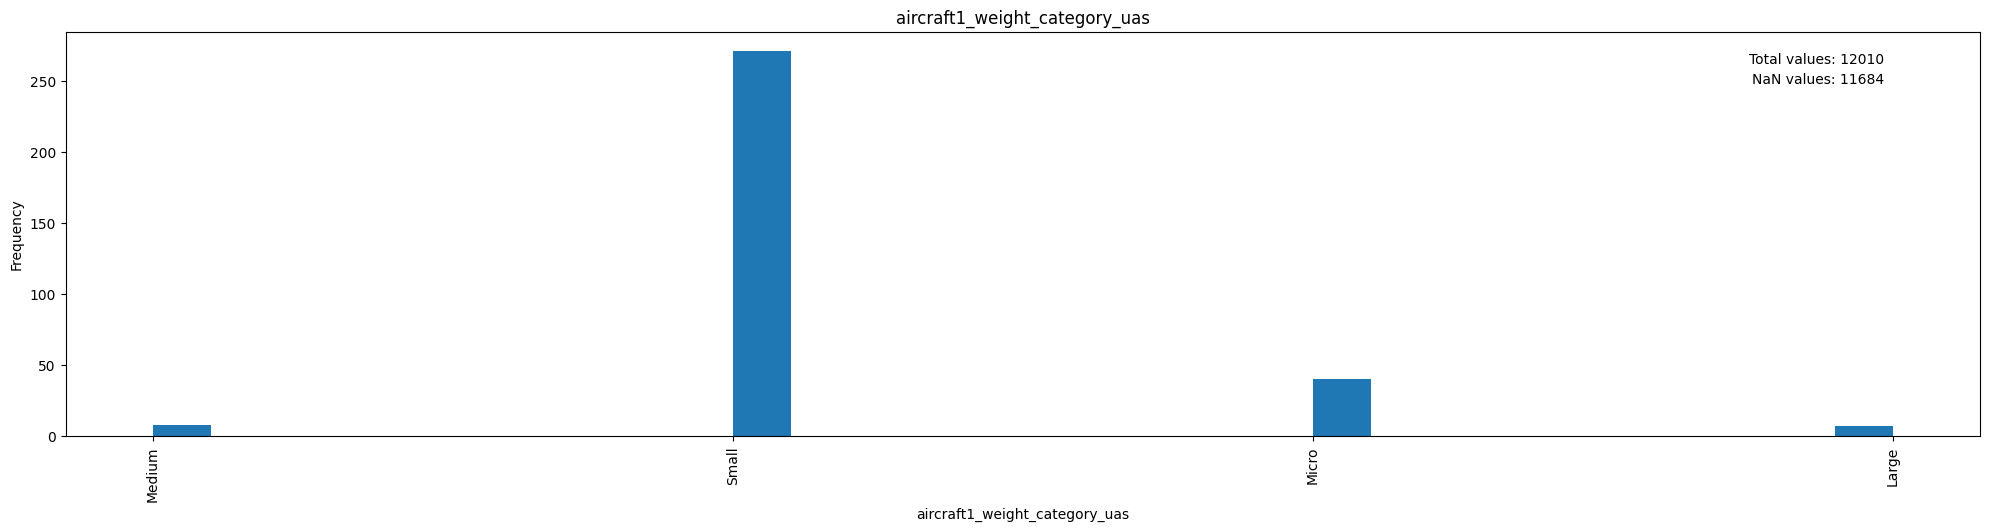

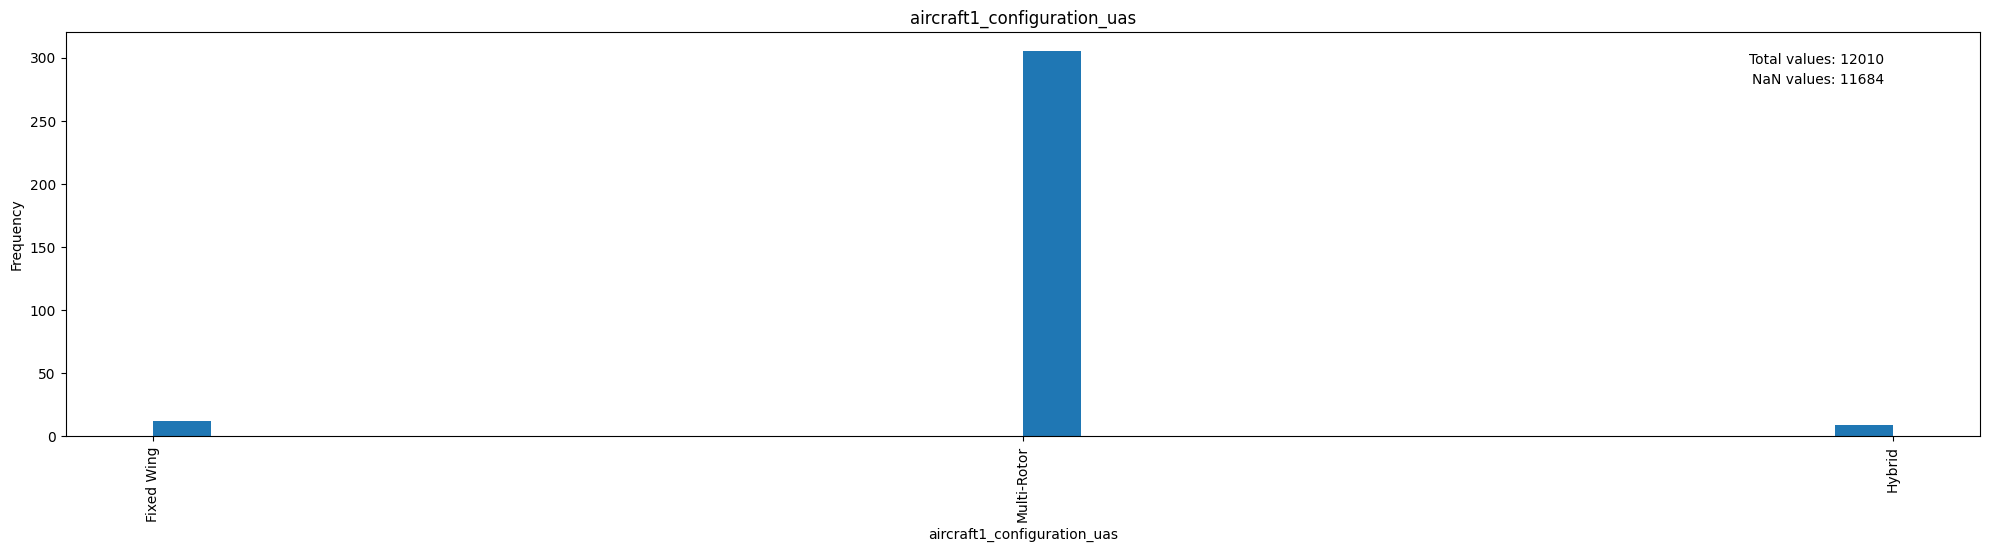

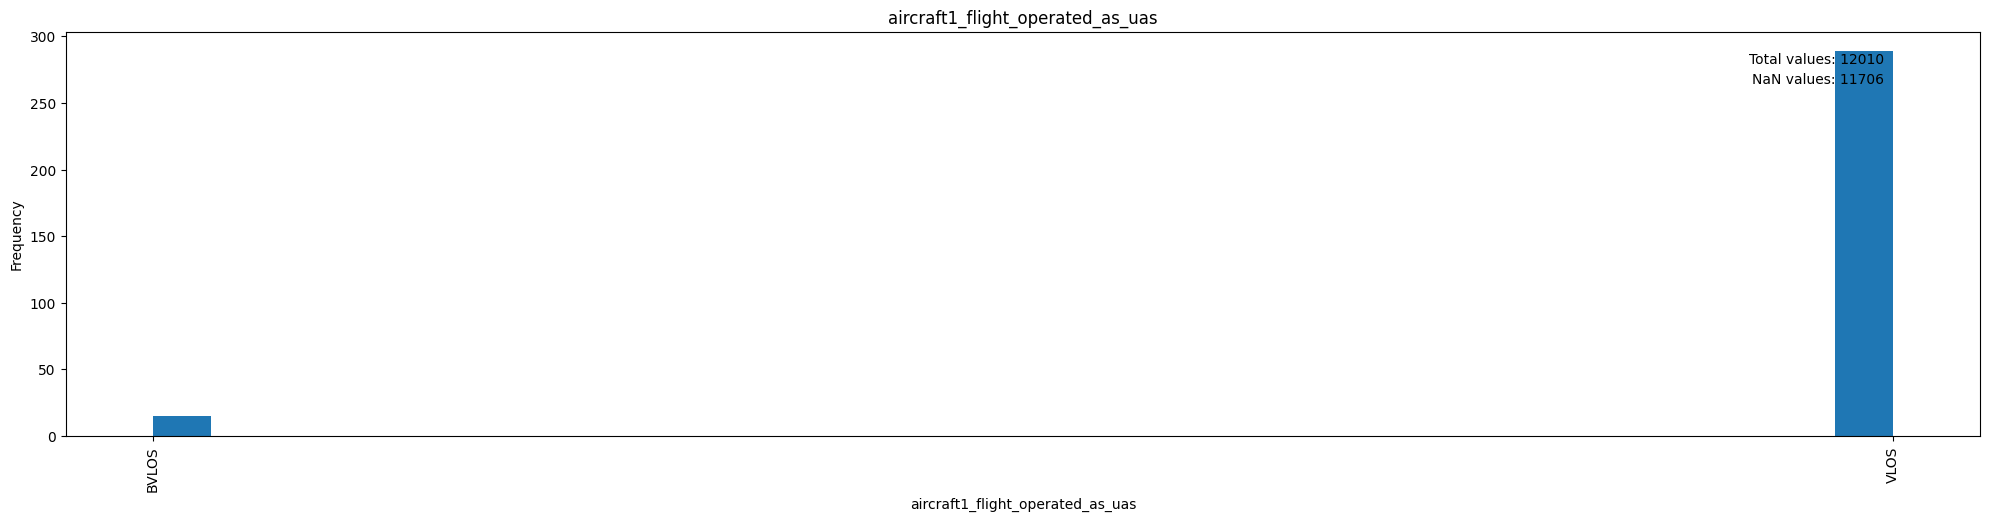

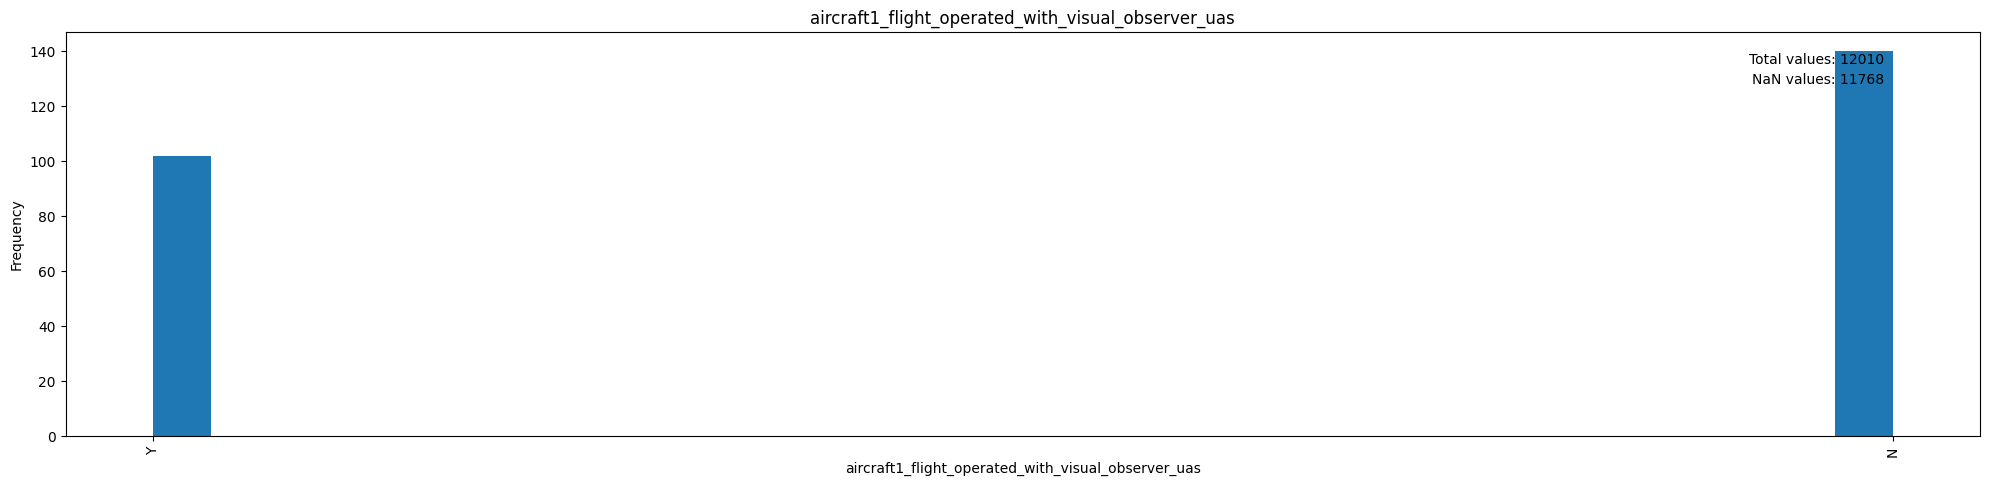

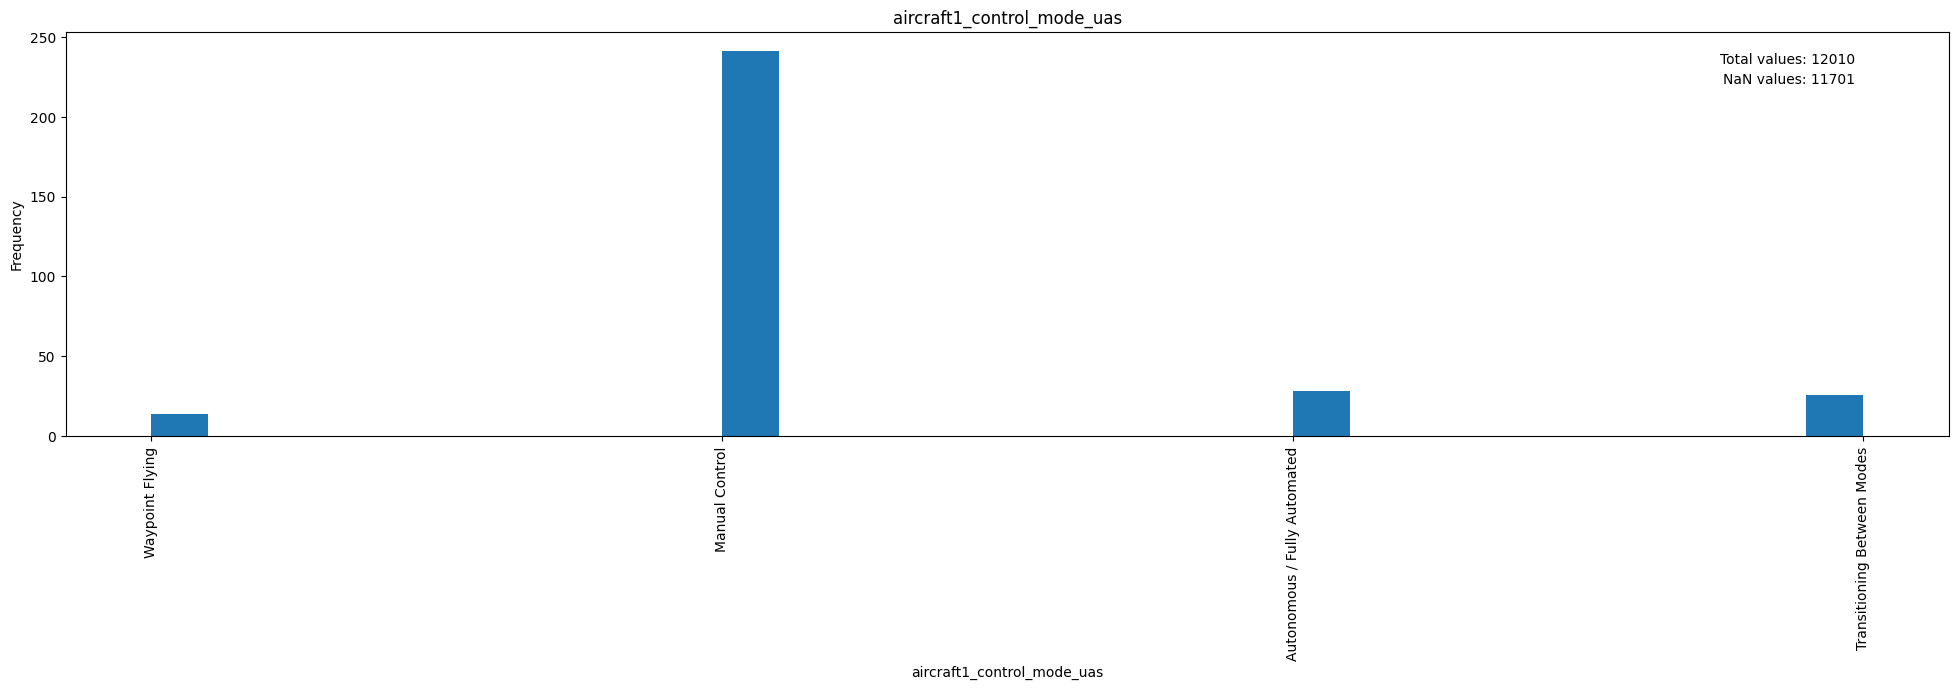

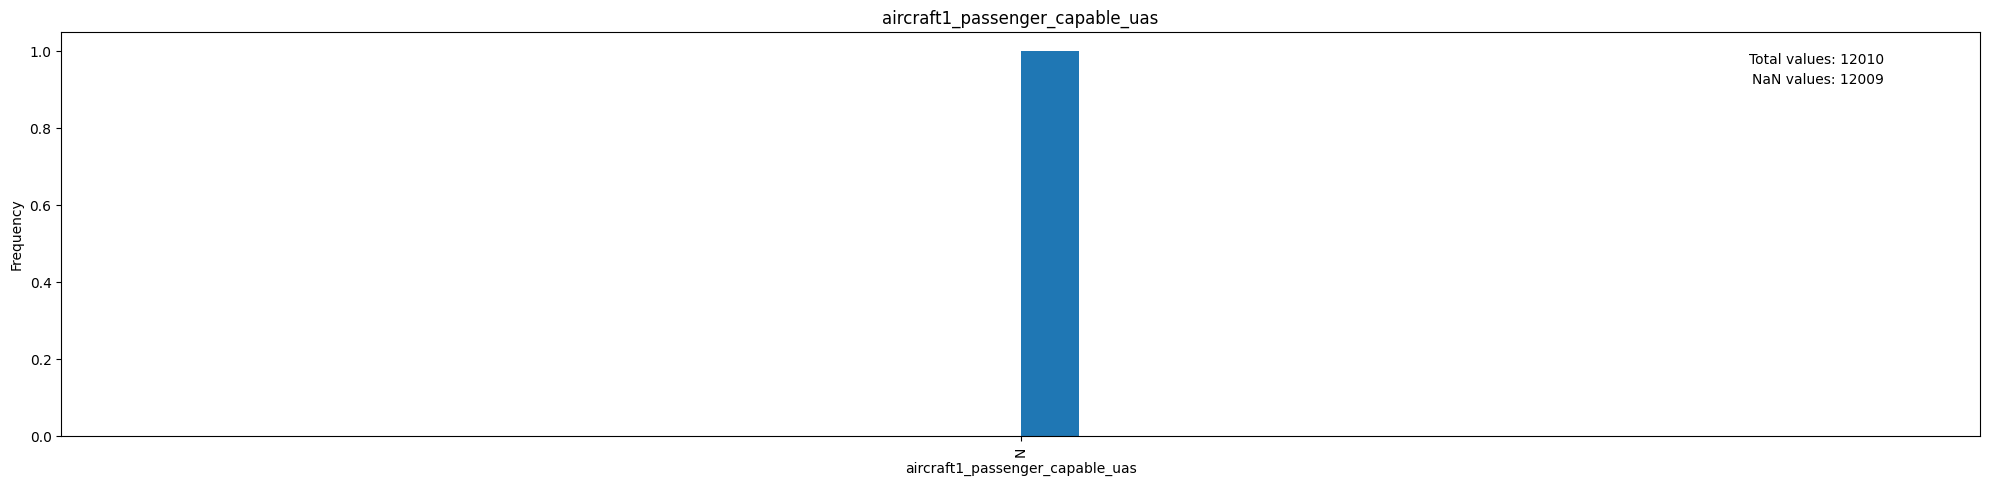

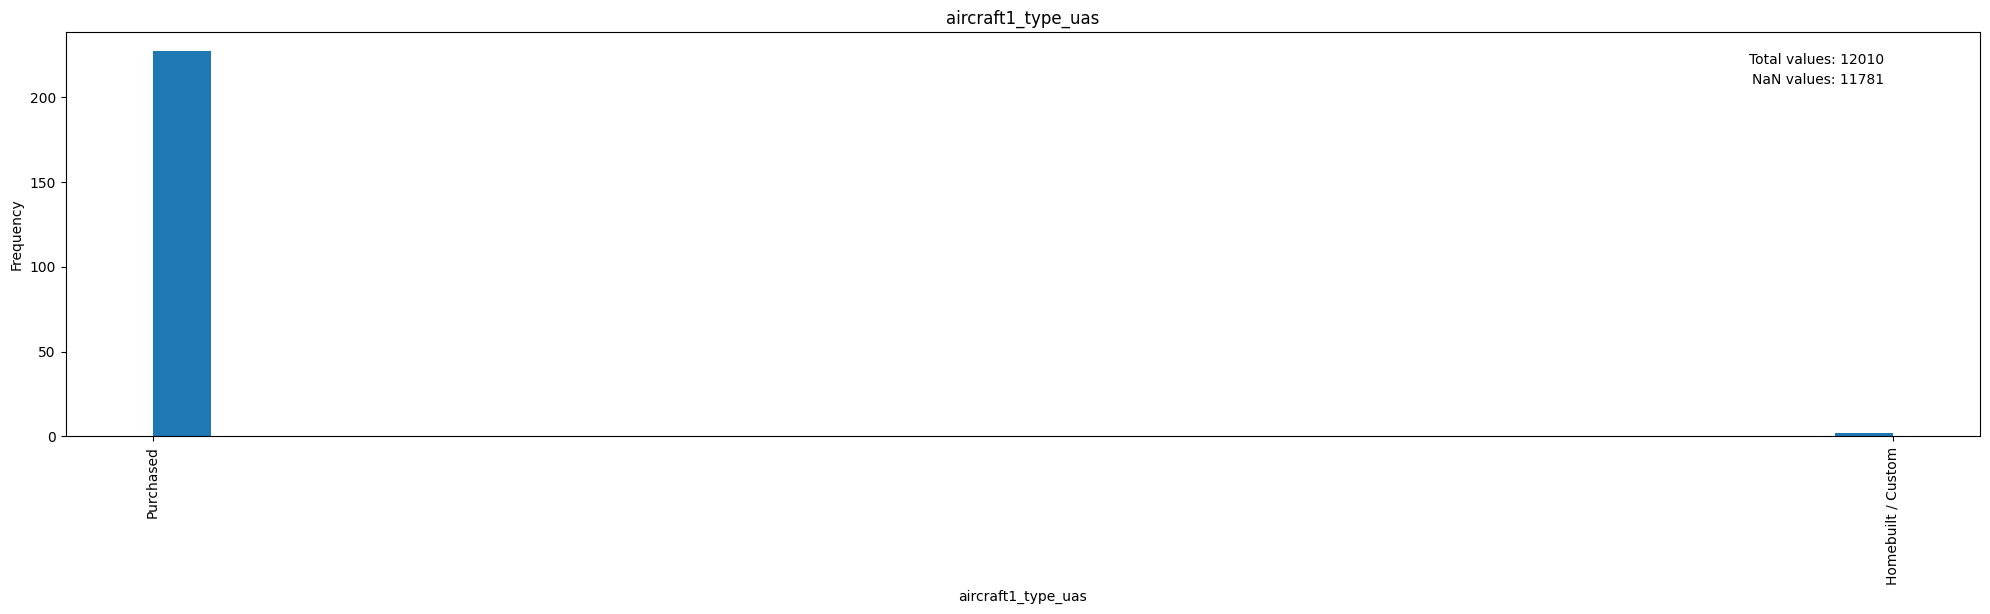

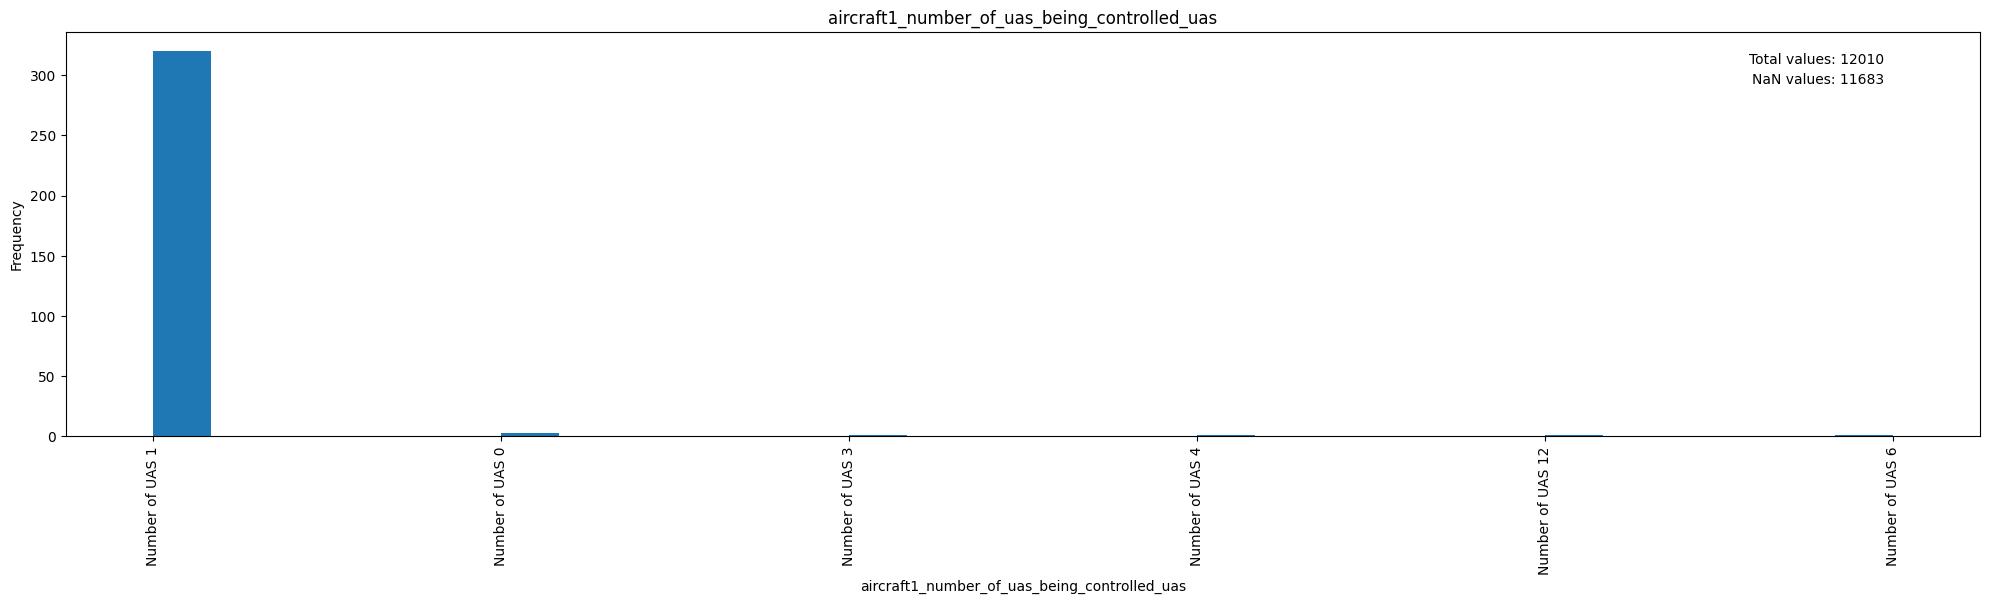

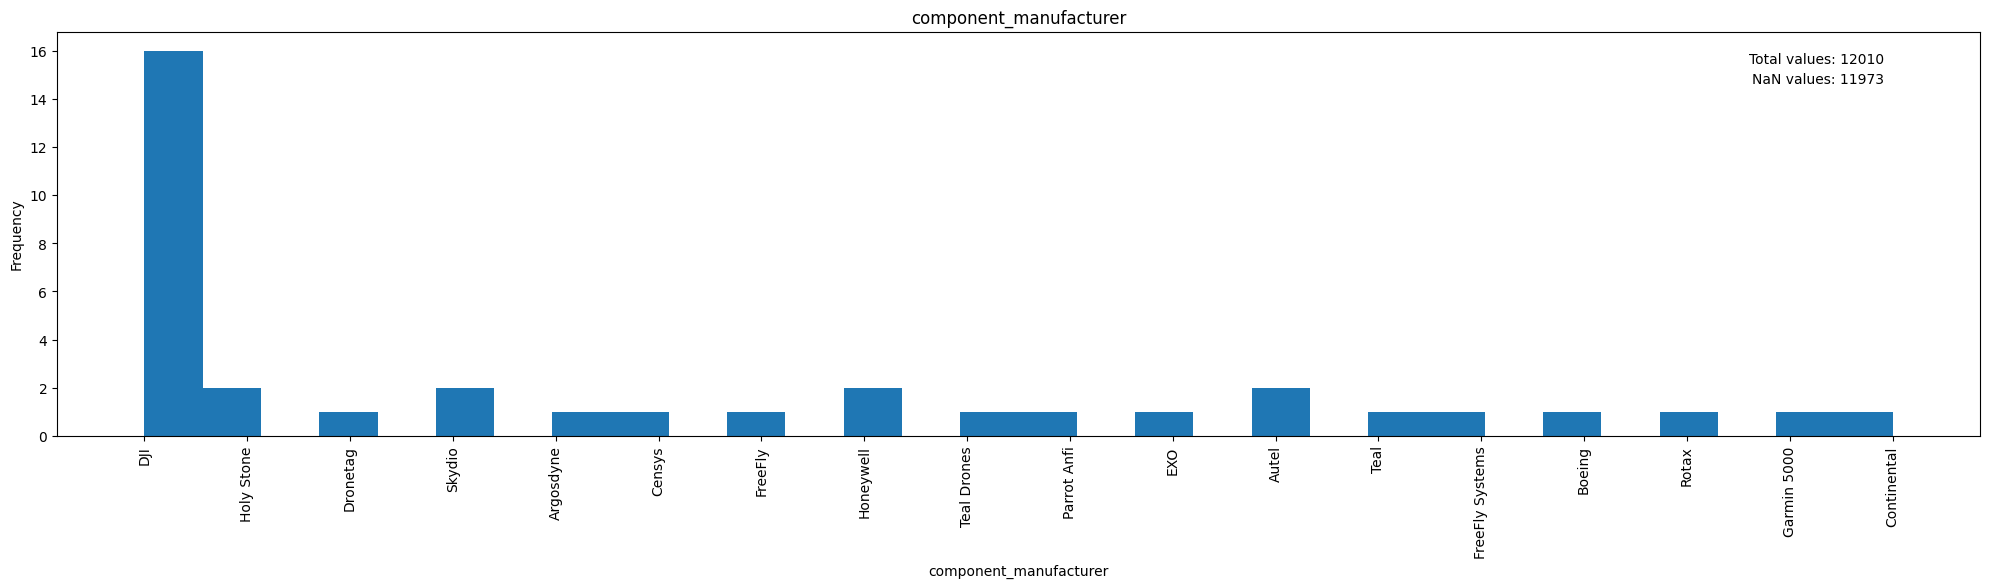

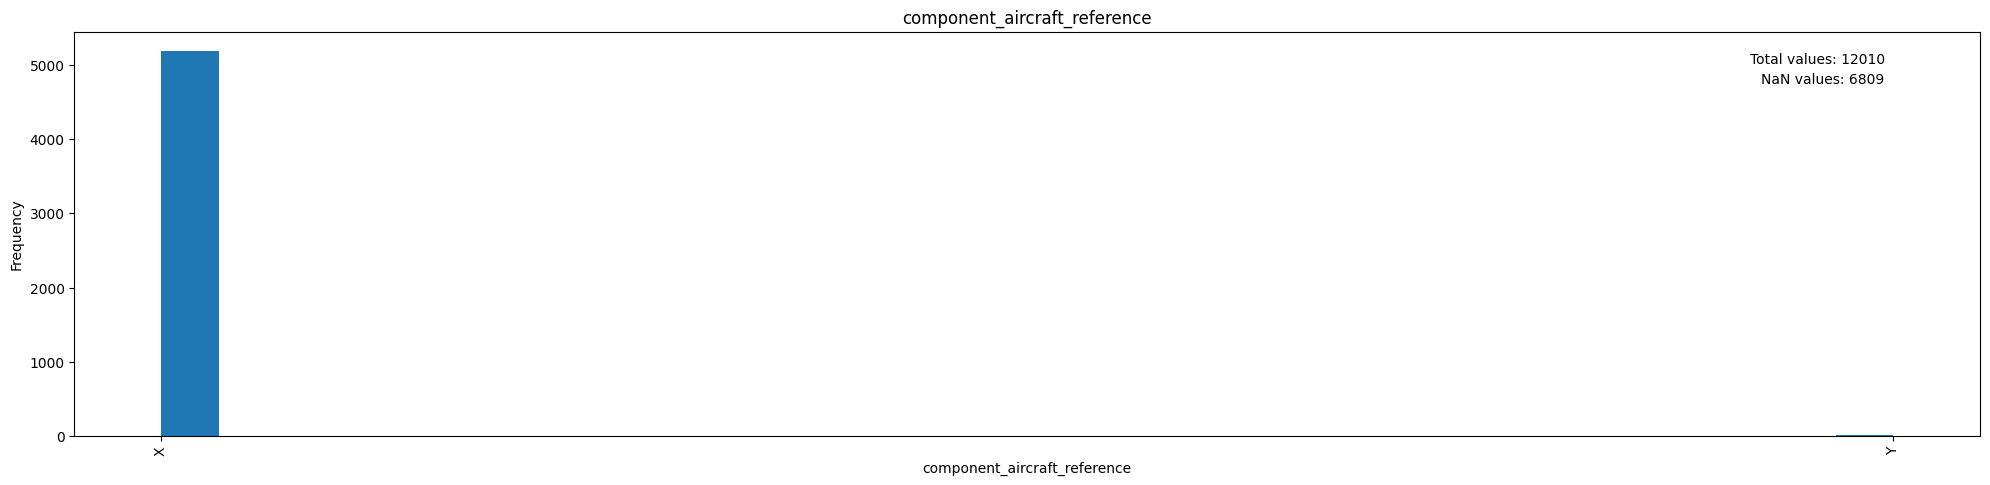

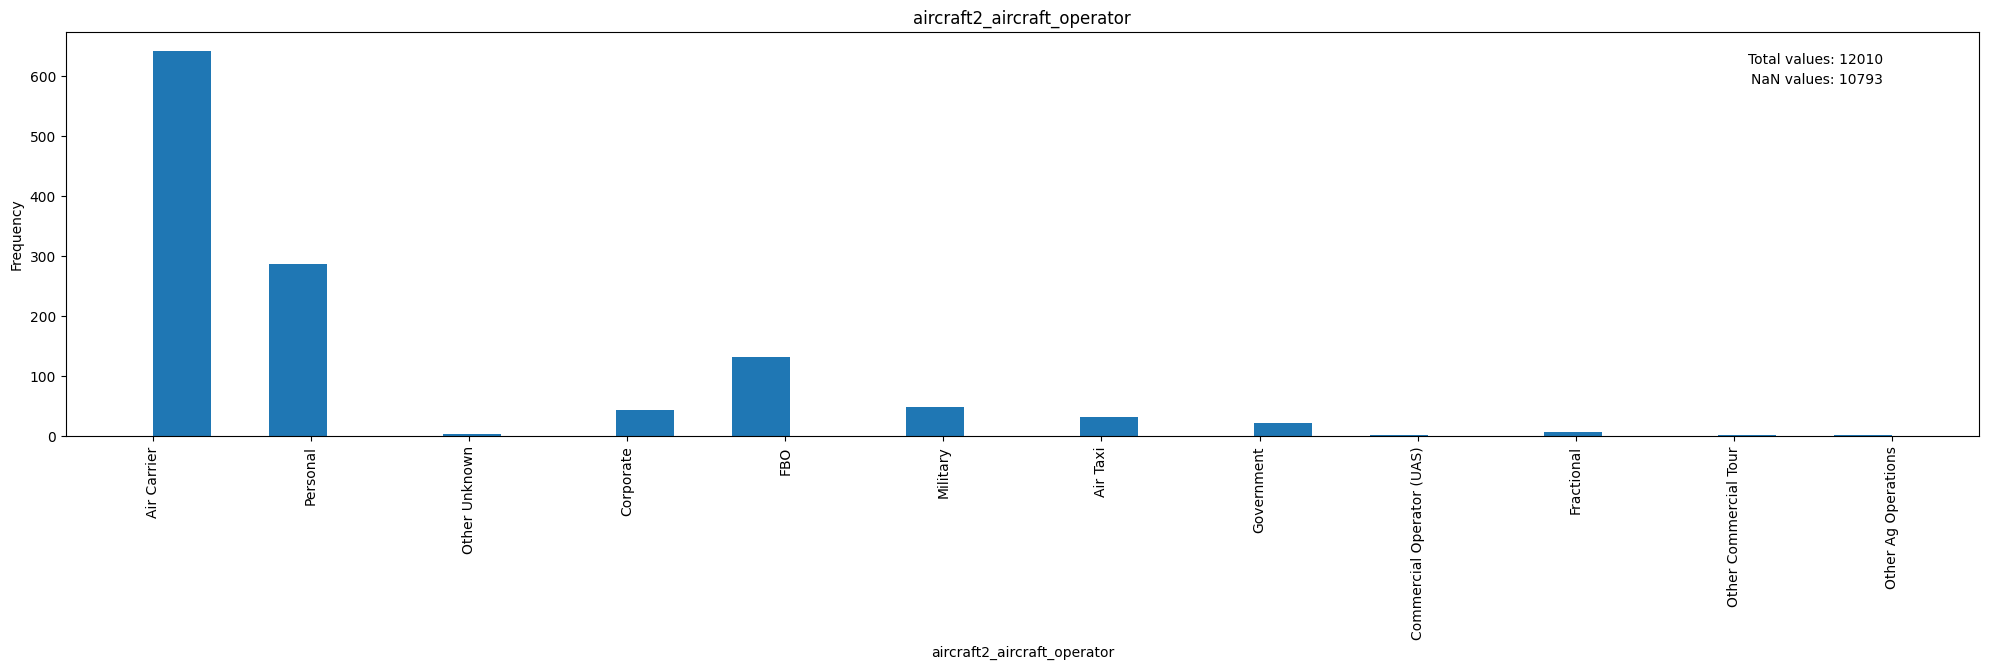

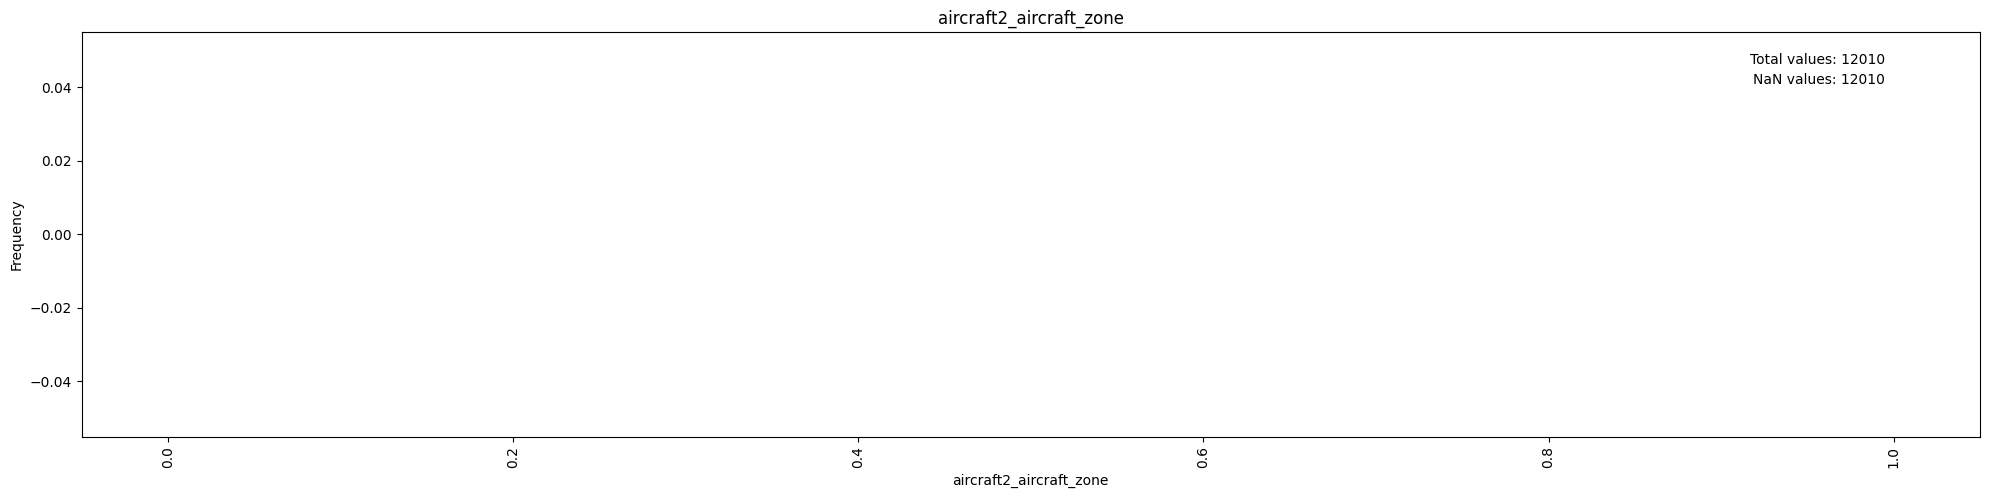

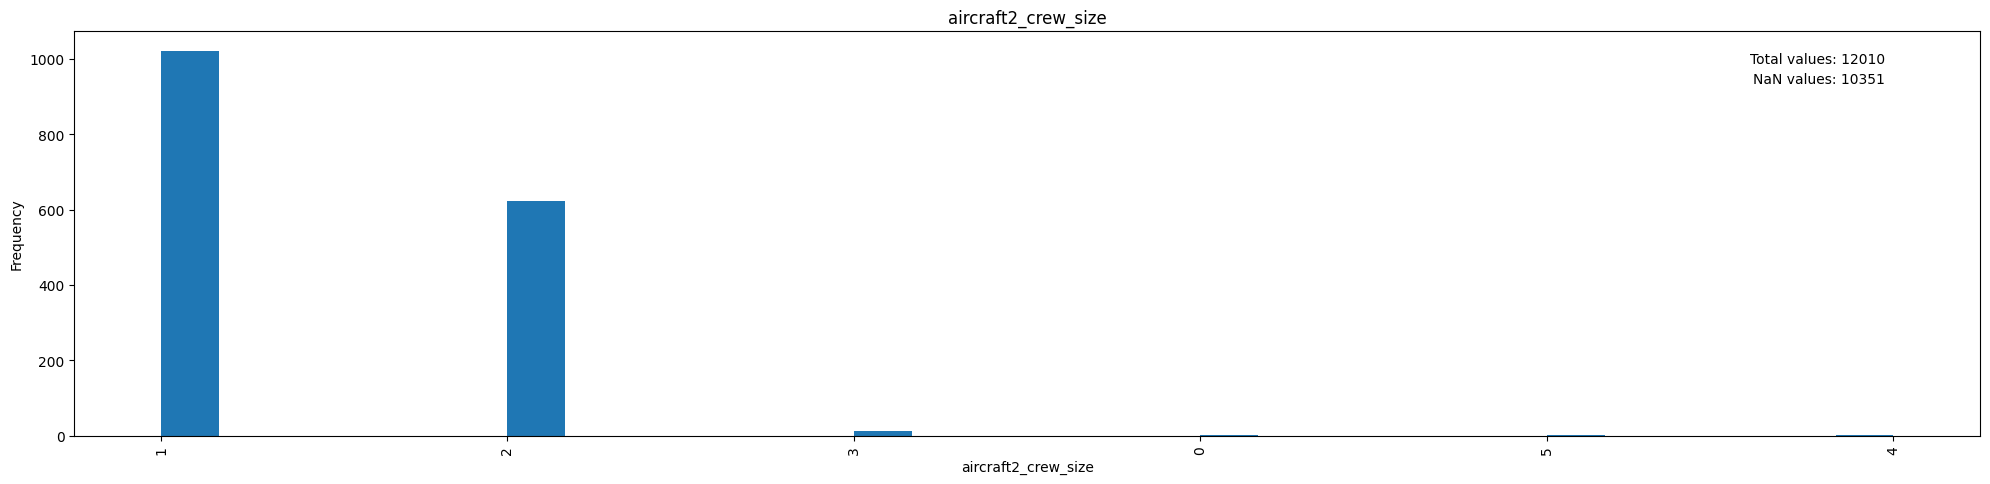

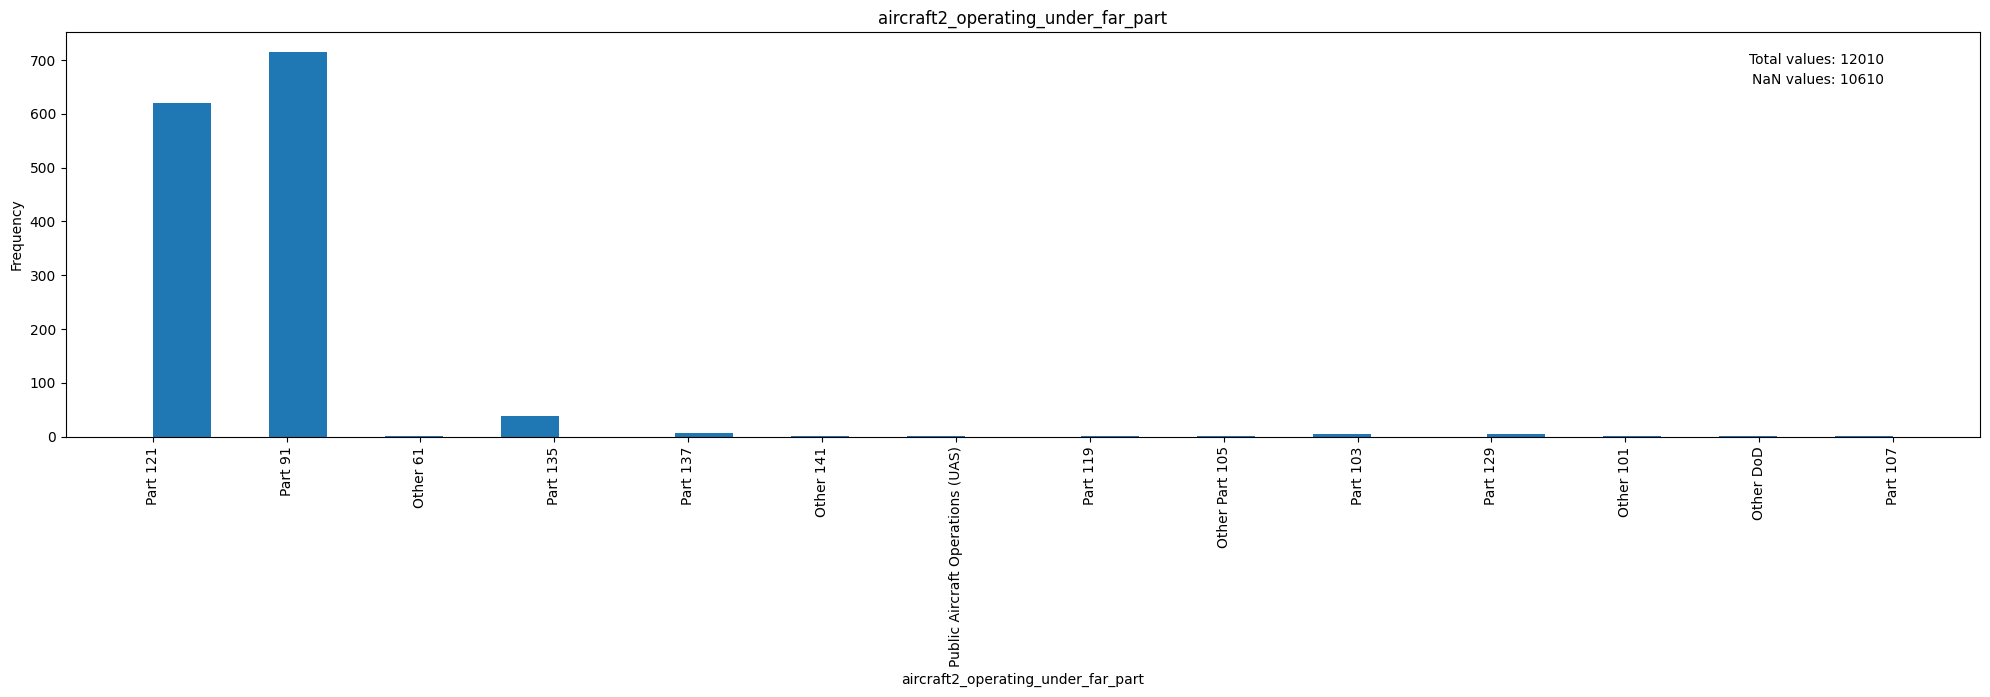

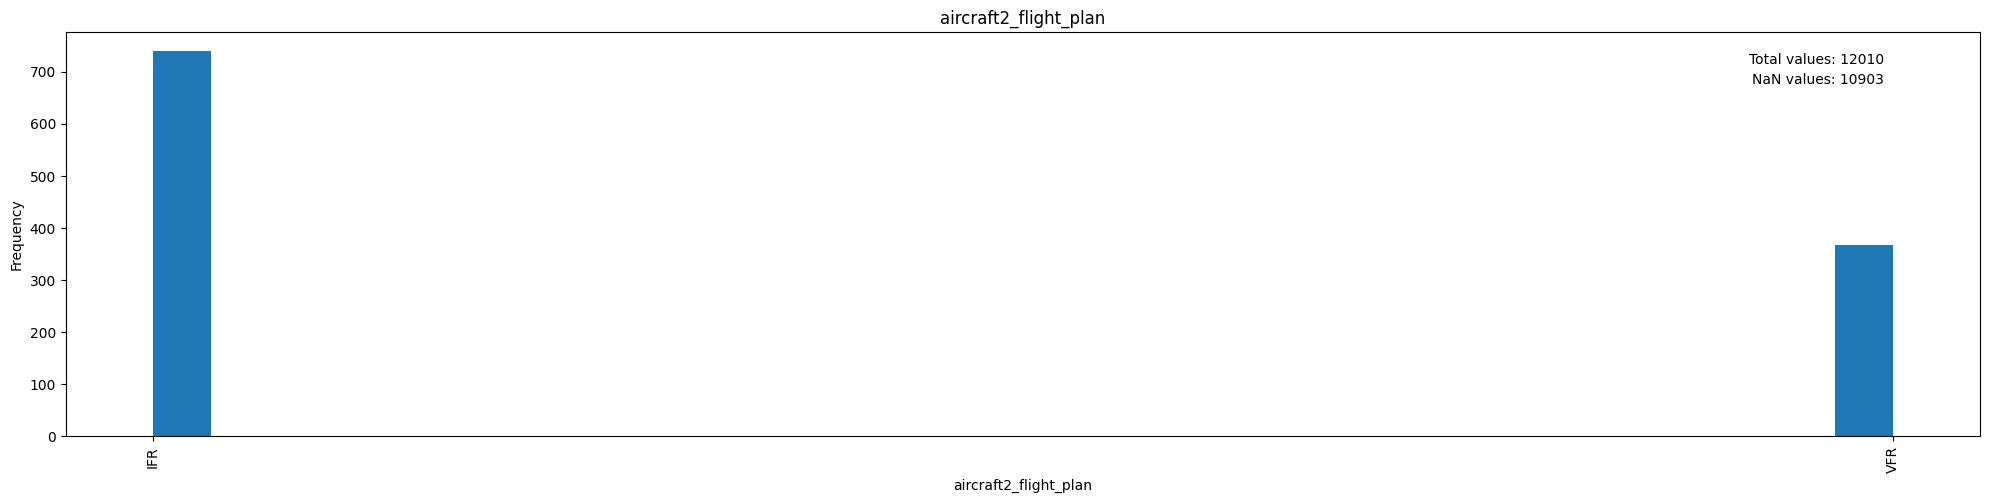

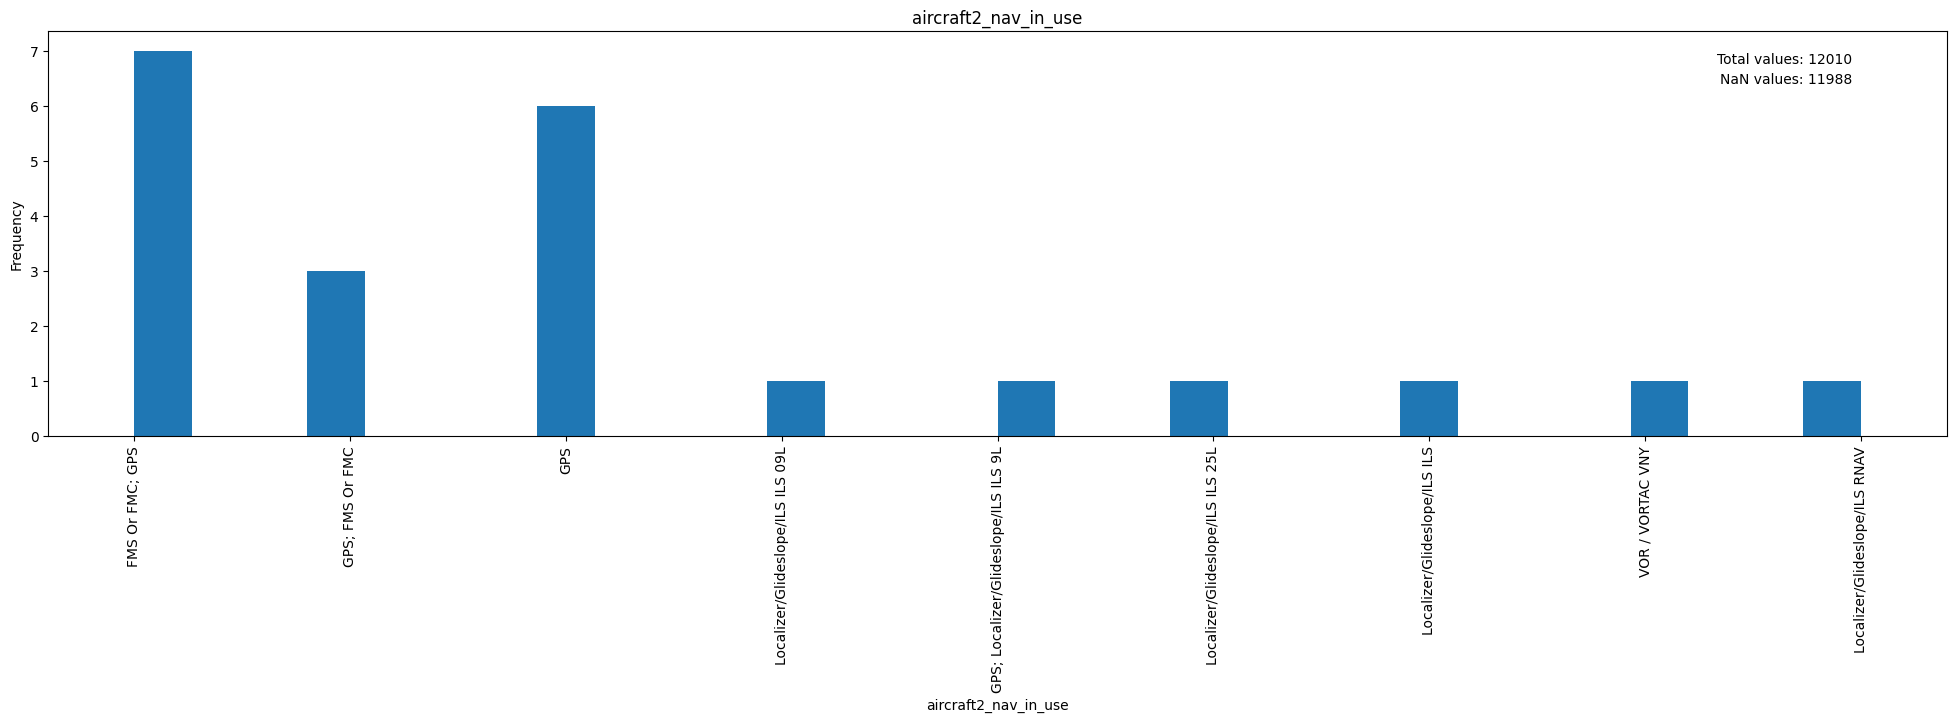

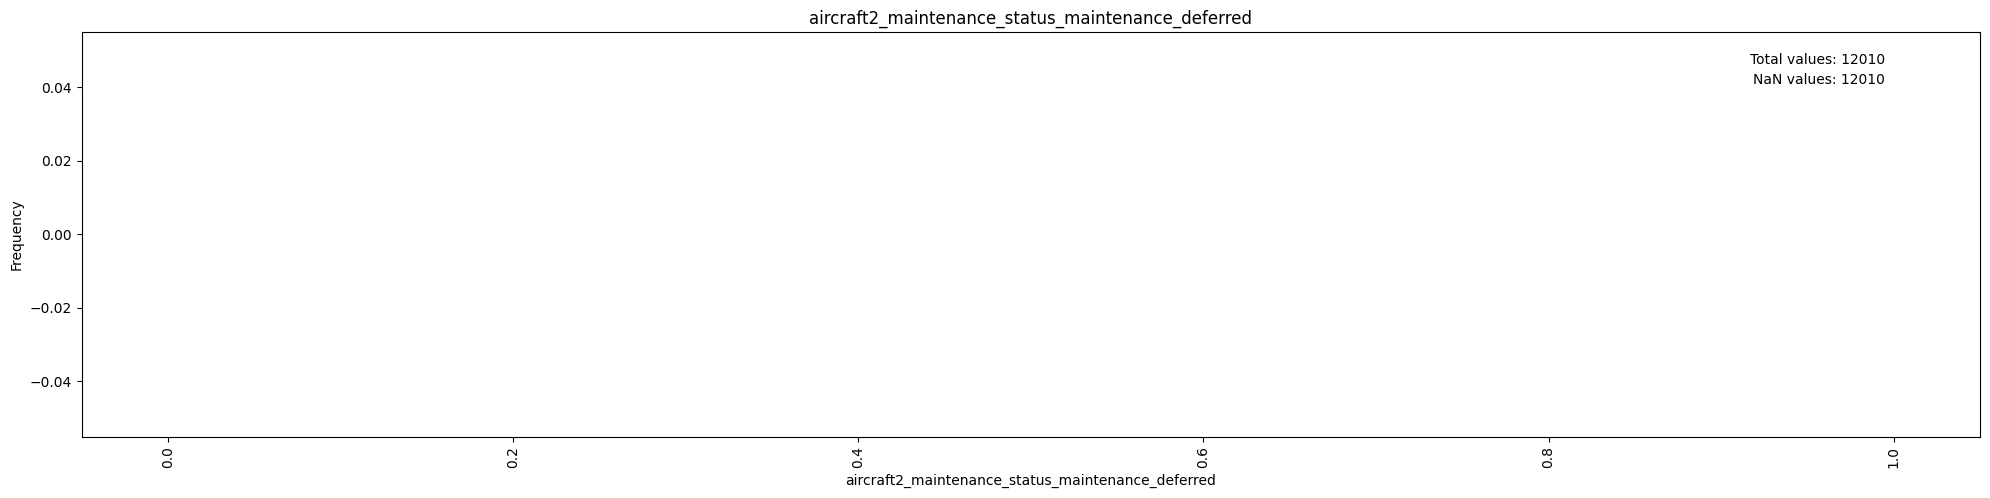

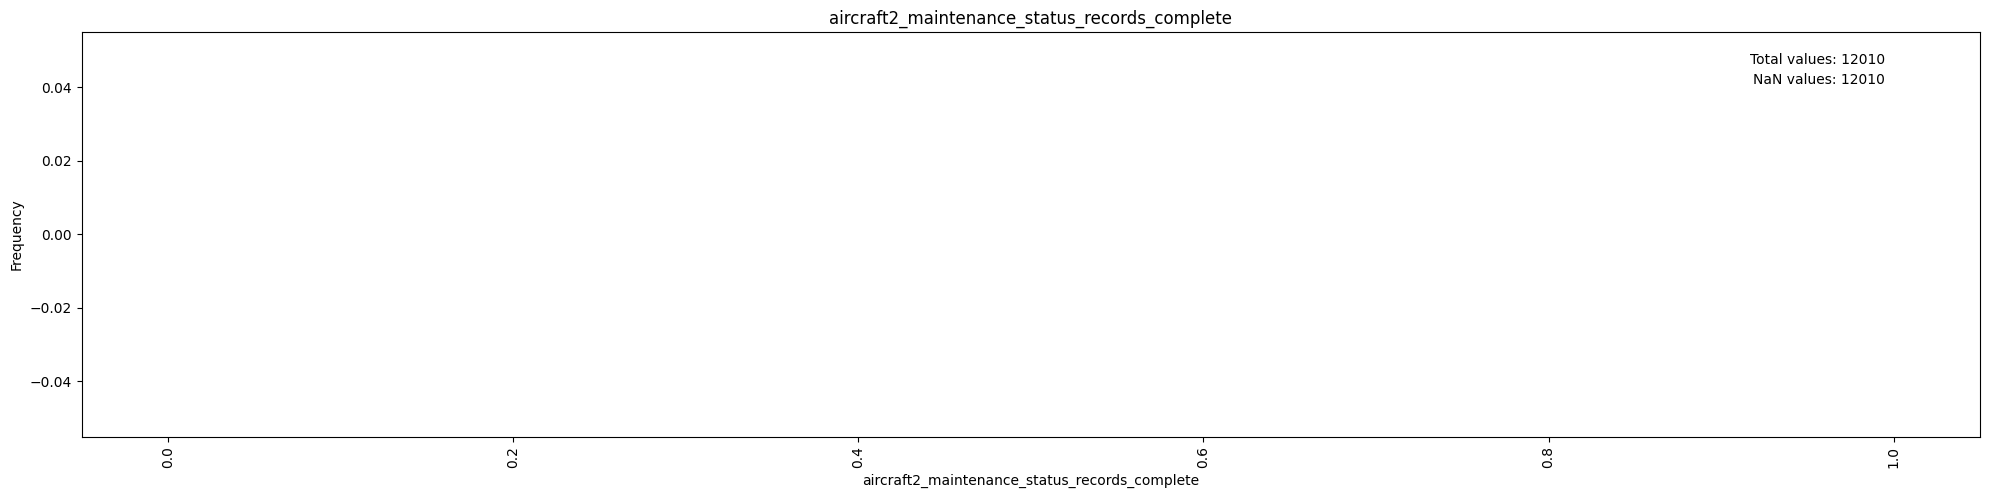

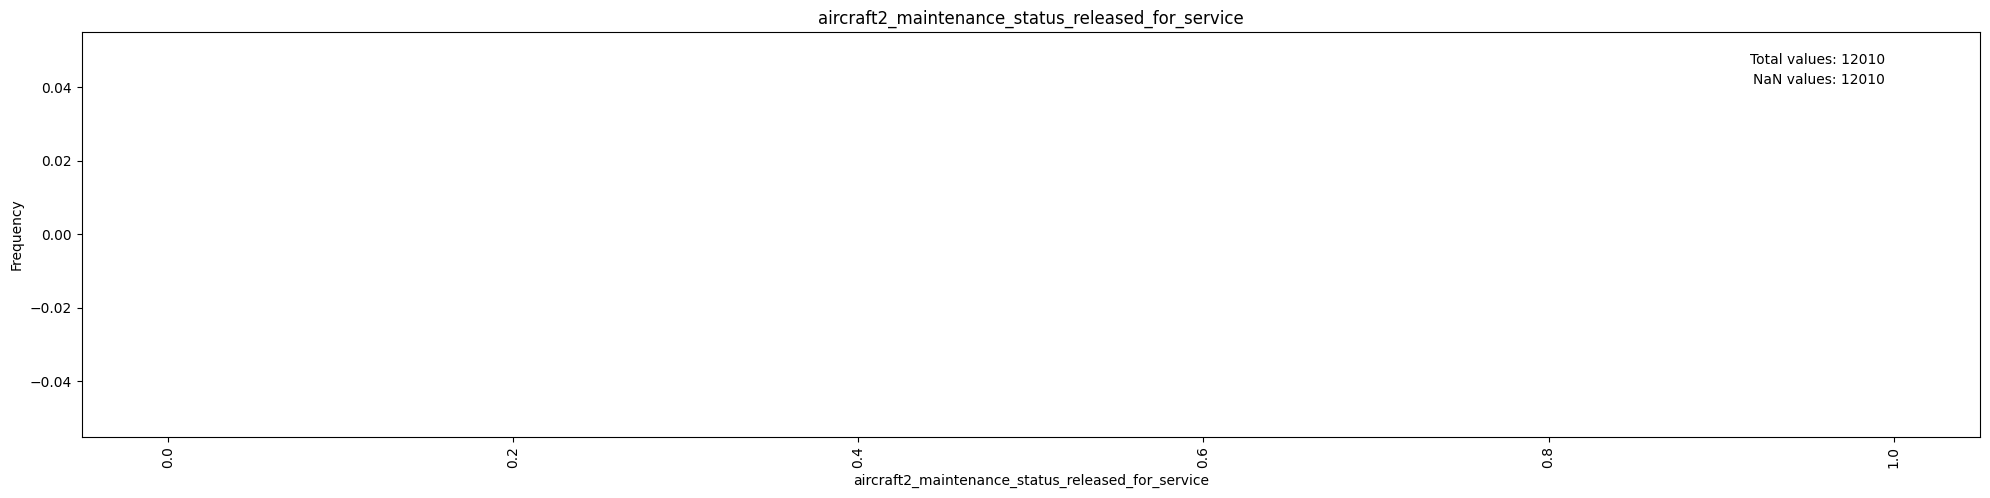

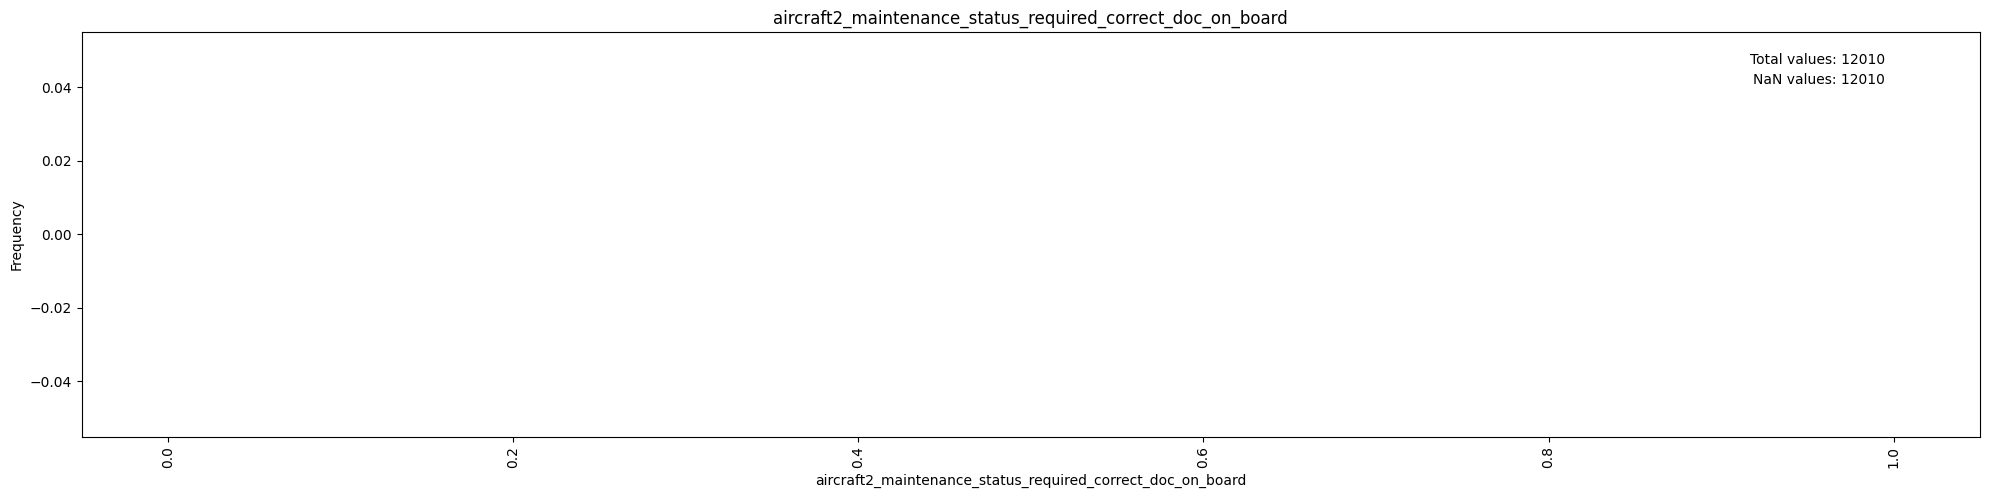

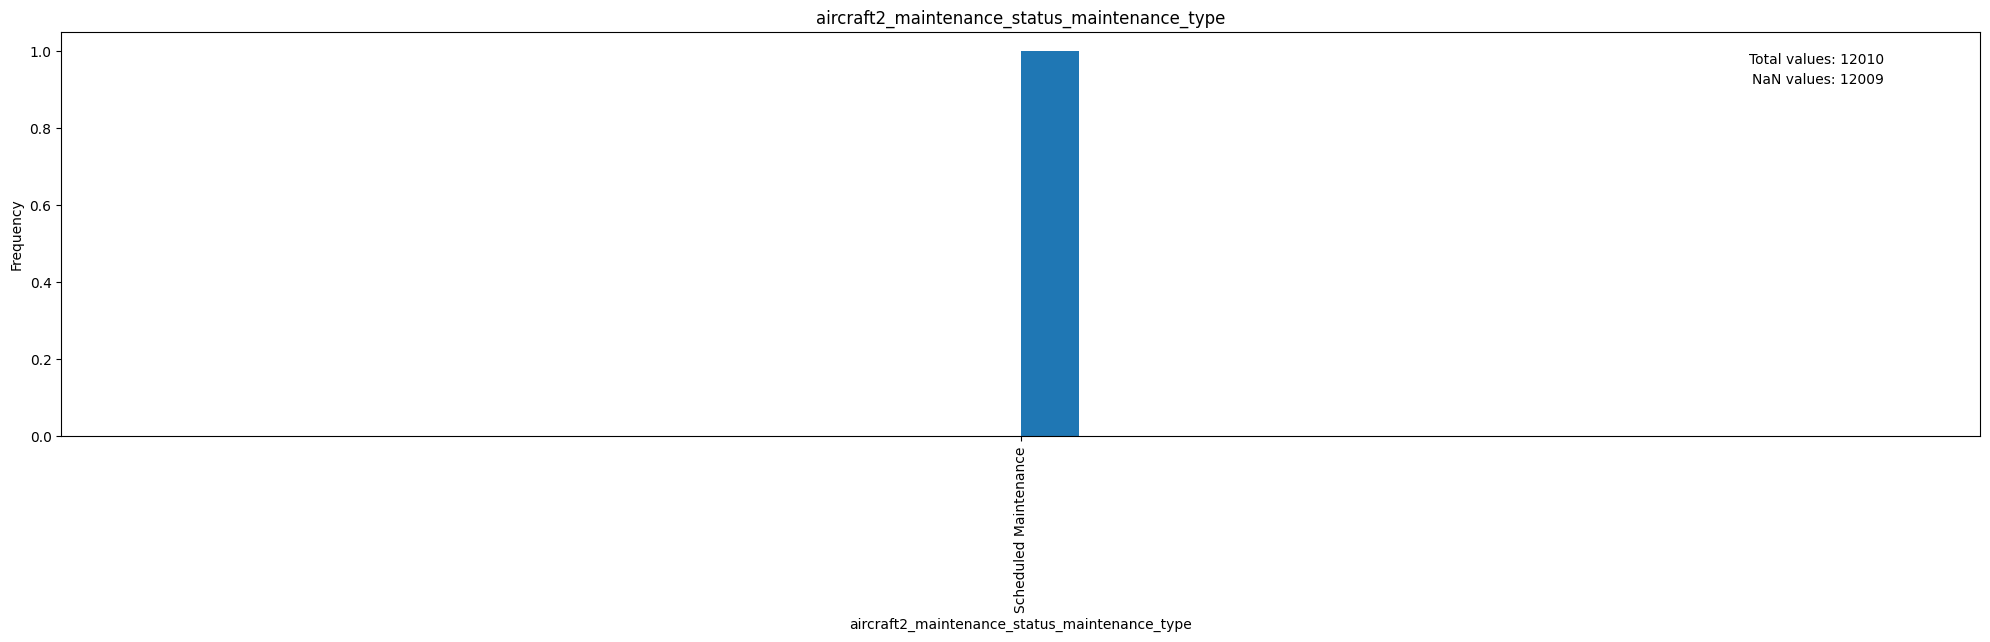

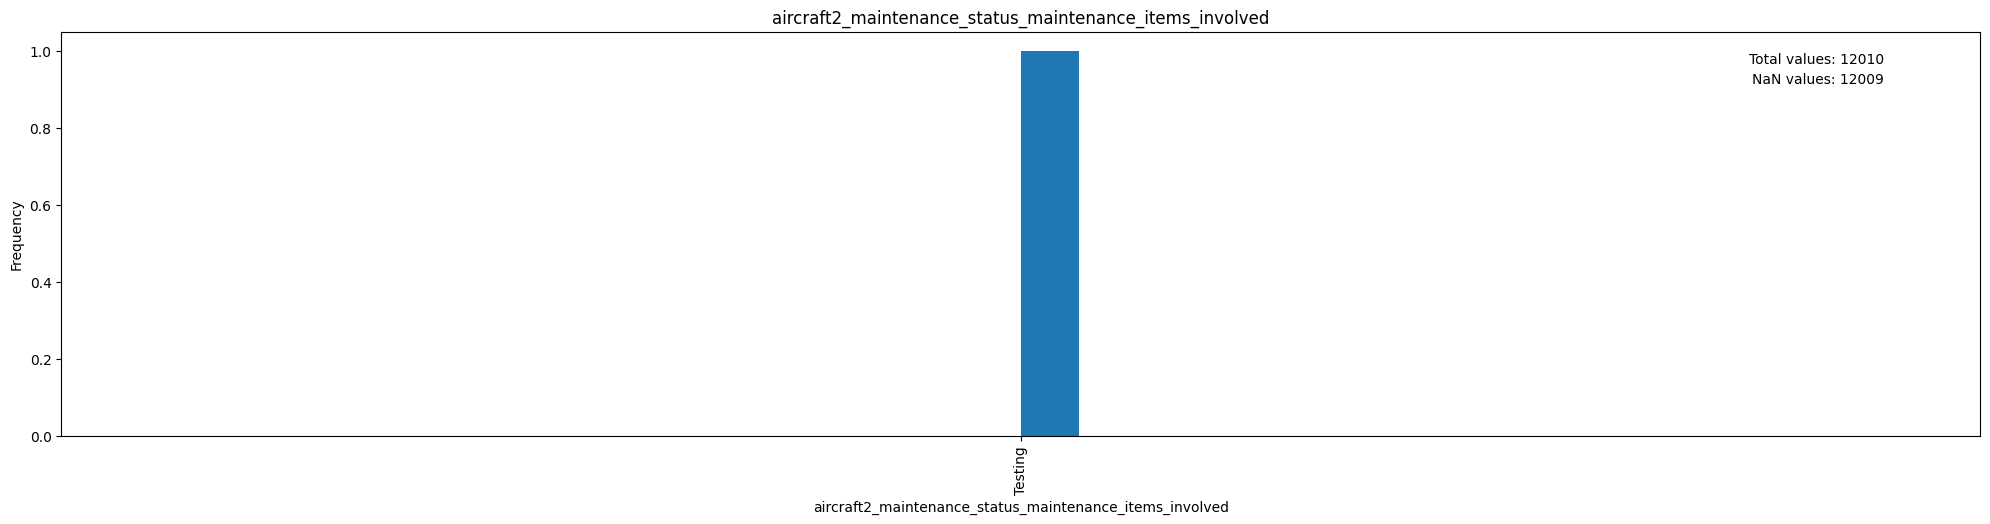

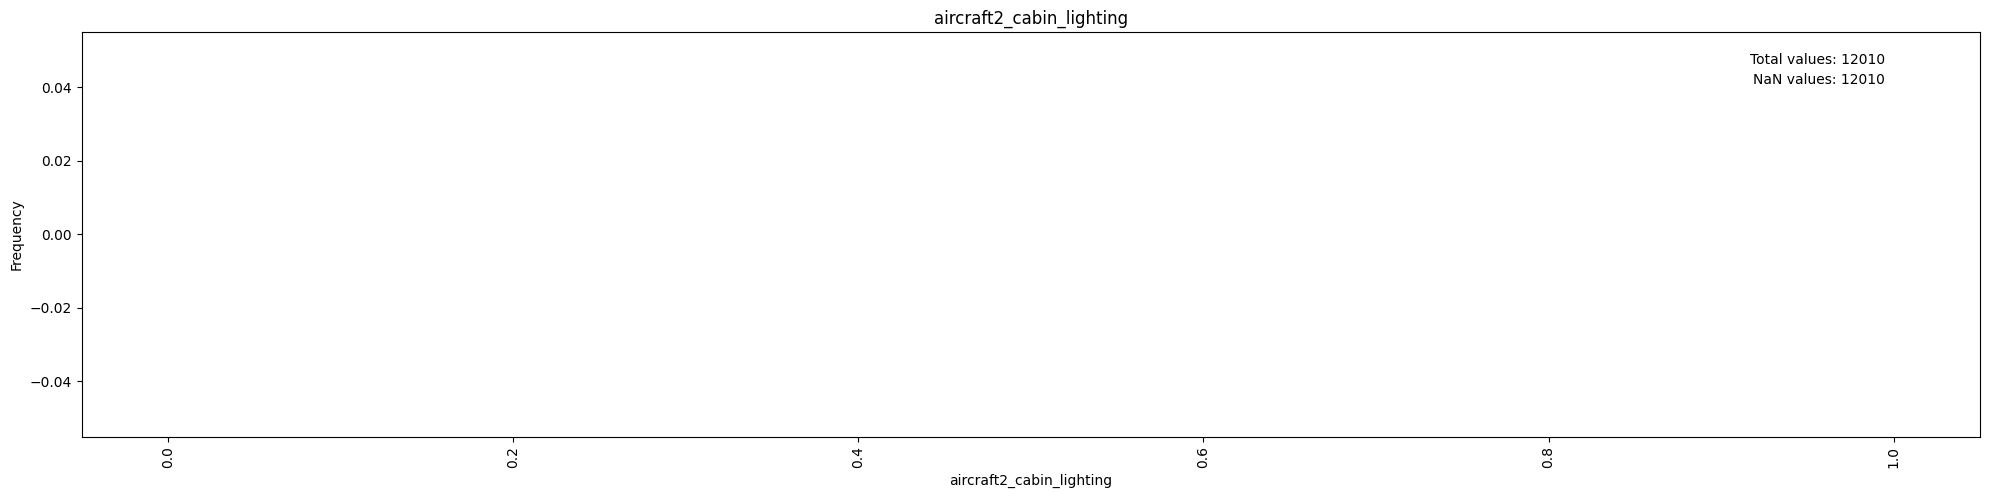

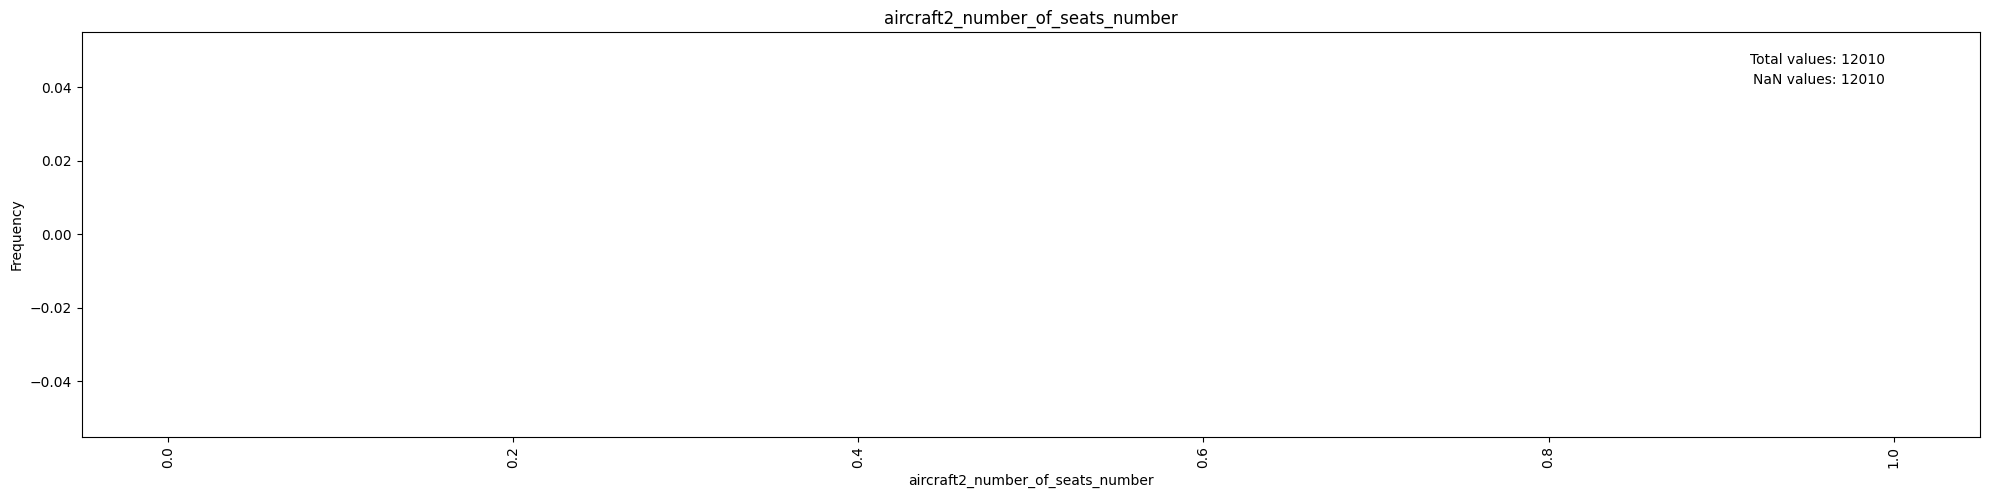

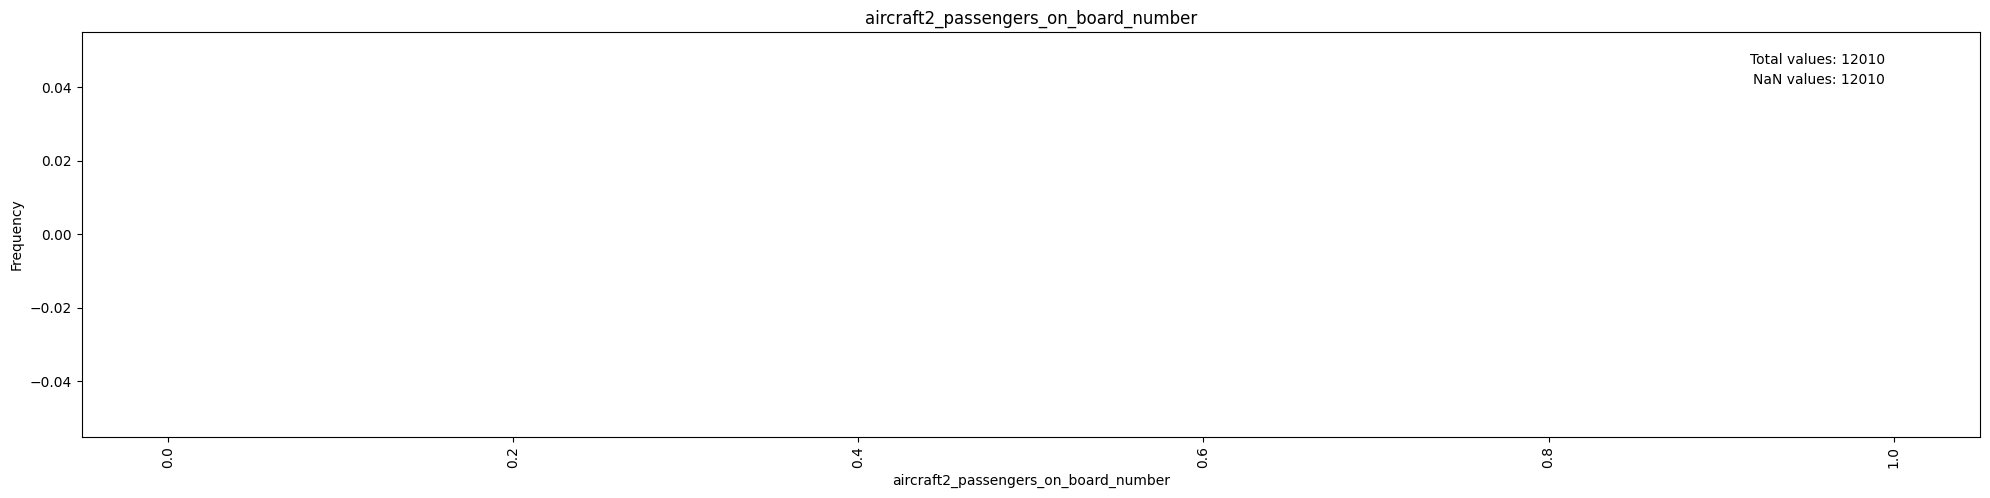

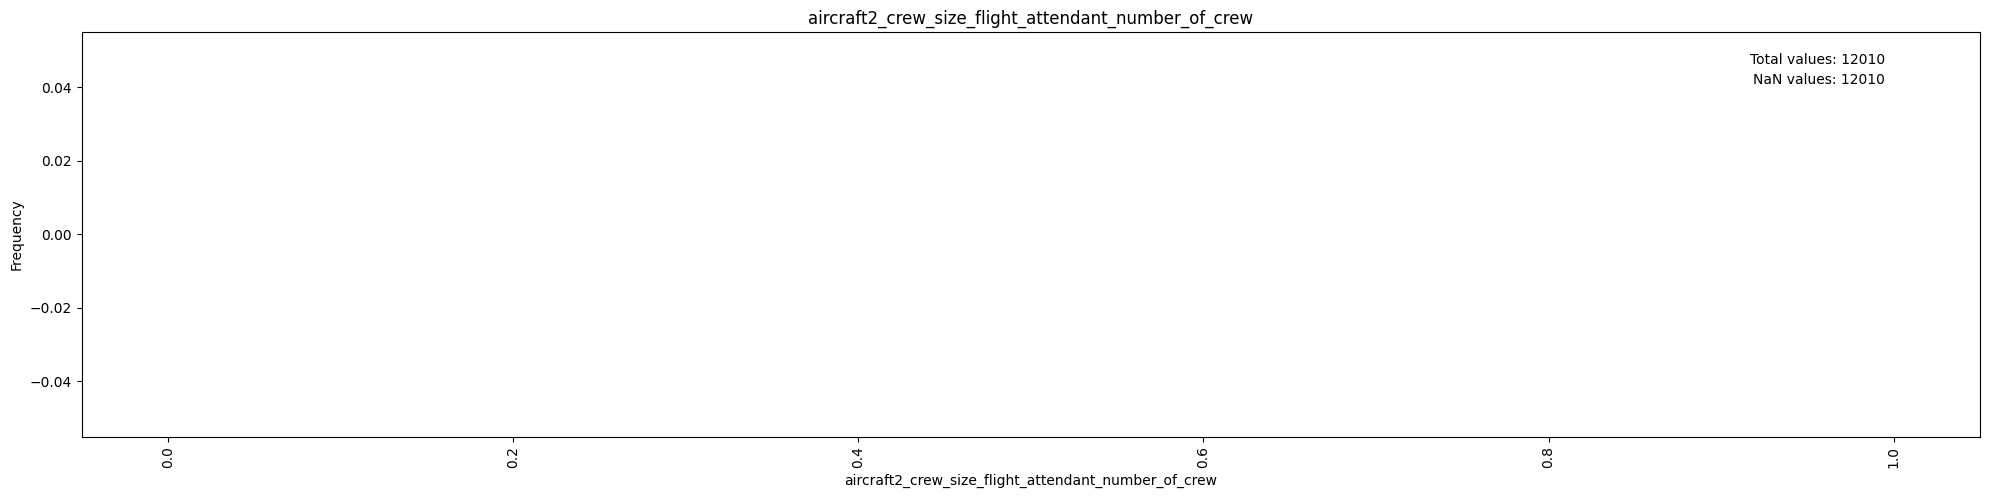

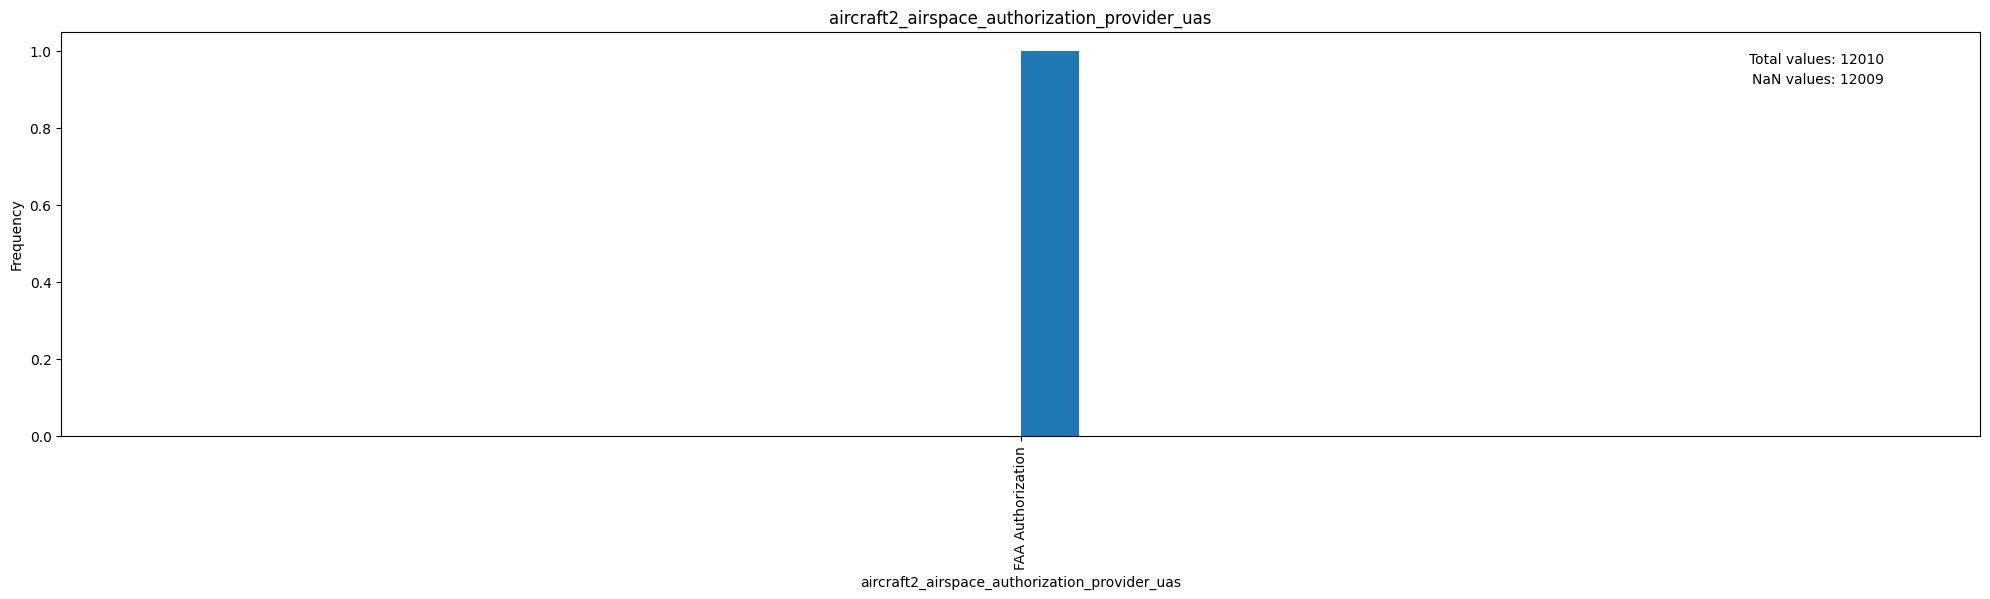

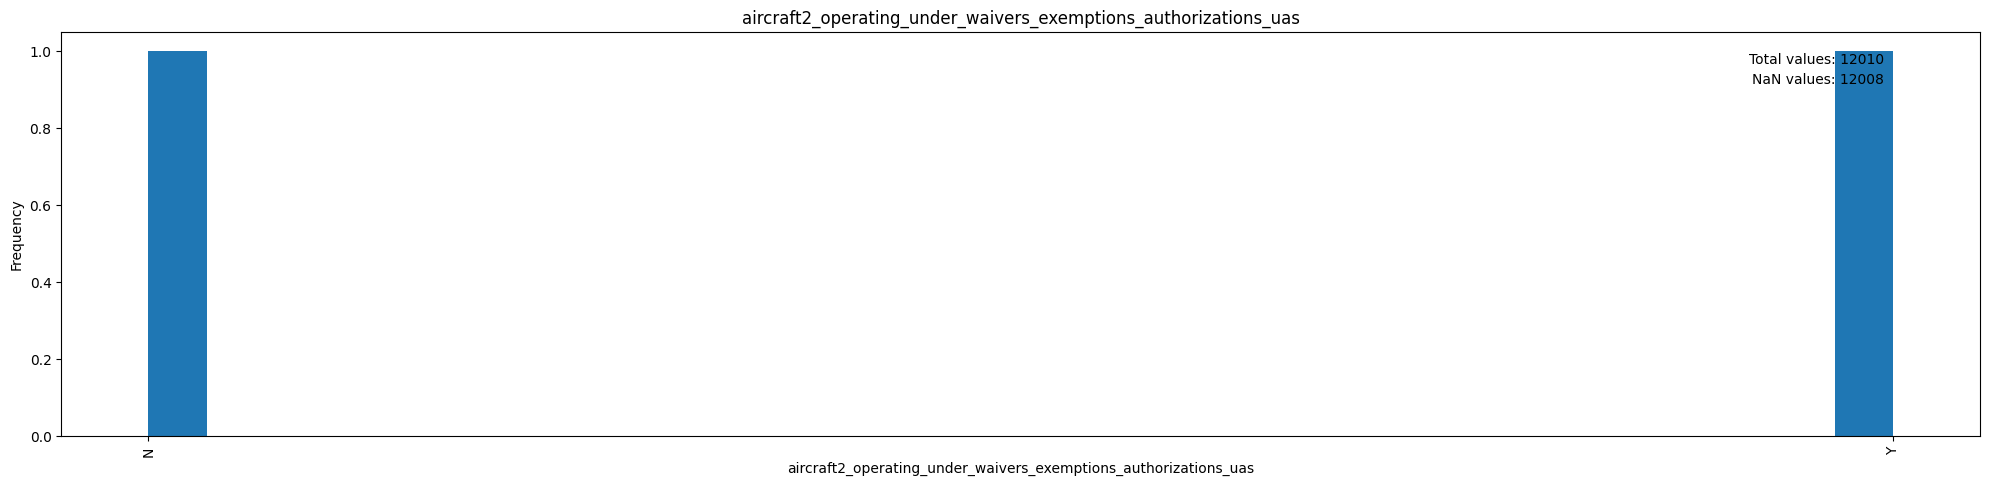

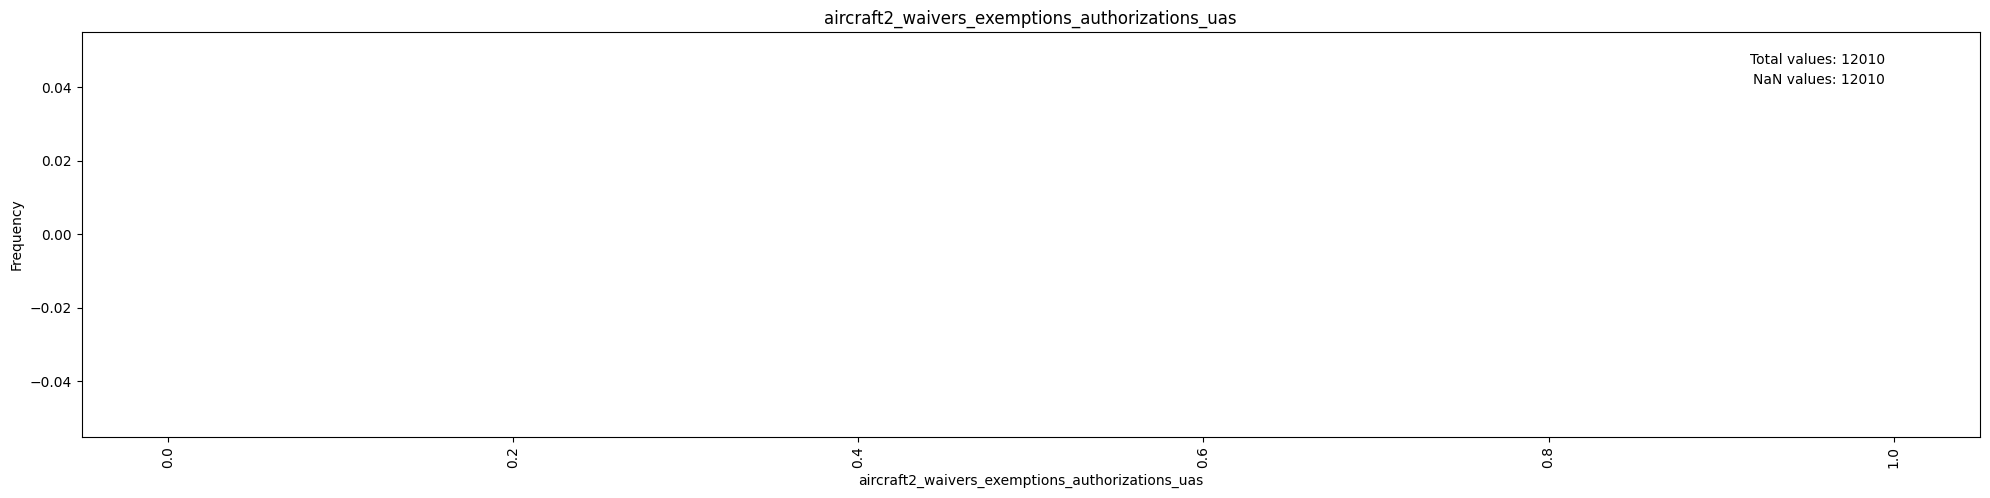

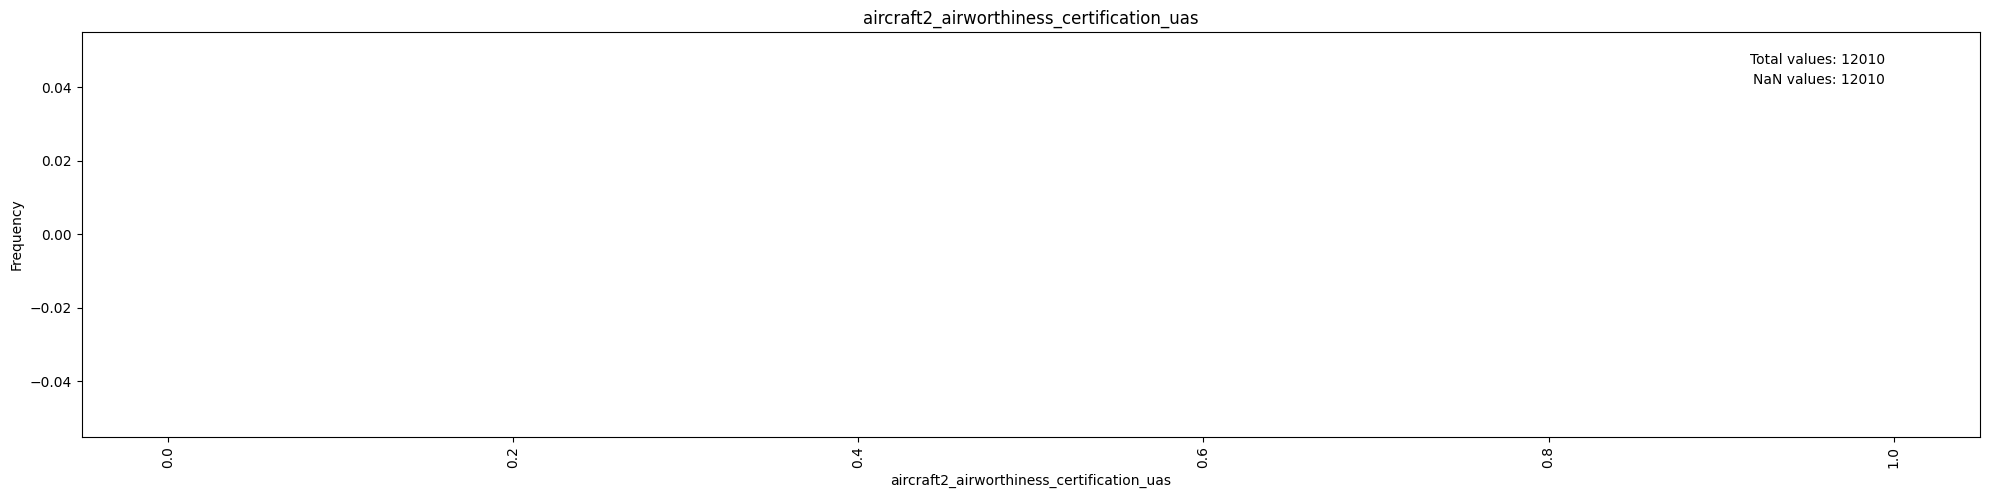

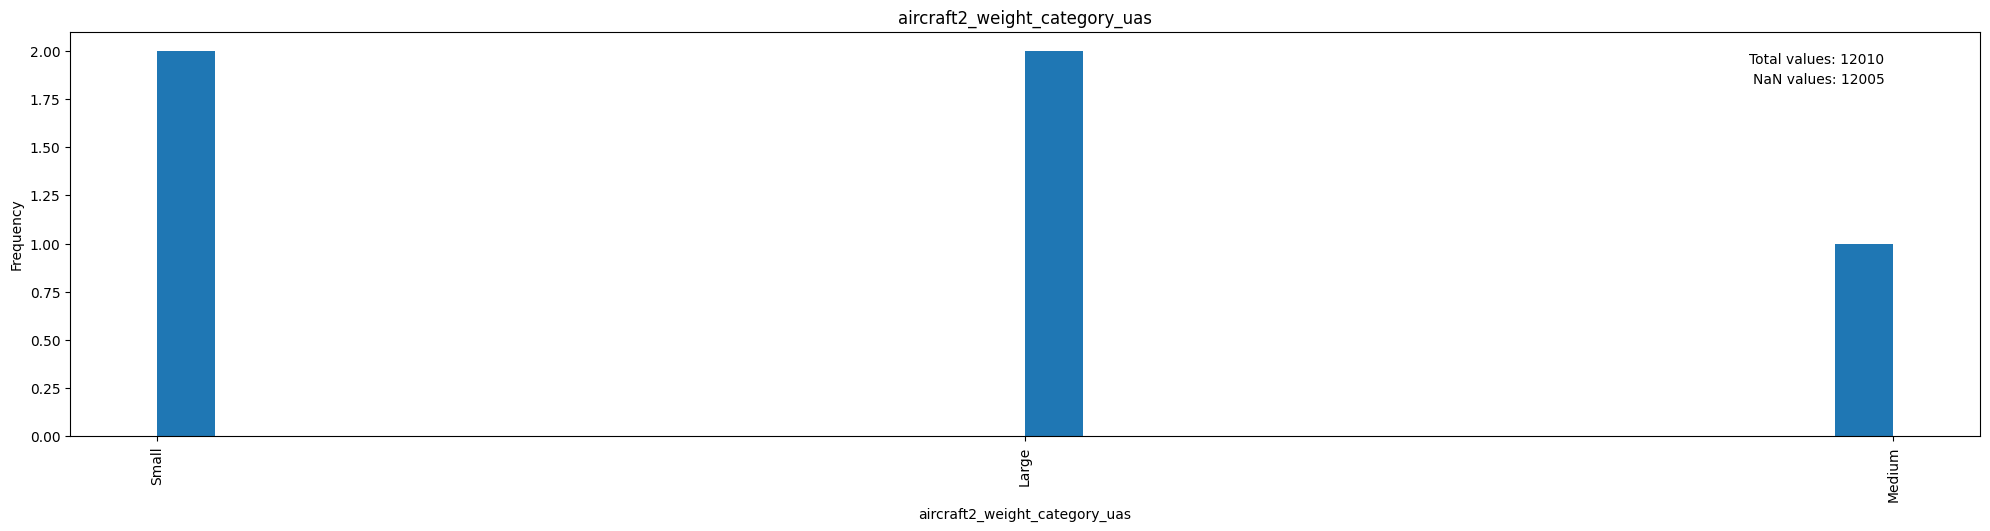

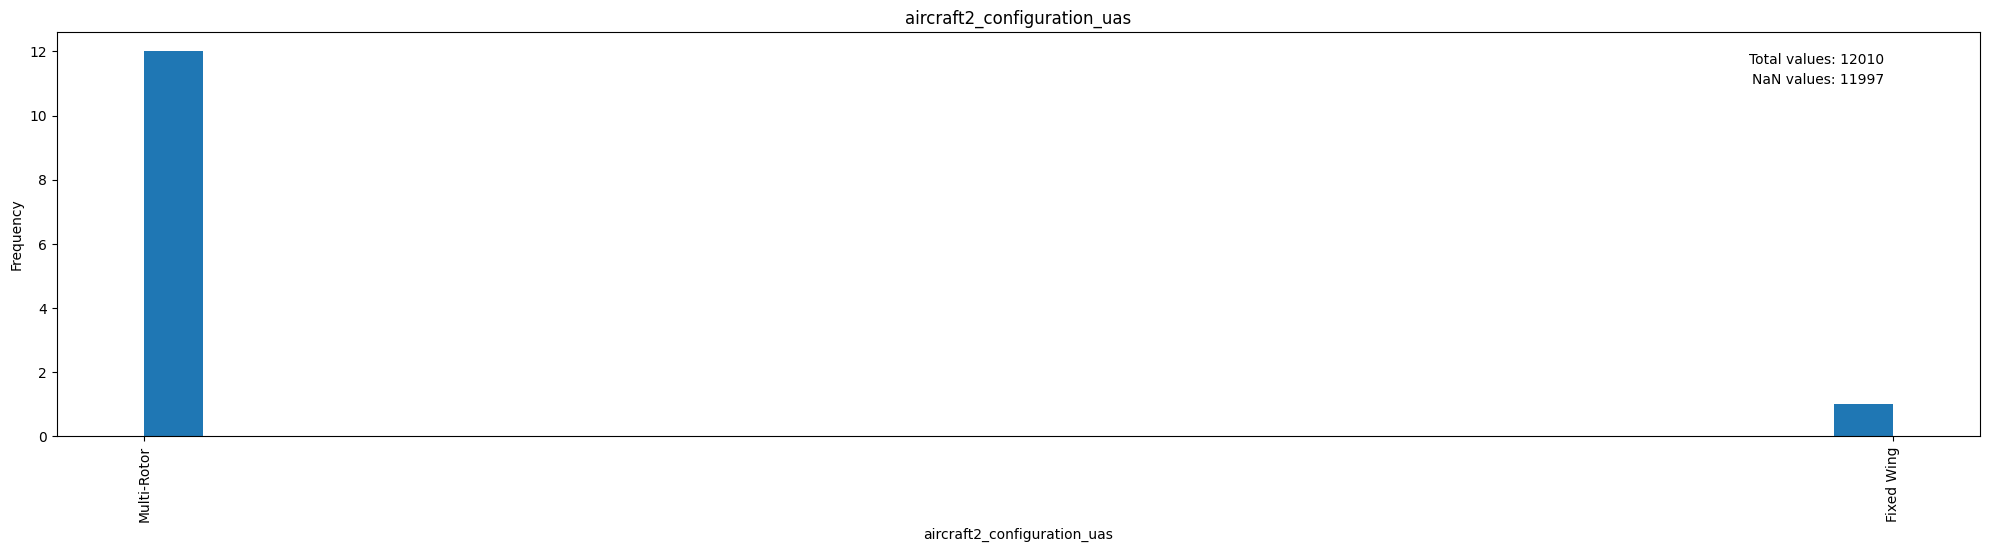

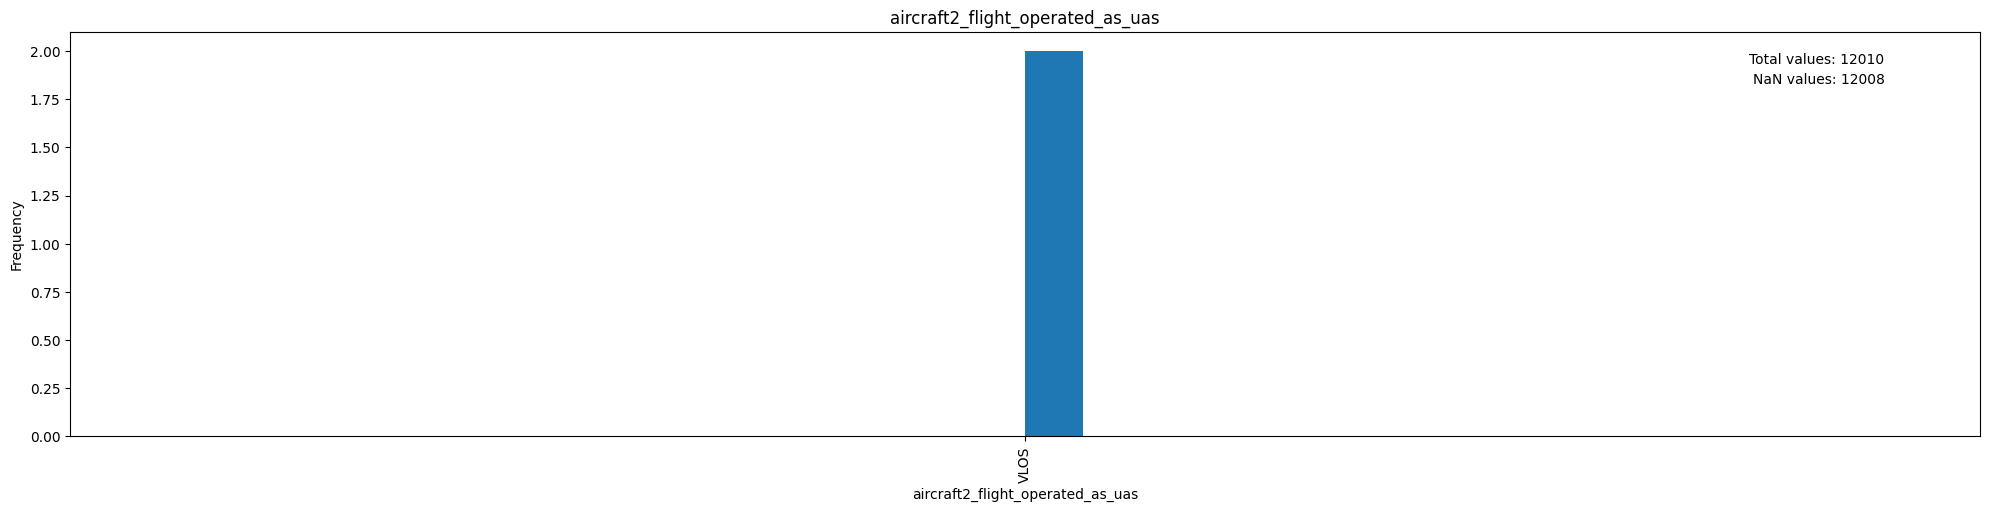

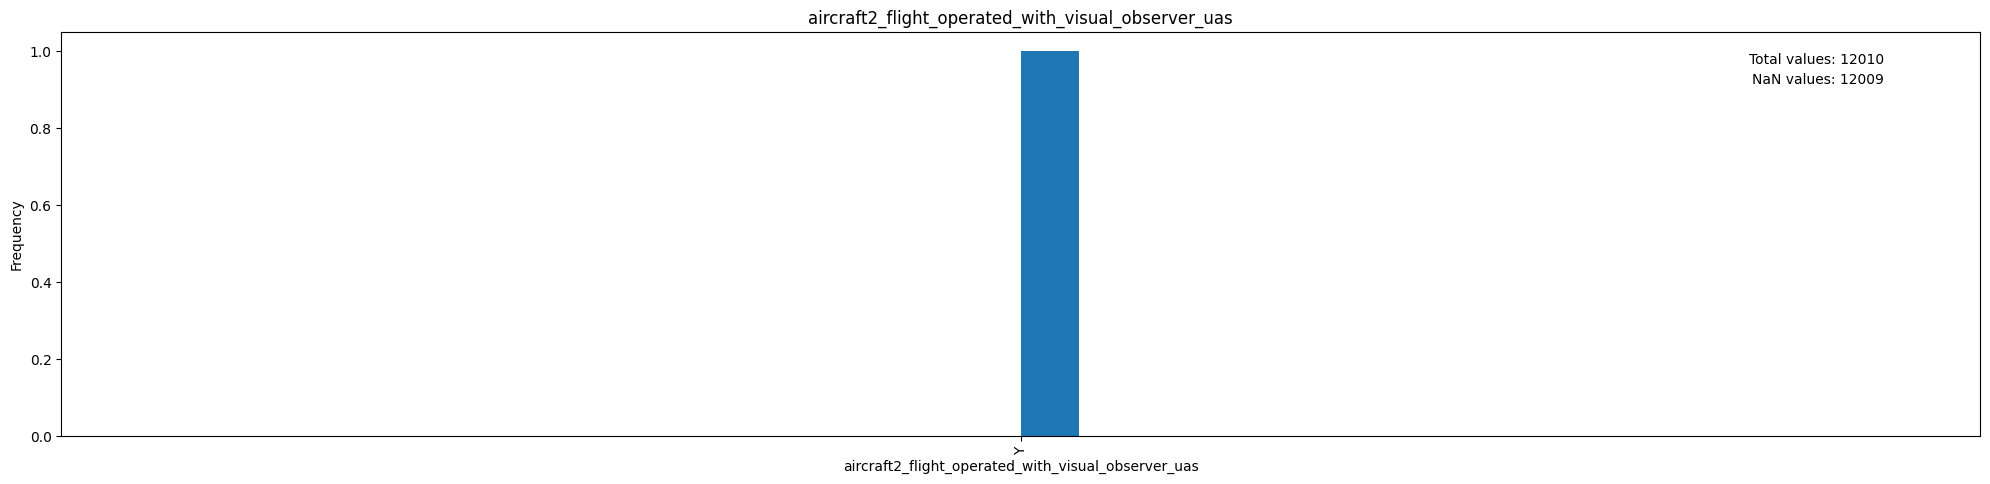

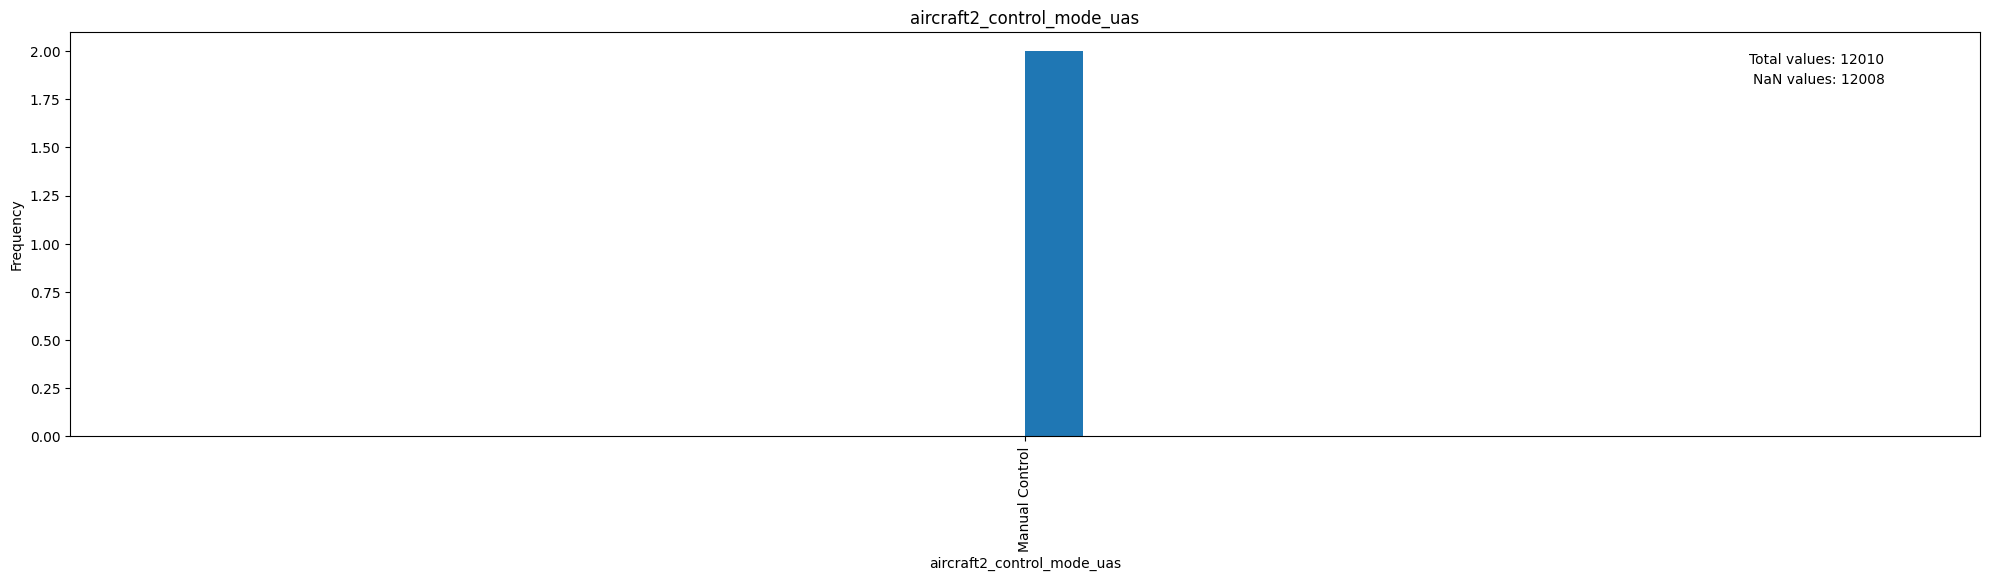

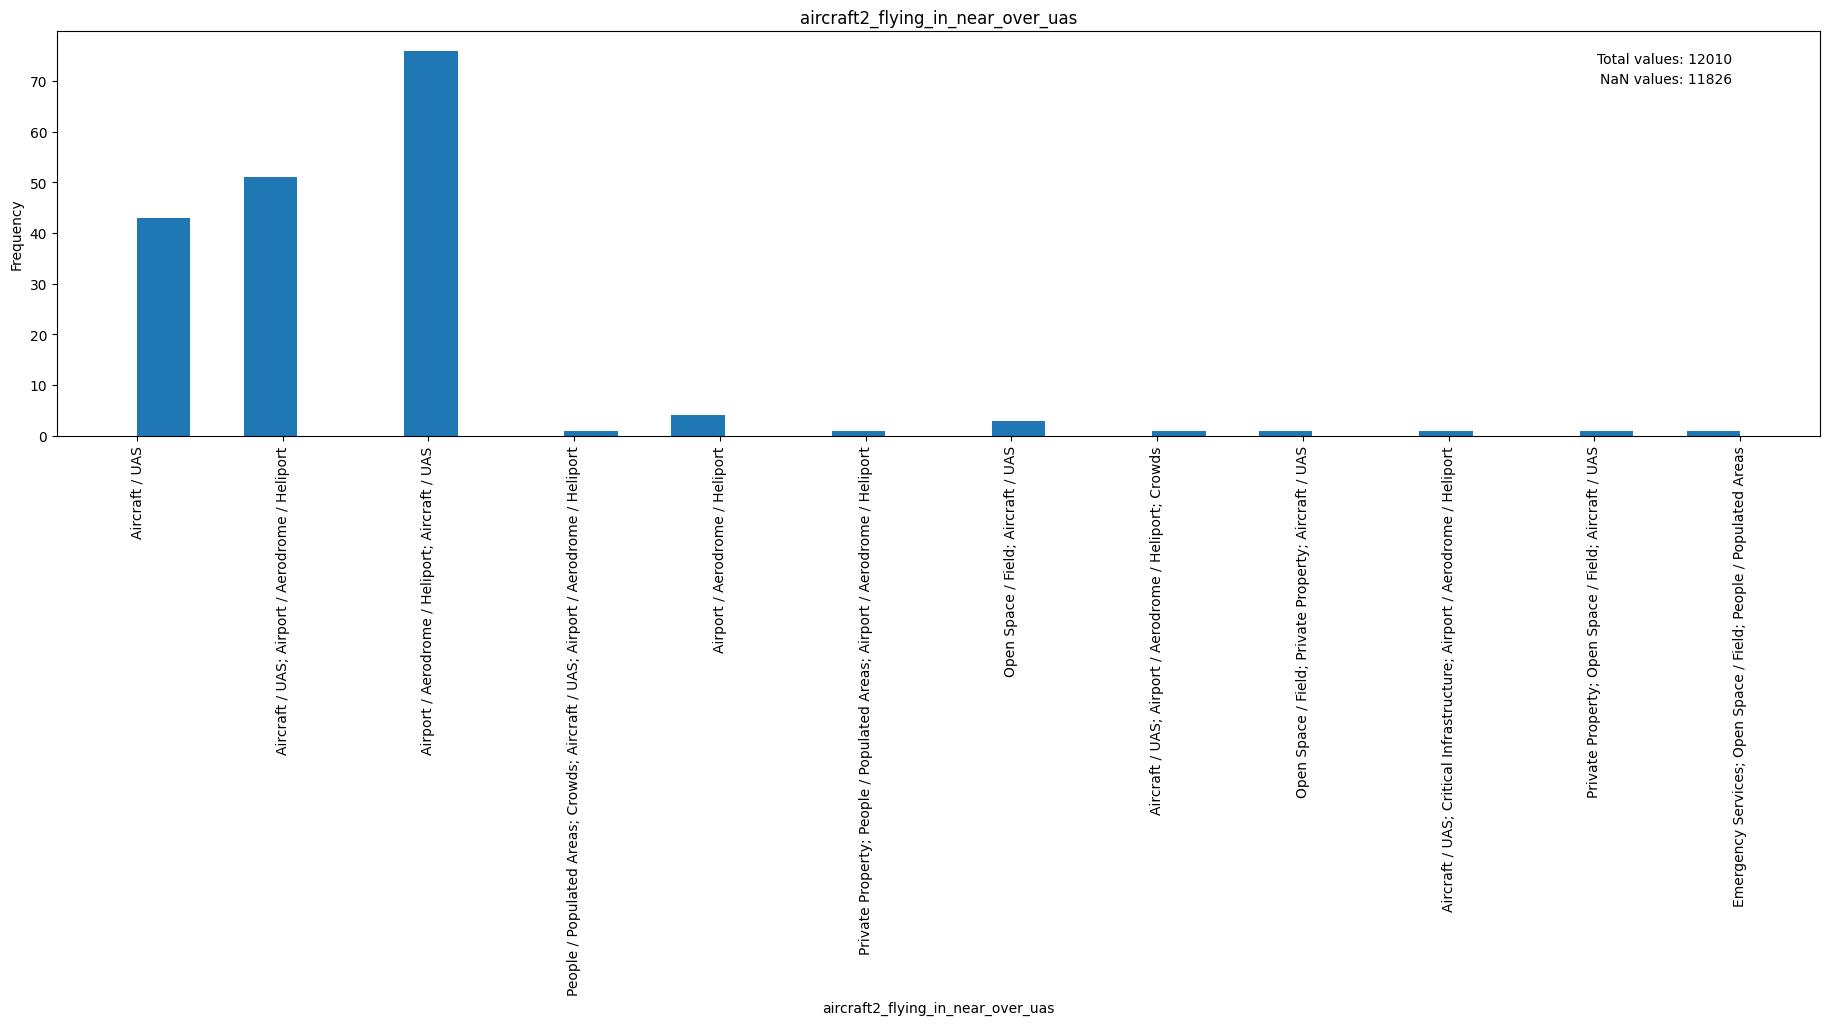

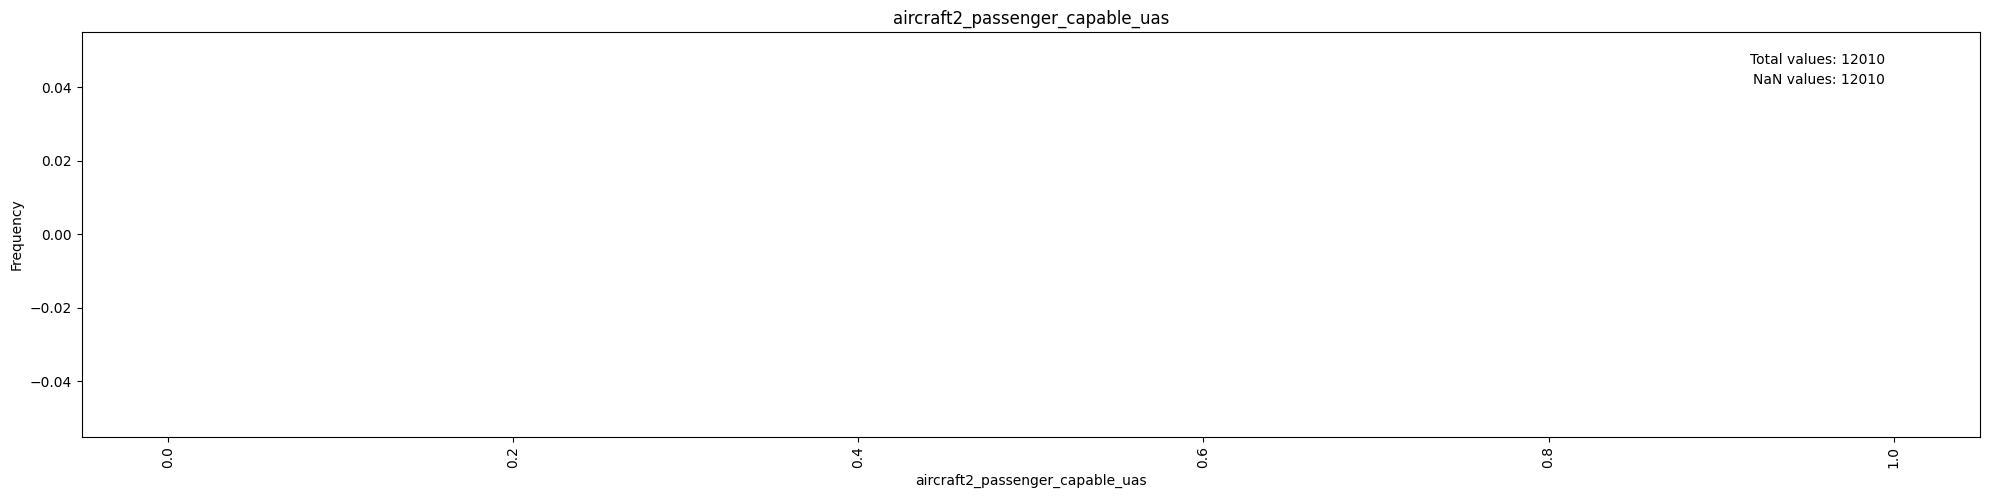

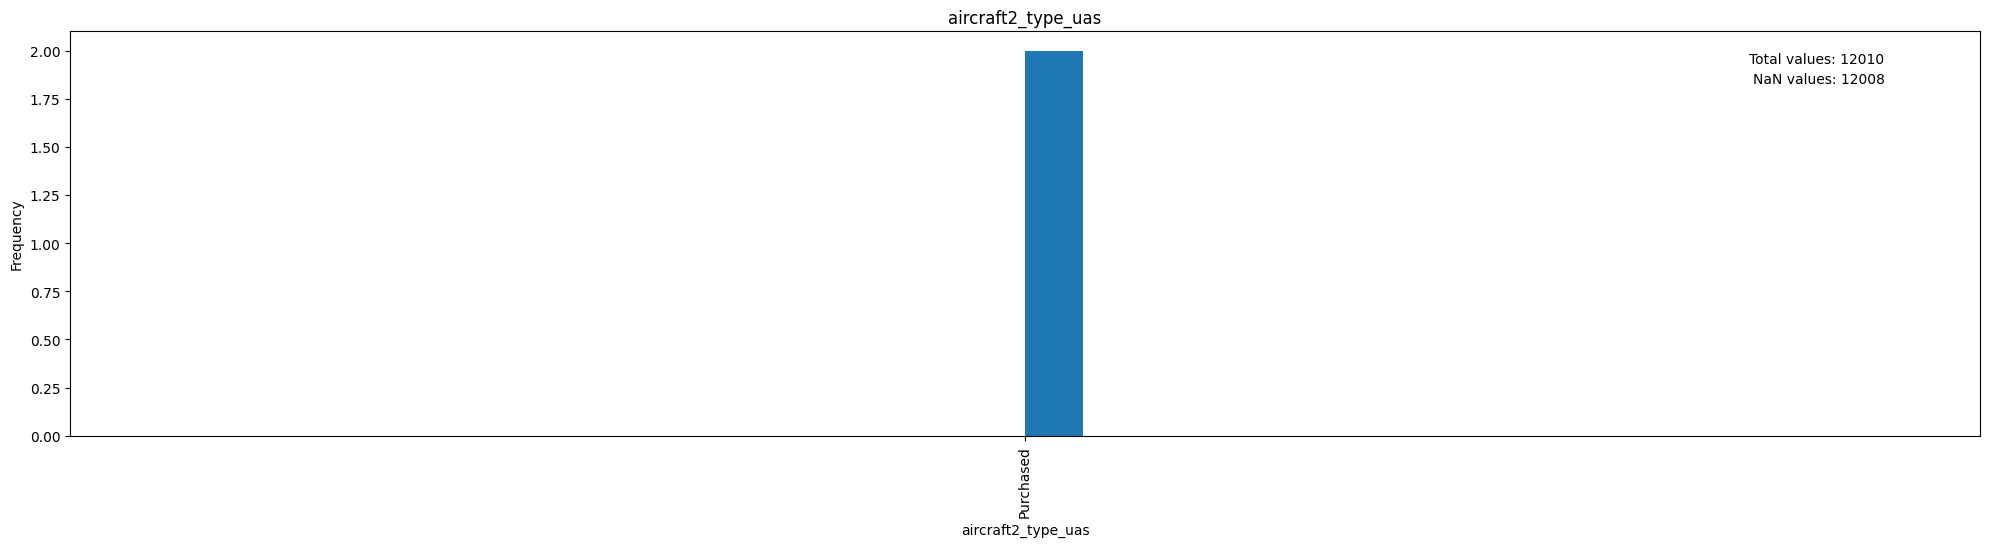

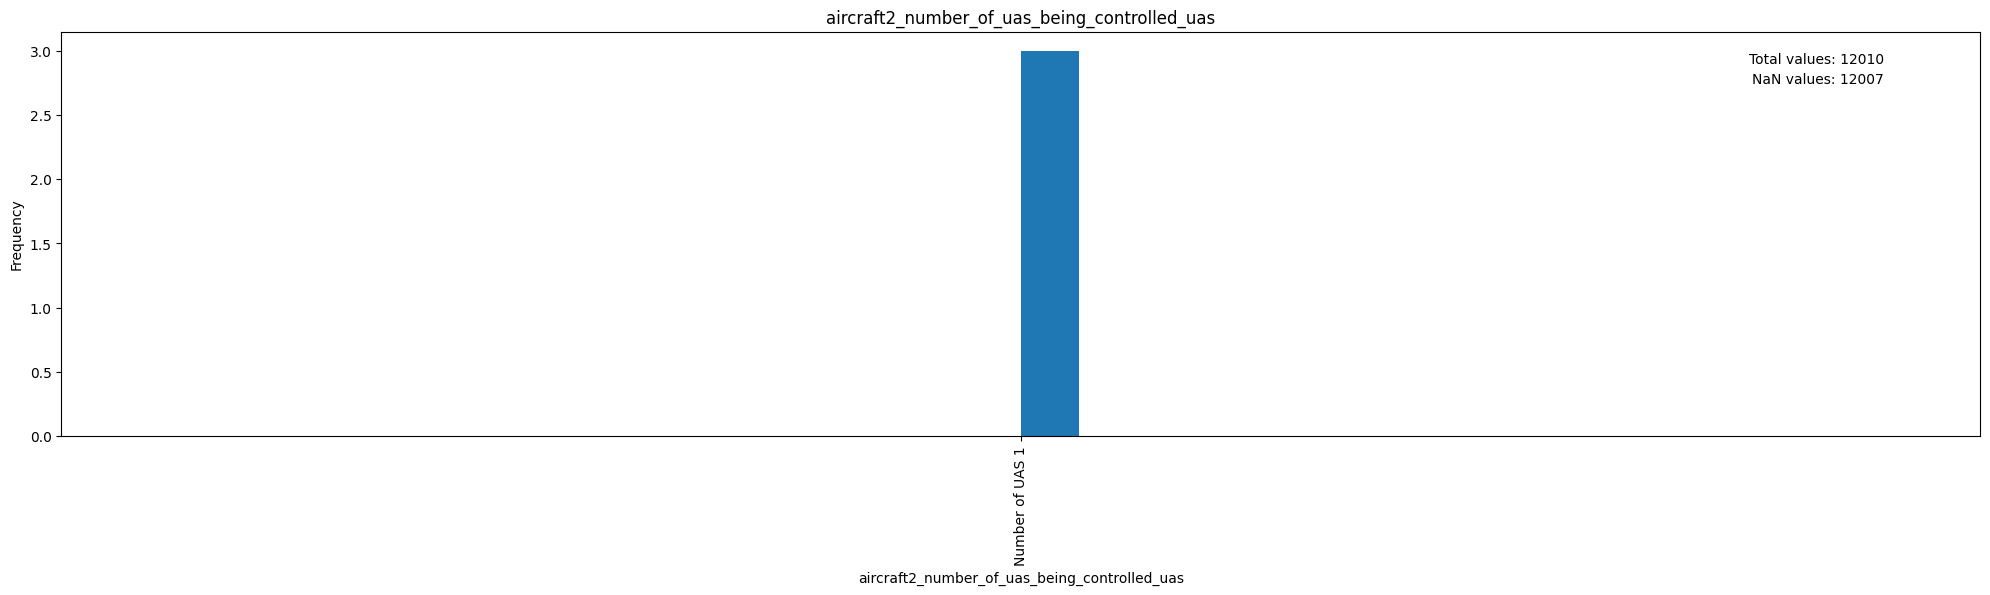

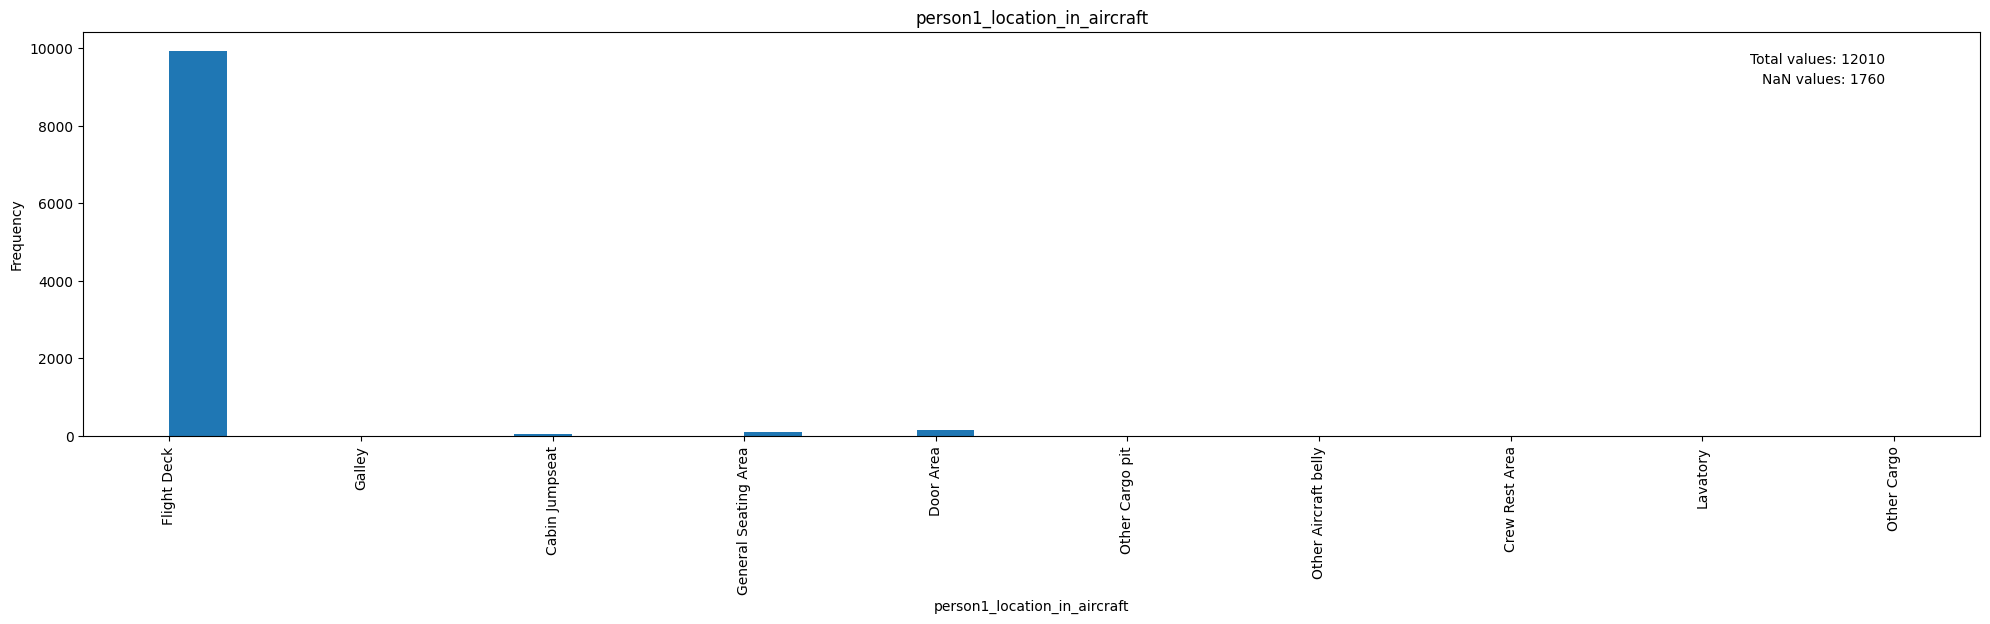

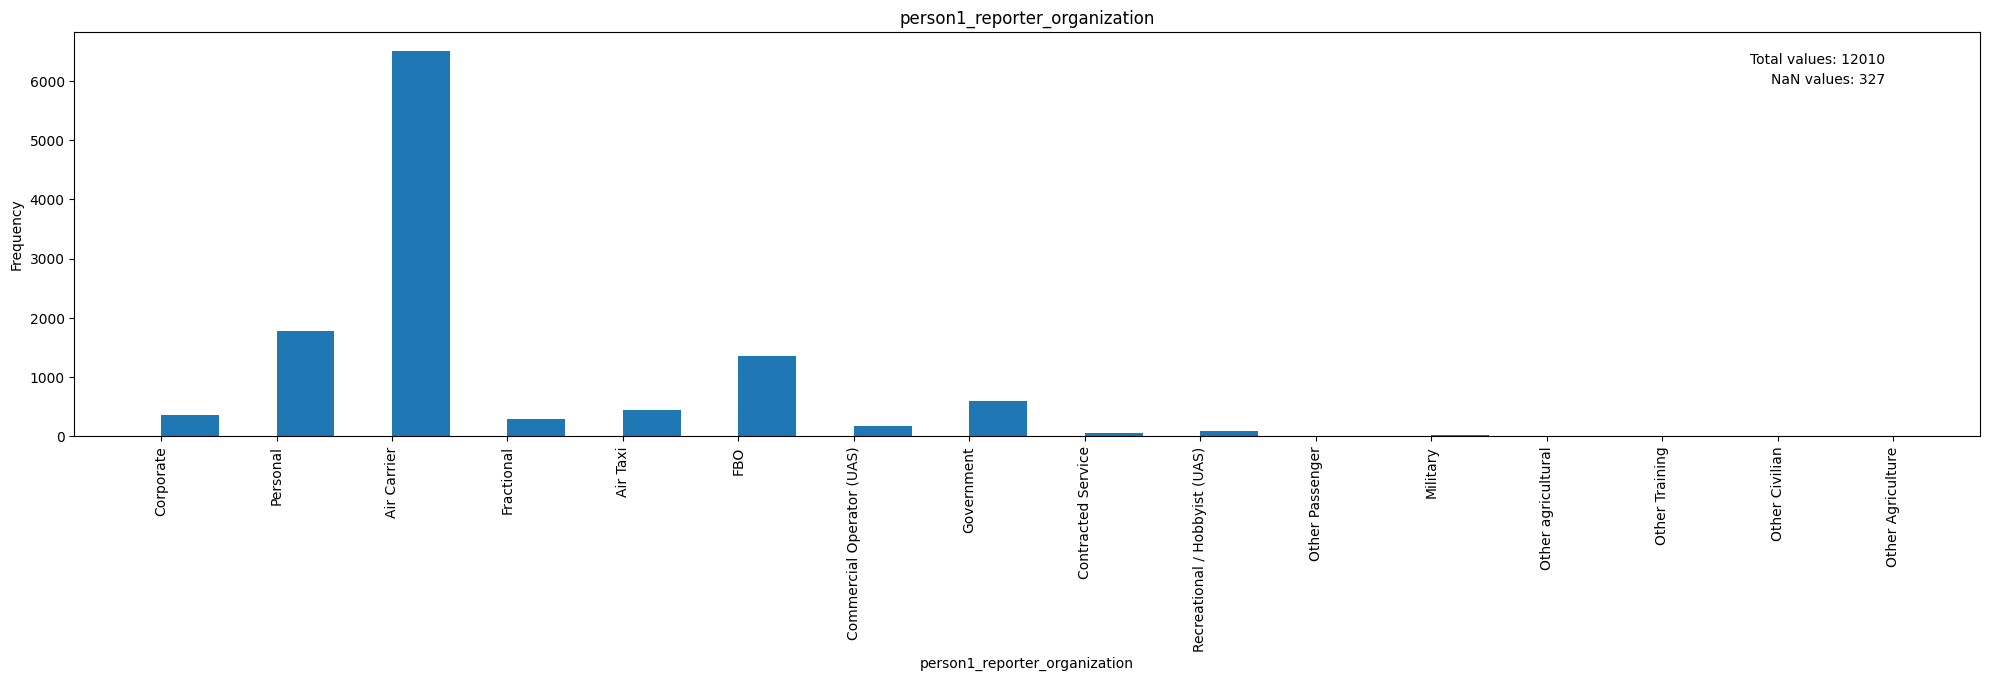

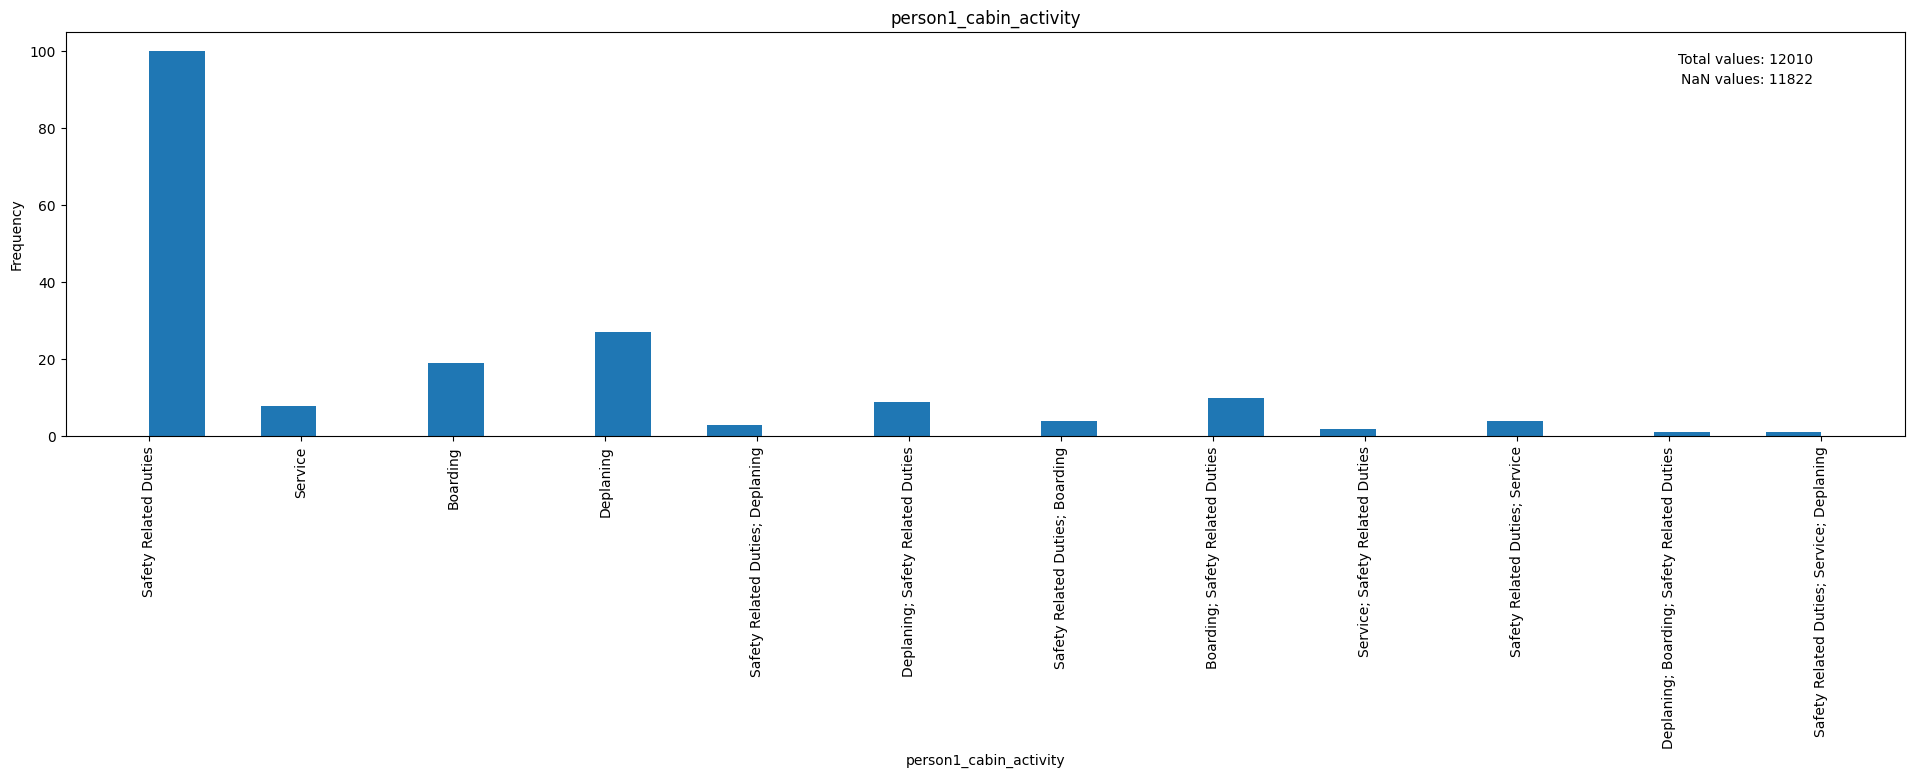

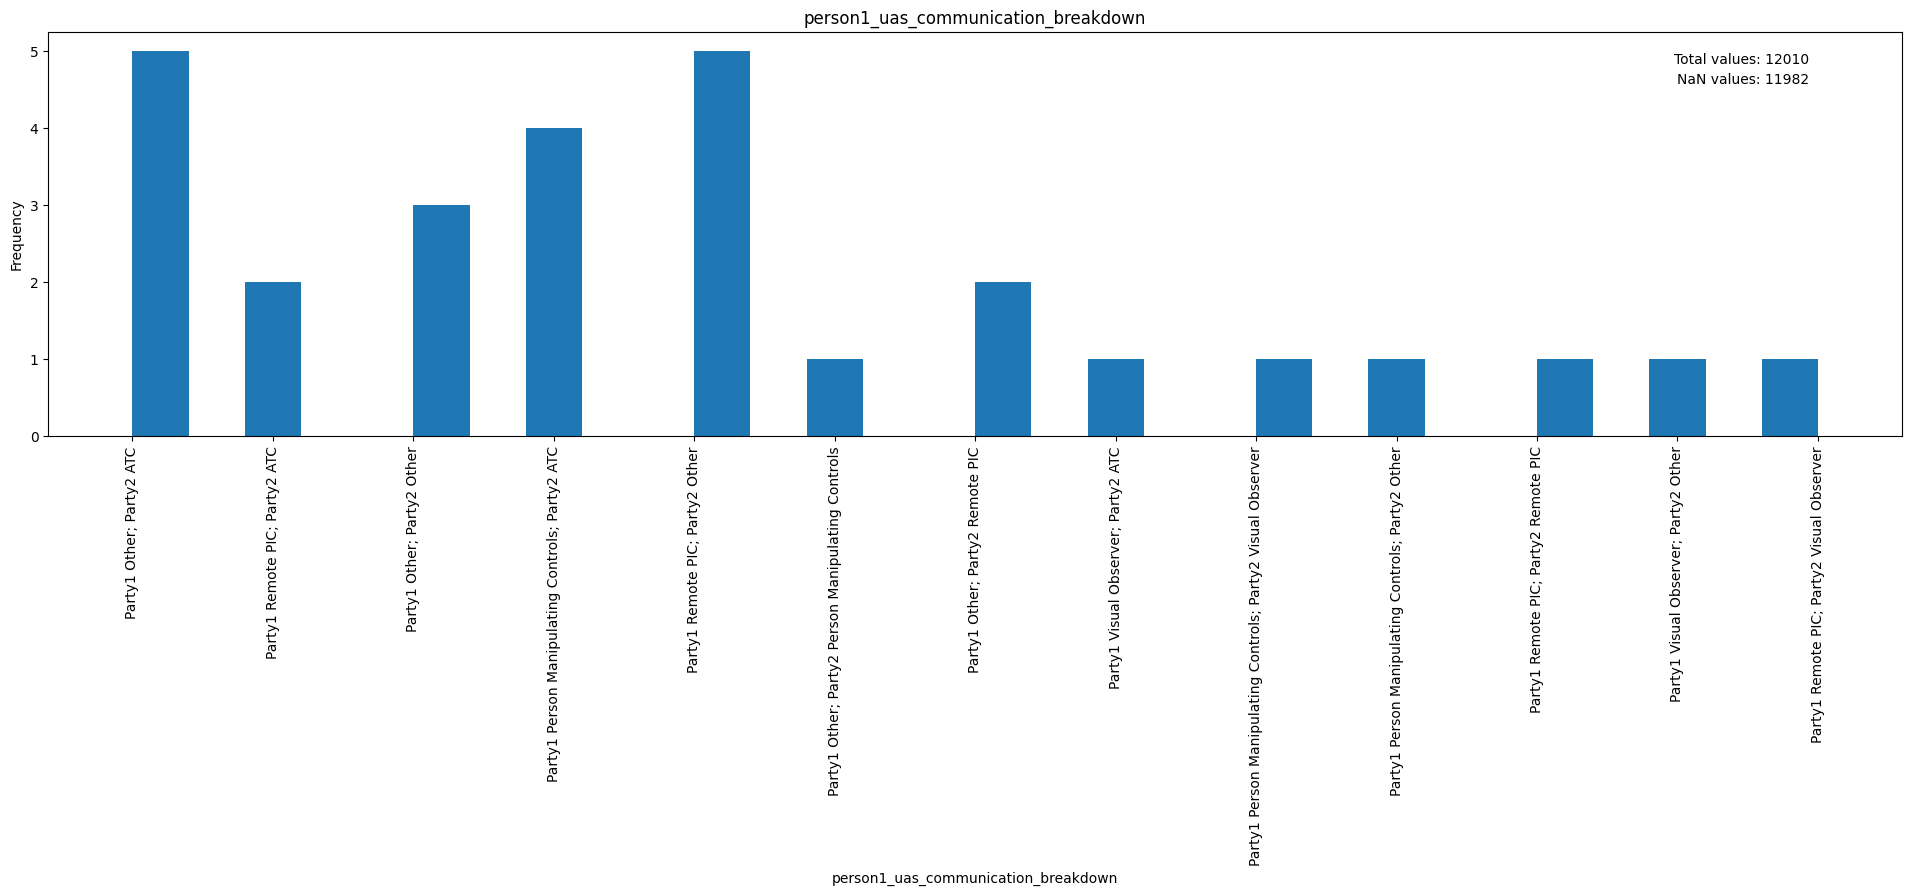

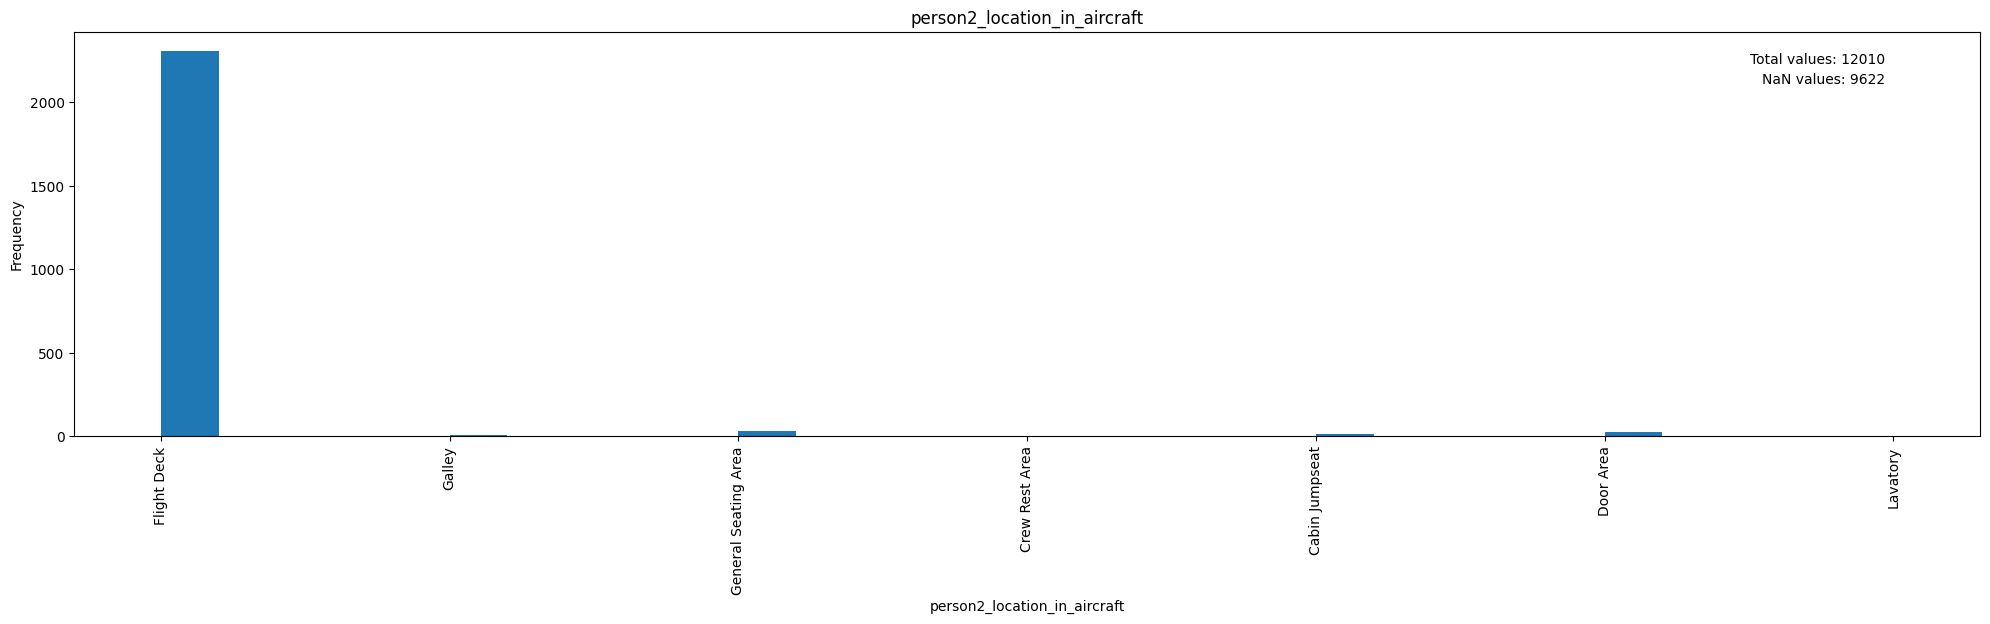

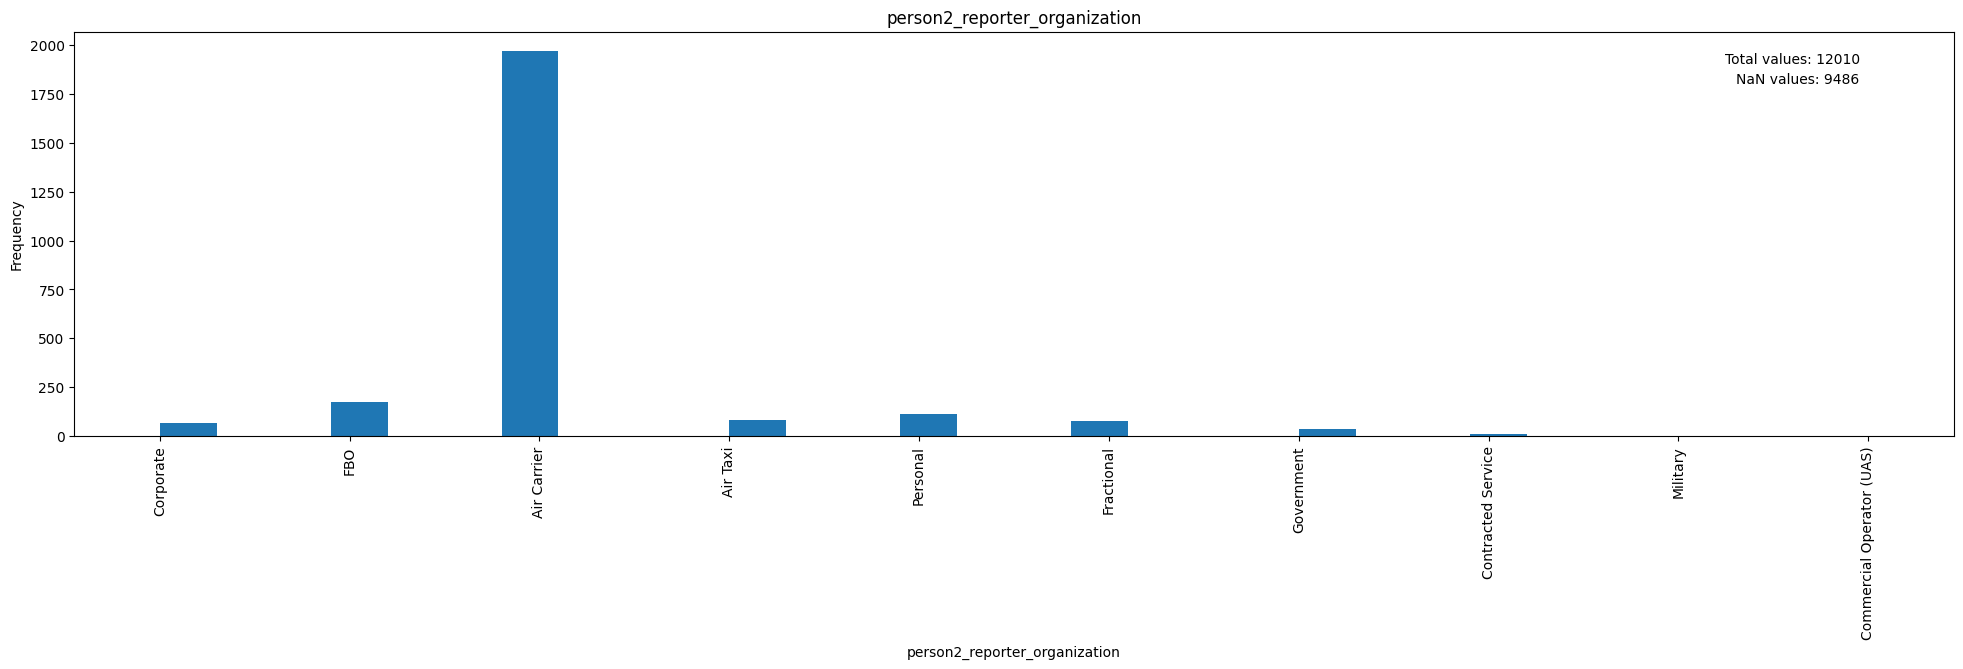

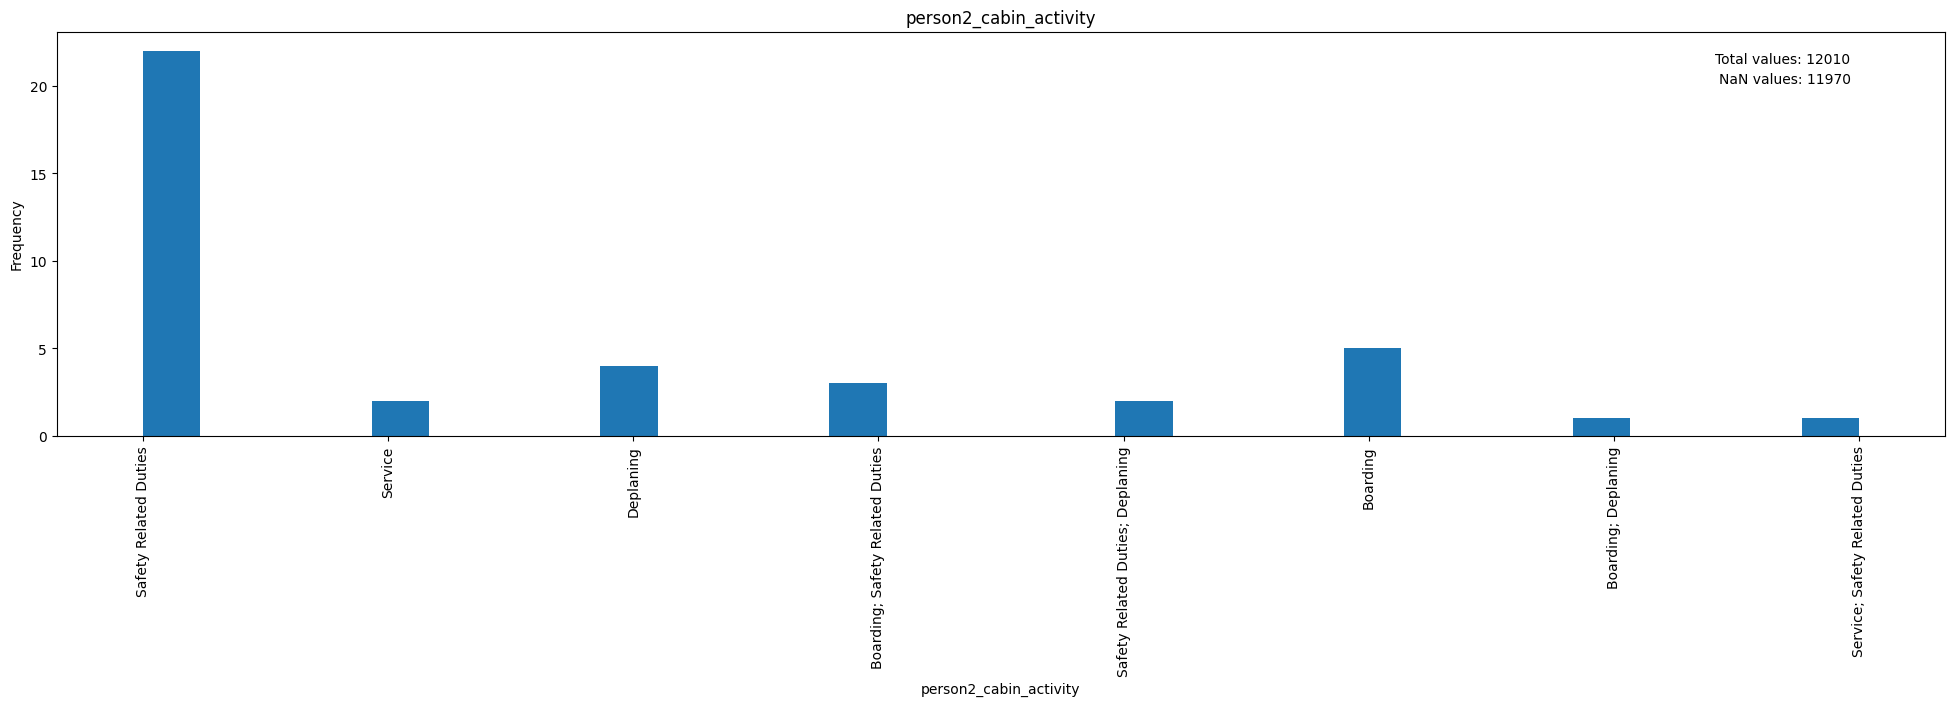

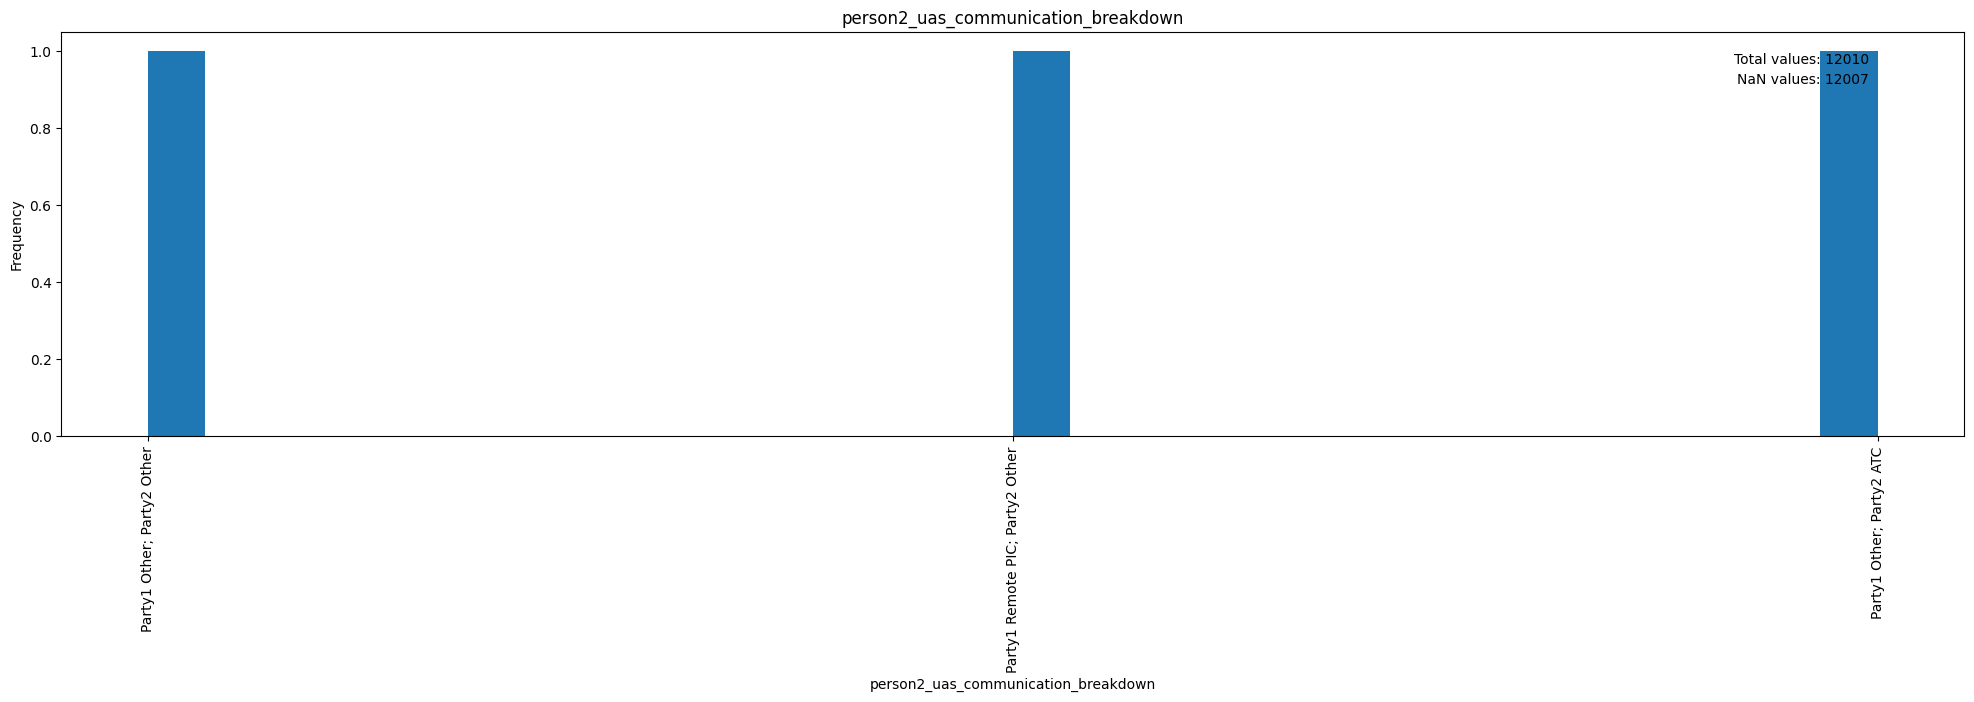

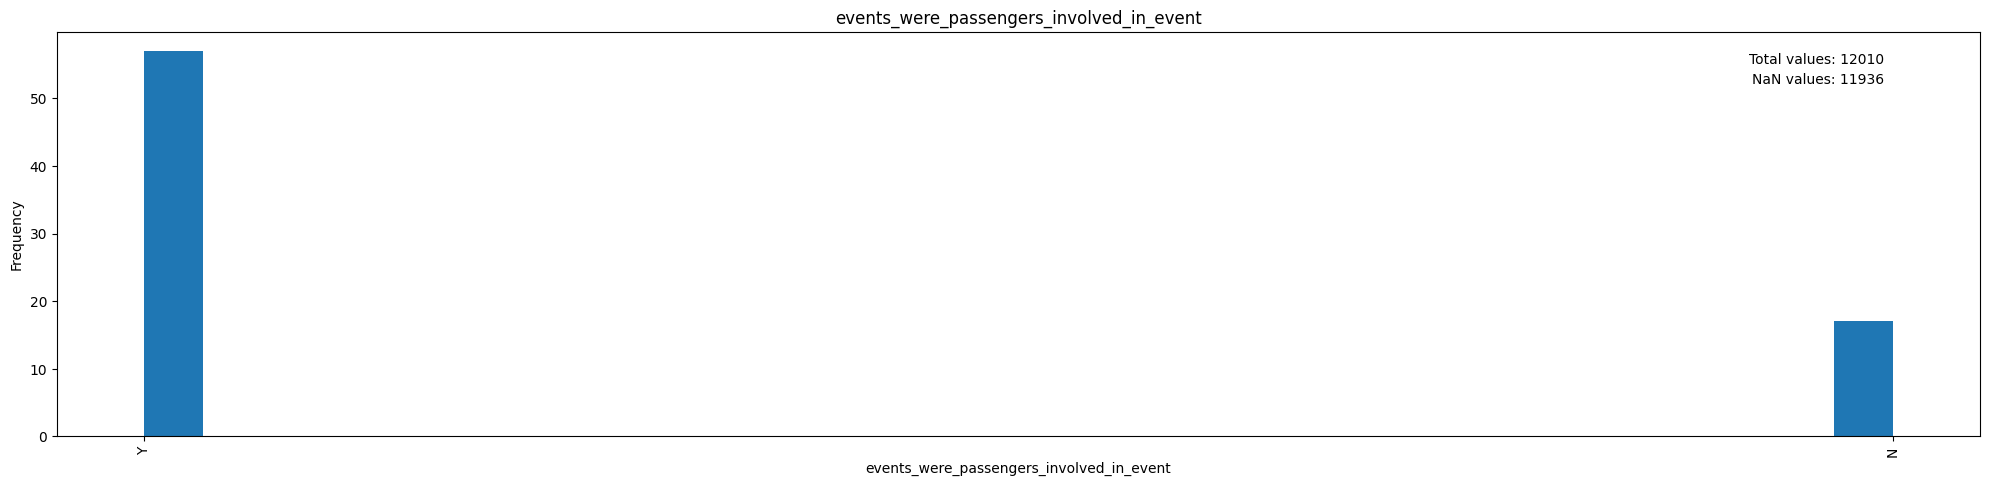

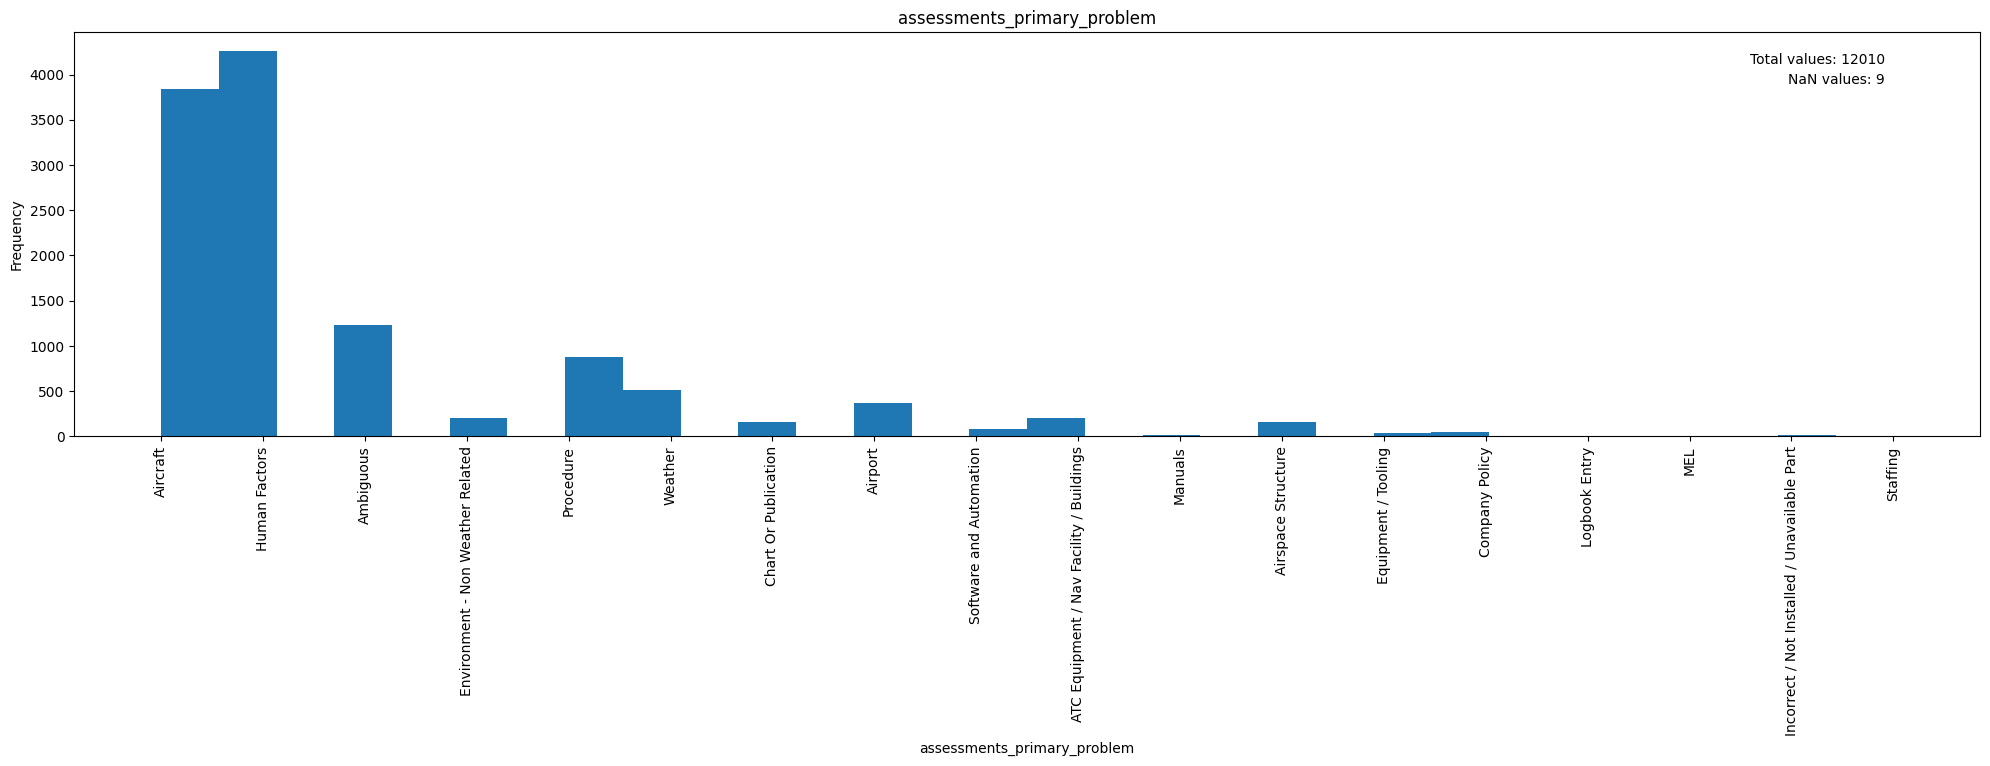

/var/folders/1b/zmjs29qd2vzdg1nl2chvp4mh0000gn/T/ipykernel_19609/4164503384.py:30: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


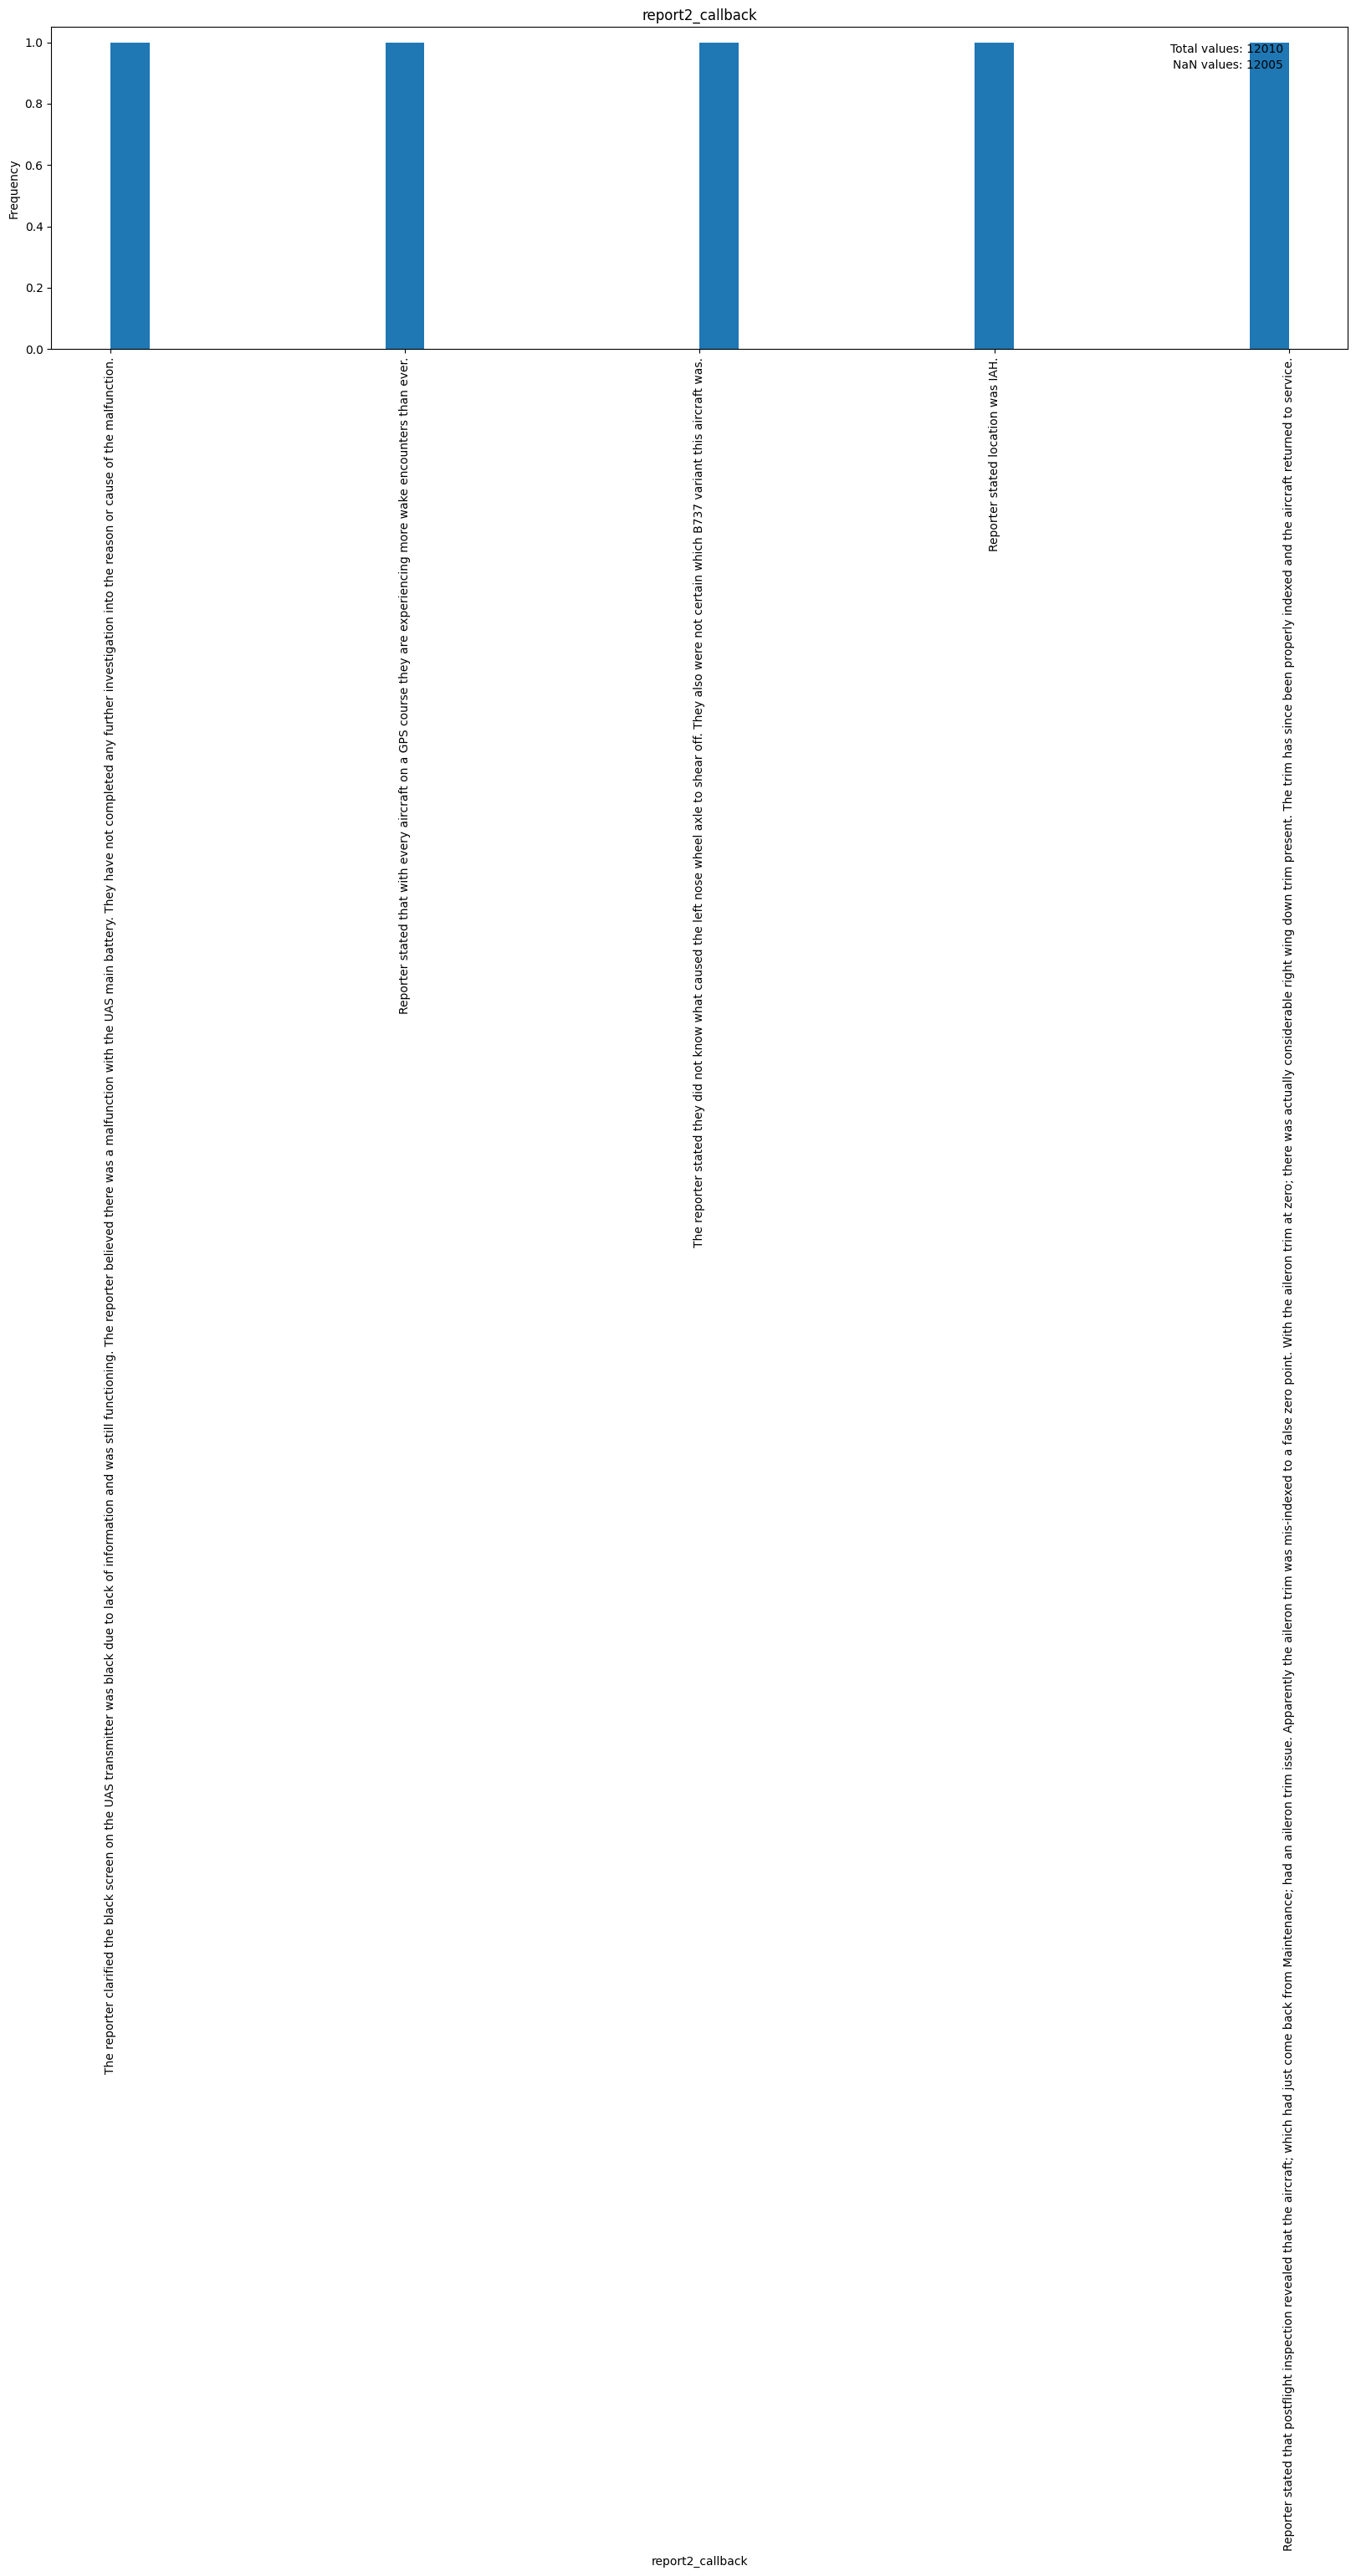

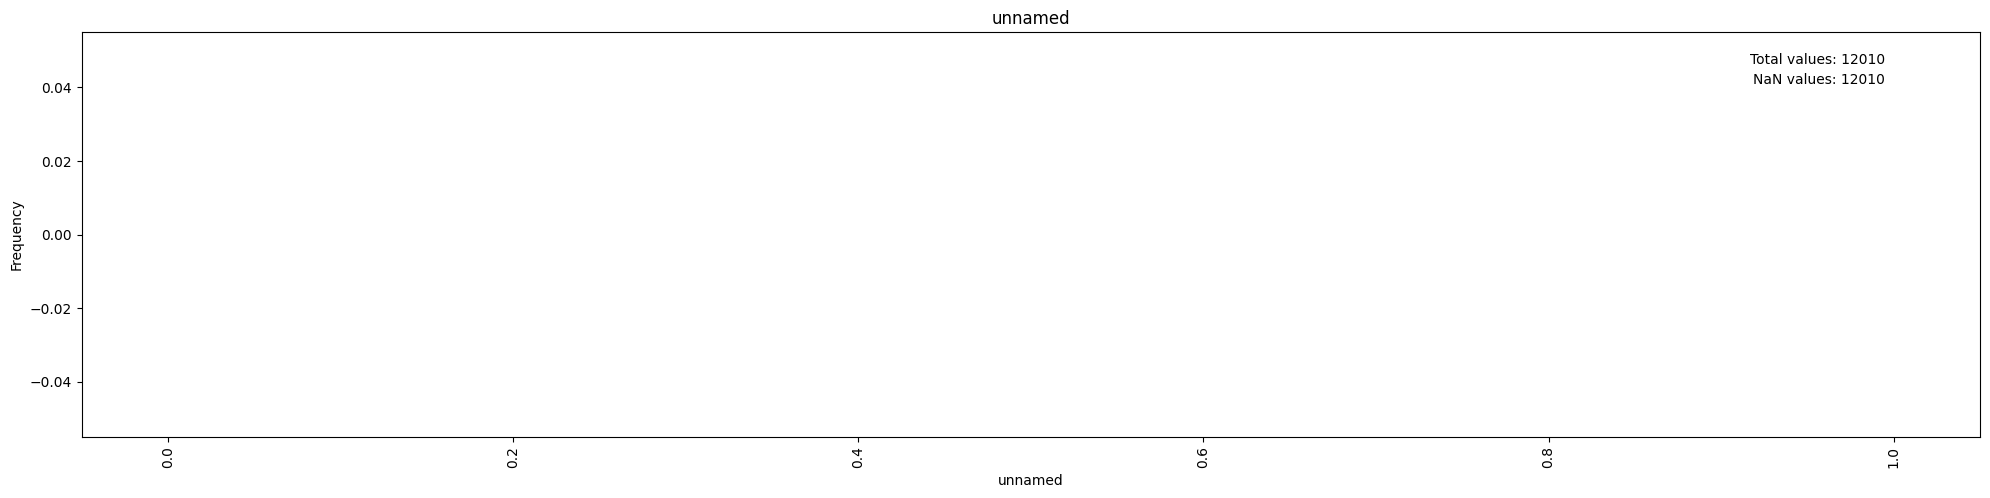

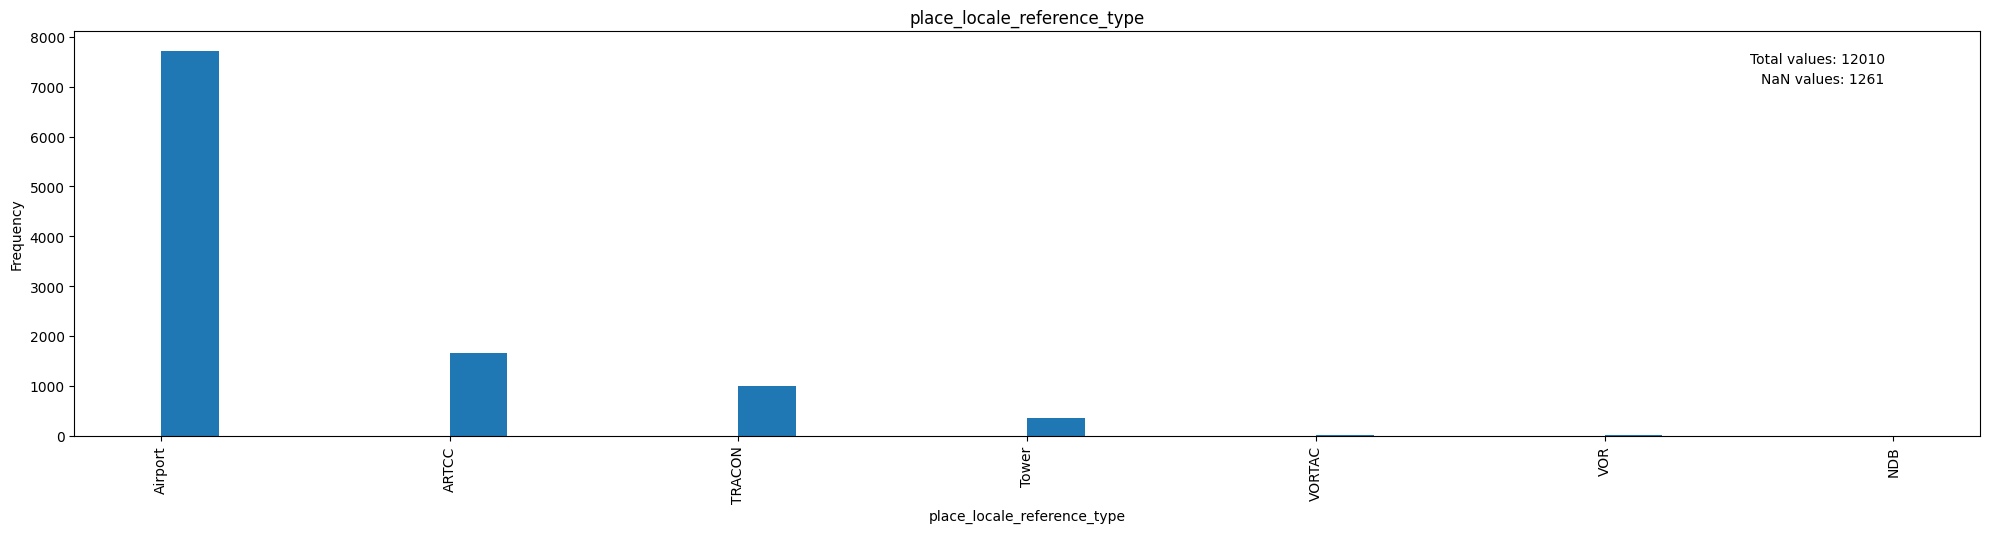

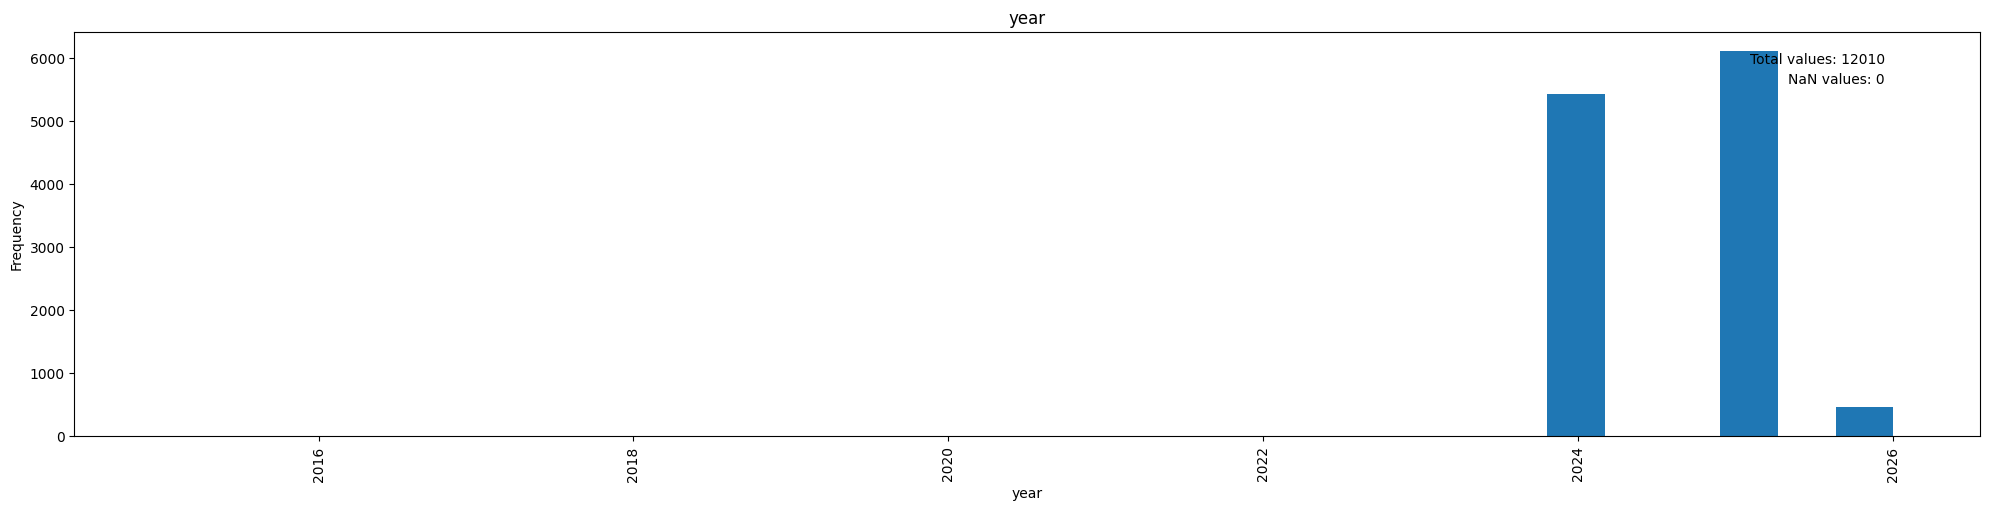

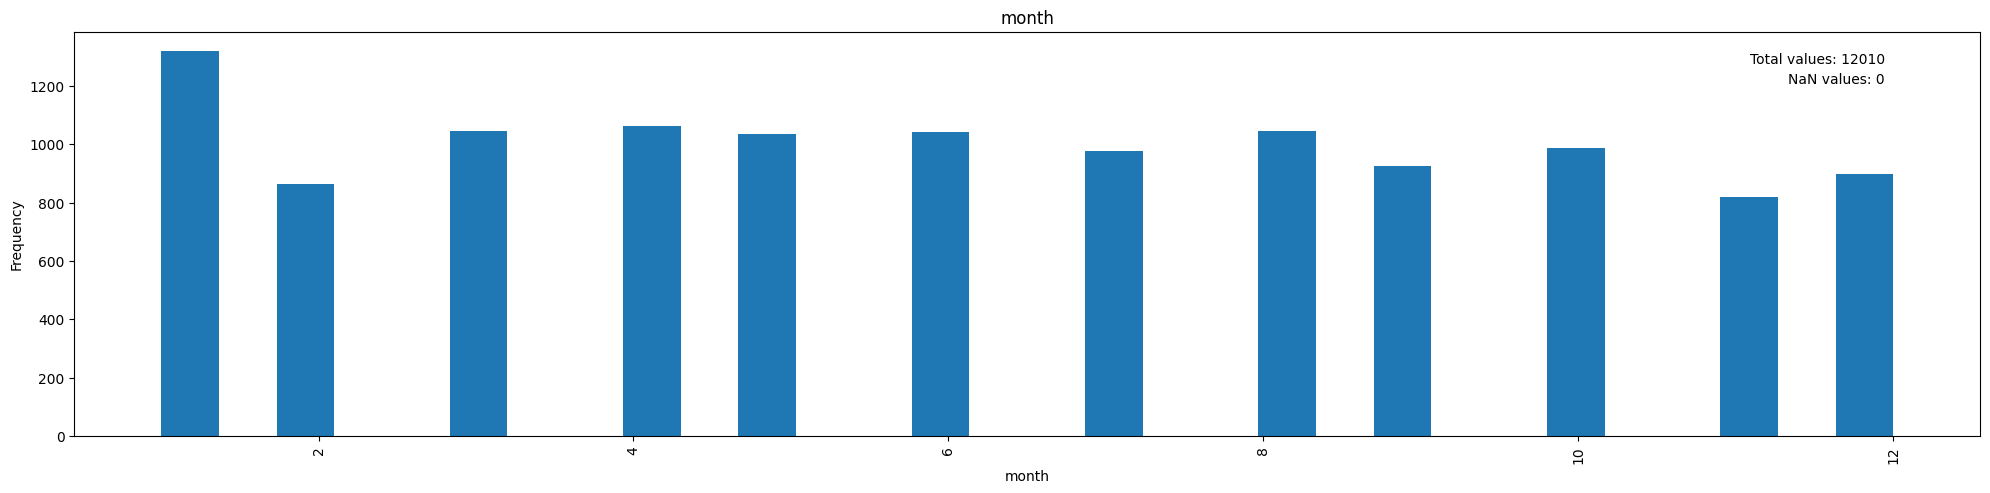

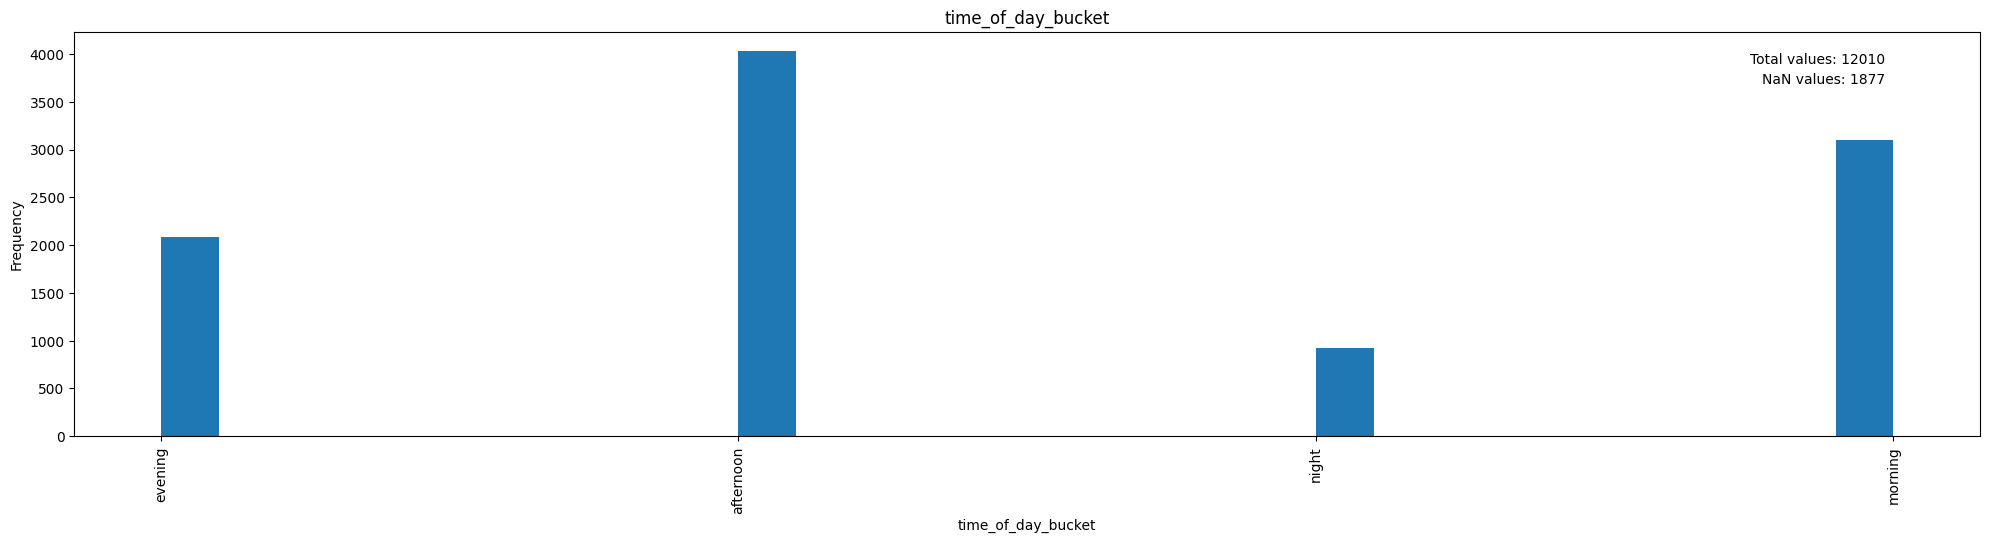

In [21]:
def plot_columns(df, columns_to_plot):

    for column in columns_to_plot:
        plt.figure(figsize=(20, 5))
        plt.hist(
            df[column].dropna(), 
            histtype="stepfilled",
            # alpha=0.35,
            bins=30, 
            # edgecolor='blue'
            )
        plt.title(column)
        plt.xlabel(column)
        plt.ylabel("Frequency")
        # Add number of NaN values to the plot
        num_nan = df[column][1:].isna().sum()

        text_options = {
            'horizontalalignment': 'right',
            'verticalalignment': 'top',
            'transform': plt.gca().transAxes,
            'fontsize': 10,
        }
        plt.text(0.95, 0.95, f'Total values: {len(df[column][1:])}', 
                 **text_options
                 )
        plt.text(0.95, 0.90, f'NaN values: {num_nan}', 
                 **text_options
                 )   
        plt.tight_layout()
        plt.xticks(rotation=90)
        plt.show()

plot_columns(df_renamed, columns_to_plot)

In [23]:
#Removing useless columns (all nans)
columns_to_drop = [
    "unnamed", 
    # "place_locale_reference", 
    # "time_date"
]
df_cleaned = df_renamed.drop(columns=columns_to_drop)
df_cleaned[[x for x in df_cleaned.columns if 'events' in x]]['events_were_passengers_involved_in_event']

1        NaN
2        NaN
3        NaN
4        NaN
5        NaN
        ... 
16576    NaN
16577    NaN
16578    NaN
16579    NaN
16580    NaN
Name: events_were_passengers_involved_in_event, Length: 12011, dtype: object

In [24]:
from datetime import datetime as dt
time = dt.now()

df_cleaned.to_csv(f"../data/cleaned/{time.strftime('%y%m%d_%H%M')}.csv", index=False)